# The delta tilt method

A three-panel illustration of the delta method with a **reference-day depth limit**, following the supplied schematic. Run all cells on Katana to choose **random real eddy-days** from the confirmed vertical profiles. Set `N_IMAGES` to the number of figures you want. Change `SEED` for another batch, or set `EDDY_ID` and optionally `REFERENCE_DAY` to choose one yourself. The selected IDs and days are printed below. Sampling visits randomly ordered eddies once per round before drawing additional days from them; eddy-day pairs never repeat. Setting both `EDDY_ID` and `REFERENCE_DAY` produces just that one example. Selection requires five consecutive usable profiles and a finite, nonzero depth-limited tilt; it is for illustration, not an unbiased population sample.

**a)** Five daily centre profiles. **b)** Reconstruct a representative profile from mean depth increments, then fit a variance-weighted 3-D line. **c)** Compare that fitted tilt with the reference day's horizontal extent.

The fit uses both horizontal coordinates. For display, all panels project onto its horizontal axis, positive from shallow to deep; this preserves the fitted horizontal tilt distance. The arrow points **deep to shallow**, as does `TiltDir`.

In [7]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

HERE = Path.cwd().resolve()
REPO = next(p for p in (HERE, *HERE.parents) if (p / 'seacofs_eddy_dataset_modular').is_dir())
OUT = REPO / 'seacofs_eddy_tilt_analysis' / 'delta_tilt_method'
sys.path.insert(0, str(OUT))
from delta_sensitivity_tools import increments, fit_snapshot, scan_projected_extent_differences

SEED = 38                # Change this to try another random batch
N_IMAGES = 40             # Number of random eddy-day schematics
EDDY_ID = None             # None = random eddy; otherwise enter an Eddy ID
REFERENCE_DAY = None       # None = random eligible day within that eddy
PROFILE_PATH = Path('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset_modular/vertical_profiles_confirmed/profiles.parquet')
NUM = 5                   # Centred five-day window: k-2 ... k+2
TEMPORAL_SIGMA_DAYS = 1.0
DEPTH_INT = 10
MAX_DEPTH = 1000
MIN_DEPTH_RANGE = 200
MIN_POINTS = 5
BEARING_OFFSET = 20.0
EPS = 1e-10
SAVE = False

# Optional expensive full-dataset search, executed only in the bottom section.
RUN_DIFFERENCE_SEARCH = True
TOP_N_DIFFERENCES = 60     # Number of largest-mismatch schematics to display

In [8]:
# Load once, then choose unique actual eddy-day windows.
from collections import deque
from IPython.display import display

if not isinstance(N_IMAGES, int) or isinstance(N_IMAGES, bool) or N_IMAGES < 1:
    raise ValueError('N_IMAGES must be a positive integer.')
if REFERENCE_DAY is not None and EDDY_ID is None:
    raise ValueError('Set EDDY_ID as well when choosing REFERENCE_DAY.')
all_profiles = pd.read_parquet(PROFILE_PATH, columns=['Eddy', 'Day', 'Depth', 'xc', 'yc'])
profiles = all_profiles  # Preserve the full dataset for the optional search.
if EDDY_ID is not None:
    profiles = profiles.loc[profiles.Eddy.eq(EDDY_ID)].copy()
if profiles.empty:
    raise ValueError('No profiles found for the requested selection.')

rng = np.random.default_rng(SEED)
target = np.arange(0, MAX_DEPTH + DEPTH_INT, DEPTH_INT)
view = profiles.assign(Depth=profiles.Depth.abs())
view = view.loc[view.Depth.le(MAX_DEPTH)].copy()
view['finite'] = np.isfinite(view[['Depth', 'xc', 'yc']].to_numpy()).all(axis=1)
coverage = view.groupby(['Eddy', 'Day']).agg(
    shallow=('Depth', 'min'), deep=('Depth', 'max'),
    levels=('Depth', 'size'), unique_levels=('Depth', 'nunique'), finite=('finite', 'all'))
coverage['first'] = np.ceil(coverage.shallow / DEPTH_INT) * DEPTH_INT
coverage['last'] = np.floor(coverage.deep / DEPTH_INT) * DEPTH_INT - DEPTH_INT
coverage = coverage.loc[coverage.finite & coverage.levels.eq(coverage.unique_levels)
    & coverage.levels.ge(2) & (coverage['last'] - coverage['first']).ge(MIN_DEPTH_RANGE)
    & ((coverage['last'] - coverage['first']) / DEPTH_INT + 1).ge(MIN_POINTS)]
candidates = {}
for eddy, g in coverage.groupby(level='Eddy'):
    usable = set(g.index.get_level_values('Day').astype(int))
    days = set(usable)
    for offset in range(-(NUM // 2), NUM // 2 + 1):
        days &= {day - offset for day in usable}
    if REFERENCE_DAY is not None:
        days &= {int(REFERENCE_DAY)}
    if days:
        candidates[int(eddy)] = iter(rng.permutation(sorted(days)))

# Spread the batch across eddies, then revisit them if more images are requested.
queue = deque(rng.permutation(sorted(candidates)))
requested = 1 if REFERENCE_DAY is not None else N_IMAGES
selected = []
while queue and len(selected) < requested:
    eddy = int(queue.popleft())
    for day in candidates[eddy]:
        day = int(day)
        trial = profiles.loc[profiles.Eddy.eq(eddy) & profiles.Day.between(day - NUM // 2, day + NUM // 2)]
        dx, dy = increments(trial, DEPTH_INT, MAX_DEPTH)
        result = fit_snapshot(dx, dy, day, sigma=TEMPORAL_SIGMA_DAYS,
            half_window=NUM // 2, min_depth_range=MIN_DEPTH_RANGE,
            min_points=MIN_POINTS, bearing_offset=BEARING_OFFSET, eps=EPS)
        if result is not None and np.isfinite([result['TiltDis'], result['TiltDir']]).all() and result['TiltDis'] > EPS:
            selected.append((eddy, day))
            queue.append(eddy)
            break
if not selected:
    raise ValueError('No eligible examples found. Choose another Eddy/Day or check depth coverage.')
if len(selected) < requested:
    print(f'Only {len(selected)} eligible unique examples are available; requested {requested}.')
samples = pd.DataFrame(selected, columns=['Eddy', 'Day'])
print(f'Selected {len(samples)} examples from {samples.Eddy.nunique()} eddies; seed {SEED}')
display(samples)

Selected 40 examples from 40 eddies; seed 38


,Eddy,Day
0,2751,9884
1,2062,7836
2,686,3596
3,1579,6334
4,2137,7985
5,1292,5511
6,1245,5358
7,1003,4591
8,2685,9648
9,1619,6520


## Reference-day-limited calculation

1. Interpolate each daily centreline to 10 m depths **within its observed range**.
2. Calculate adjacent-depth increments $\delta x_d(z)$ and $\delta y_d(z)$.
**Before averaging**, retain only depth intervals whose two endpoints are inside the reference day’s observed profile range (also capped by `MAX_DEPTH`). Neighbouring days cannot extend that range.

3. Average those increments across five calendar days with Gaussian sigma = 1 day, then cumulatively sum them to form $\widetilde{x}(z),\widetilde{y}(z)$. Weights renormalize over available days at each depth. This removes each day's horizontal translation.
4. Weight each depth by $w(z)=1/[\mathrm{Var}(\delta x)+\mathrm{Var}(\delta y)+10^{-10}]$, using sample variances across days. Fit the leading singular vector of the weighted, centred $(\widetilde{x},\widetilde{y},z)$ coordinates.
5. Intersect that line with the shallowest and deepest retained fit depths. Their horizontal separation is `TiltDis`; the deep-to-shallow bearing plus the configured 20° rotation is `TiltDir`.

Implementation details retained here: missing days stay missing; a single available increment cannot supply a sample variance. Cumulative increments are labelled by the **upper** depth of each interval, so an 850 m profile ends at a fit label of 840 m. The fit uses horizontal kilometres and depth metres exactly as the production code does. Display recentering does not alter the fit or distance.

This correction is implemented locally in `delta_sensitivity_tools.fit_snapshot`; the production pipeline is deliberately unchanged. A missing reference profile or insufficient retained depth support gives no estimate. With the retained upper-interval labels, a 0–200 m profile spans labels 0–190 m and fails `MIN_DEPTH_RANGE=200`.


In [9]:
def plot_schematic(EDDY, DAY, profiles):
    window_days = np.arange(DAY - NUM // 2, DAY + NUM // 2 + 1)
    window = profiles.assign(Depth=profiles.Depth.abs())
    window = window.loc[window.Depth.le(MAX_DEPTH)].sort_values(['Day', 'Depth'])
    print(f'Observed eddy {EDDY}, reference Day {DAY}')
    dx, dy = increments(profiles, DEPTH_INT, MAX_DEPTH)
    fit = fit_snapshot(dx, dy, DAY, sigma=TEMPORAL_SIGMA_DAYS,
        half_window=NUM // 2, min_depth_range=MIN_DEPTH_RANGE,
        min_points=MIN_POINTS, bearing_offset=BEARING_OFFSET, eps=EPS)
    if fit is None or fit['TiltDis'] < EPS:
        raise ValueError('Reference day has insufficient depth support or zero tilt.')
    trace = fit['trace']
    points = trace[['x', 'y', 'Depth']].to_numpy()
    weights = trace.weight.to_numpy() / trace.weight.max()
    top, bottom = fit['ends']
    tilt_distance, tilt_direction = fit['TiltDis'], fit['TiltDir']
    axis = (bottom[:2] - top[:2]) / tilt_distance
    reference = window.loc[window.Day.eq(DAY)]
    reference_top, reference_bottom = reference.Depth.min(), reference.Depth.max()
    assert trace.Depth.min() >= reference_top
    assert trace.Depth.max() + DEPTH_INT <= reference_bottom + 1e-8
    print(f'Reference depth: {reference_top:.1f}–{reference_bottom:.1f} m; '
          f'fit labels: {top[2]:.1f}–{bottom[2]:.1f} m; TiltDis = {tilt_distance:.2f} km')

    plt.rcParams.update({'font.size': 11, 'axes.spines.top': True, 'axes.spines.right': True})
    fig, axs = plt.subplots(1, 3, figsize=(15, 4.8), sharey=True)
    # fig.suptitle(f'Eddy {EDDY} · reference Day {DAY}', y=1.08, fontsize=12)
    fig.subplots_adjust(left=0.055, right=0.985, bottom=0.23, top=0.82, wspace=0.13)
    colors = ['#5399cf', '#ff993e', '#54ad55', '#df2429', '#a989d4', '#a77b6b', '#ef7bc9']
    ref = window.loc[window.Day.eq(DAY)].sort_values('Depth')
    ref_xy = ref[['xc', 'yc']].to_numpy()
    # for ax in axs:
    #     ax.axhline(reference_bottom, color='grey', ls=':', lw=1, alpha=0.7)
    for j, day in enumerate(window_days):
        color = colors[(3 + int(day - DAY)) % len(colors)]
        g = window.loc[window.Day.eq(day)]
        if g.empty:
            continue
        offset = int(day - DAY)
        label = 'Day k' if offset == 0 else f'Day k{offset:+d}'
        xy0 = g[['xc', 'yc']].iloc[0].to_numpy()
        # axs[0].plot(g[['xc', 'yc']].to_numpy() @ axis - xy0, g.Depth, color=color,
        #             lw=2.8 if offset == 0 else 1.1, label=label)
        axs[0].plot(
            (g[['xc', 'yc']].to_numpy() - xy0) @ axis,
            g.Depth,
            color=color,
            lw=2.8 if offset == 0 else 1.1,
            label=label
        )
    axs[0].legend(loc='upper center', bbox_to_anchor=(0.5, -0.16), ncol=5, fontsize=8, frameon=False)
    axs[0].set_xlabel('Projected centre position (km)')
    axs[0].set_ylabel('Depth (m)')

    origin = points[0, :2] @ axis
    s = points[:, :2] @ axis - origin
    fit_s = np.array([top[:2] @ axis, bottom[:2] @ axis]) - origin
    fit_z = np.array([top[2], bottom[2]])
    raw_s = (ref_xy - ref_xy[0]) @ axis
    for ax in axs[1:]:
        ax.plot(s, points[:, 2], color='blue', lw=2, label='Mean-increment profile')
        ax.plot(fit_s, fit_z, 'k--', lw=2, label='Weighted line fit')
        ax.set_xlabel('Relative displacement (km)')
    # Ribbon width encodes the normalized weights, not positional uncertainty.
    width = weights * max(tilt_distance * 0.30, 1)
    axs[1].fill_betweenx(points[:, 2], s - width, s + width, color='#6baed6', alpha=0.5,
                         linewidth=0, label='Width ∝ fit weight')
    axs[1].lines[0].set_zorder(4)
    span = max(tilt_distance, np.ptp(raw_s), 1)
    arrow_x = fit_s - 0.30 * span
    axs[1].annotate('', xy=(arrow_x[0], fit_z[0] + 110),
                    xytext=(arrow_x[1], fit_z[1] - 60),
                    arrowprops={'arrowstyle': '-|>', 'color': 'black', 'lw': 2, 'mutation_scale': 19})
    axs[1].text(arrow_x.mean() - 0.09 * span, fit_z.mean(), 'Tilt direction', ha='right')
    axs[2].plot(raw_s, ref.Depth, color='#df2429', lw=2.5, label='Reference day k')

    def bracket(ax, left, right, depth, label, color, ends):
        ax.plot([left, right], [depth, depth], color=color, lw=1.4, clip_on=False)
        for x, end in zip([left, right], ends):
            ax.plot([x, x], [depth - 15, end], color=color, lw=1.3, clip_on=False)
        ax.text((left + right) / 2, depth - 18, label, ha='center', va='bottom', color=color)

    bracket(axs[1], *fit_s, -70, f'Tilt distance: {tilt_distance:.1f} km', 'black', fit_z)
    bracket(axs[2], *fit_s, -70, f'', 'black', fit_z)
        
    imin, imax = np.argmin(raw_s), np.argmax(raw_s)
    bracket(axs[2], raw_s[imin], raw_s[imax], -155,
            f'Max projected extent: {np.ptp(raw_s):.1f} km', '#df2429',
            [ref.Depth.iloc[imin], ref.Depth.iloc[imax]])
    lo = min(s.min() - width.max(), raw_s.min(), arrow_x.min()) - 0.20 * span
    hi = max(s.max() + width.max(), raw_s.max()) + 0.13 * span
    for ax in axs[1:]:
        ax.set_xlim(lo, hi)
    for label, ax in zip(['a)', 'b)', 'c)'], axs):
        ax.set_ylim(MAX_DEPTH, -35)
        ax.text(-0.07, 1.02, label, transform=ax.transAxes, fontweight='bold', fontsize=13)
    axs[1].legend(loc='upper center', bbox_to_anchor=(0.5, -0.16), fontsize=8, frameon=False)
    # axs[2].legend(loc='upper center', bbox_to_anchor=(0.5, -0.16), fontsize=8, frameon=False)
    if SAVE:
        tag = f'eddy_{EDDY}_day_{DAY}'
        for ext in ['png', 'pdf']:
            fig.savefig(OUT / f'delta_tilt_schematic_{tag}.{ext}', dpi=220, bbox_inches='tight')
    plt.show()
    plt.close(fig)
    return {'Eddy': EDDY, 'Day': DAY, 'TiltDis': tilt_distance, 'TiltDir': tilt_direction,
            'ReferenceDepthMax': reference_bottom, 'FitDepthMax': bottom[2],
            'MaxProjectedExtent': float(np.ptp(raw_s)),
            'AbsoluteDifference': float(abs(np.ptp(raw_s) - tilt_distance))}

Observed eddy 2751, reference Day 9884
Reference depth: 0.0–858.9 m; fit labels: 0.0–840.0 m; TiltDis = 24.87 km


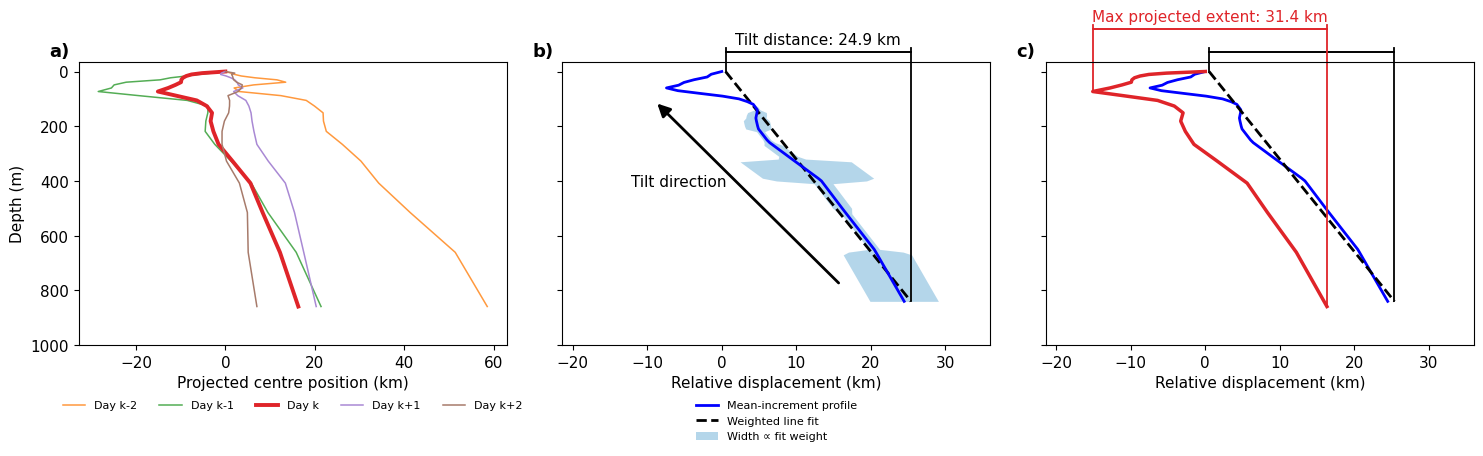

Observed eddy 2062, reference Day 7836
Reference depth: 0.0–407.9 m; fit labels: 0.0–390.0 m; TiltDis = 70.43 km


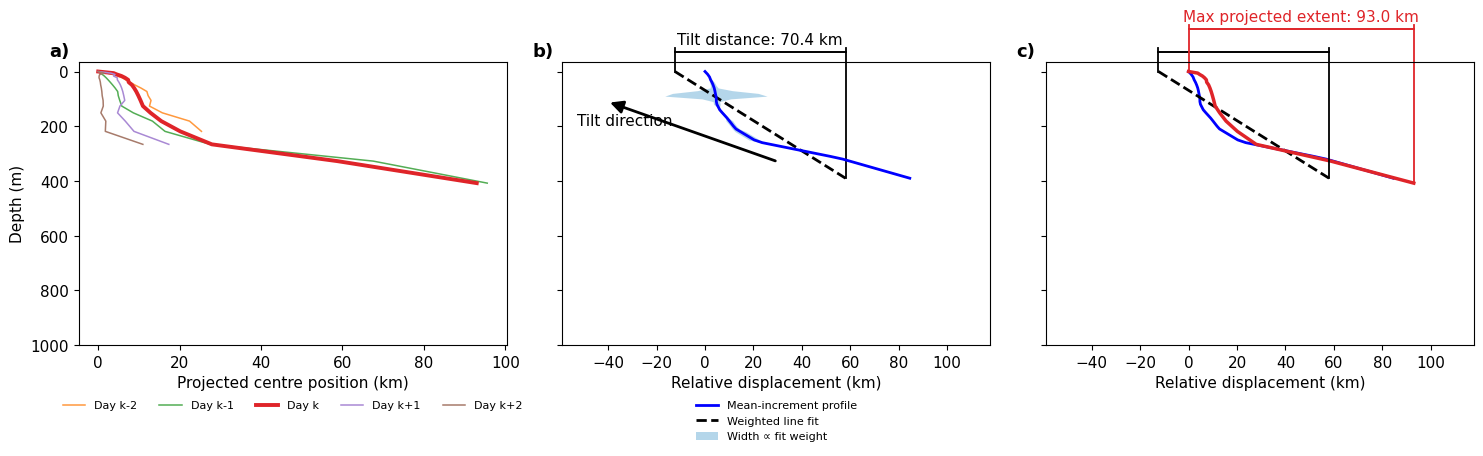

Observed eddy 686, reference Day 3596
Reference depth: 0.0–858.9 m; fit labels: 0.0–840.0 m; TiltDis = 27.77 km


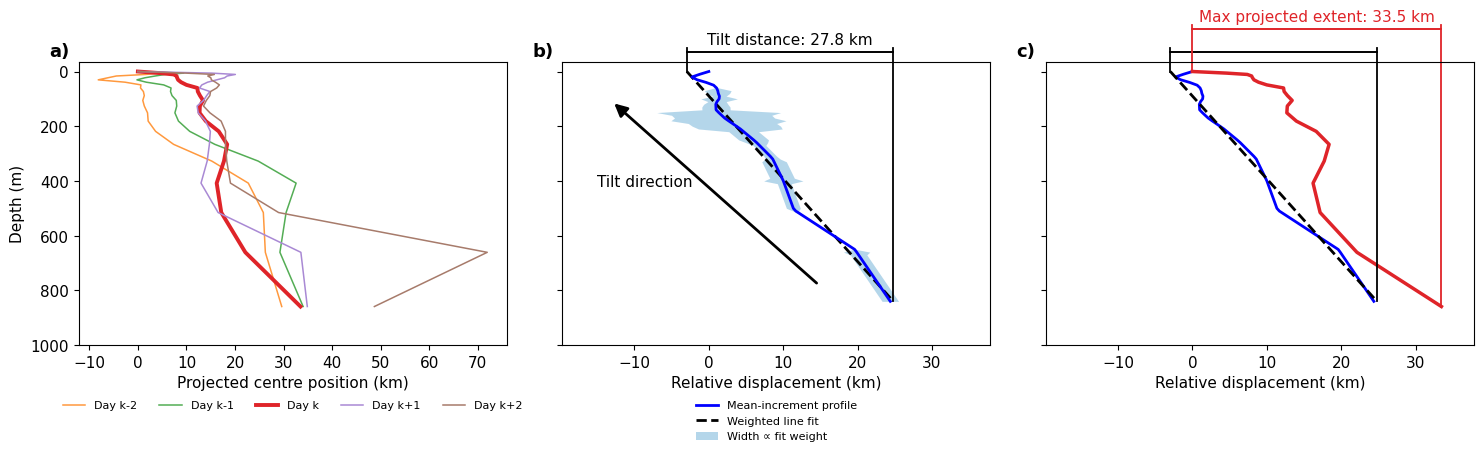

Observed eddy 1579, reference Day 6334
Reference depth: 0.0–858.9 m; fit labels: 0.0–840.0 m; TiltDis = 19.34 km


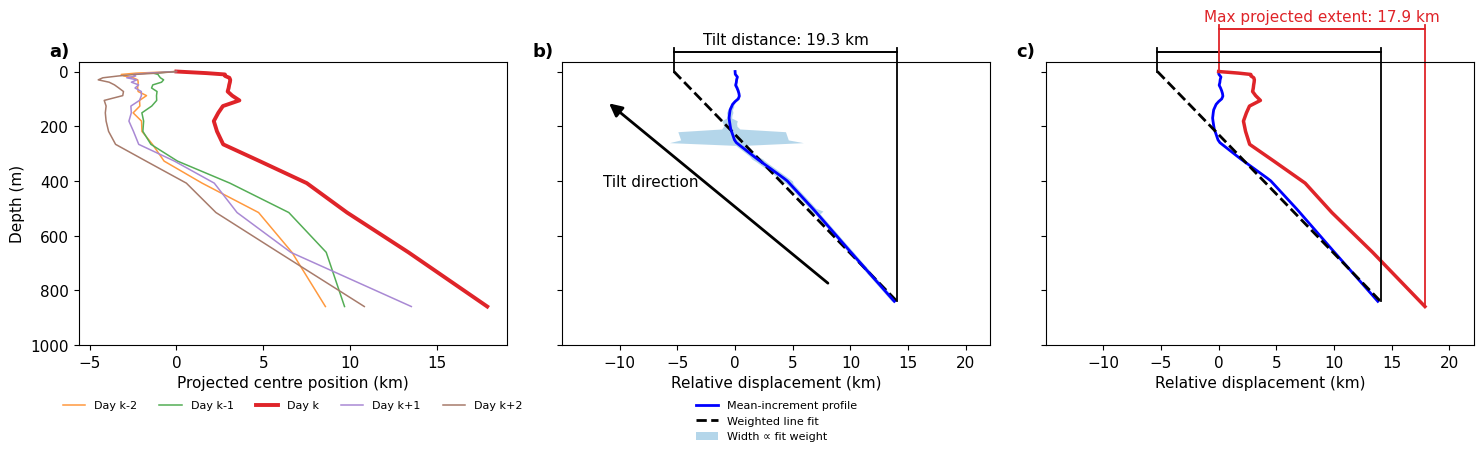

Observed eddy 2137, reference Day 7985
Reference depth: 0.0–858.9 m; fit labels: 0.0–840.0 m; TiltDis = 27.01 km


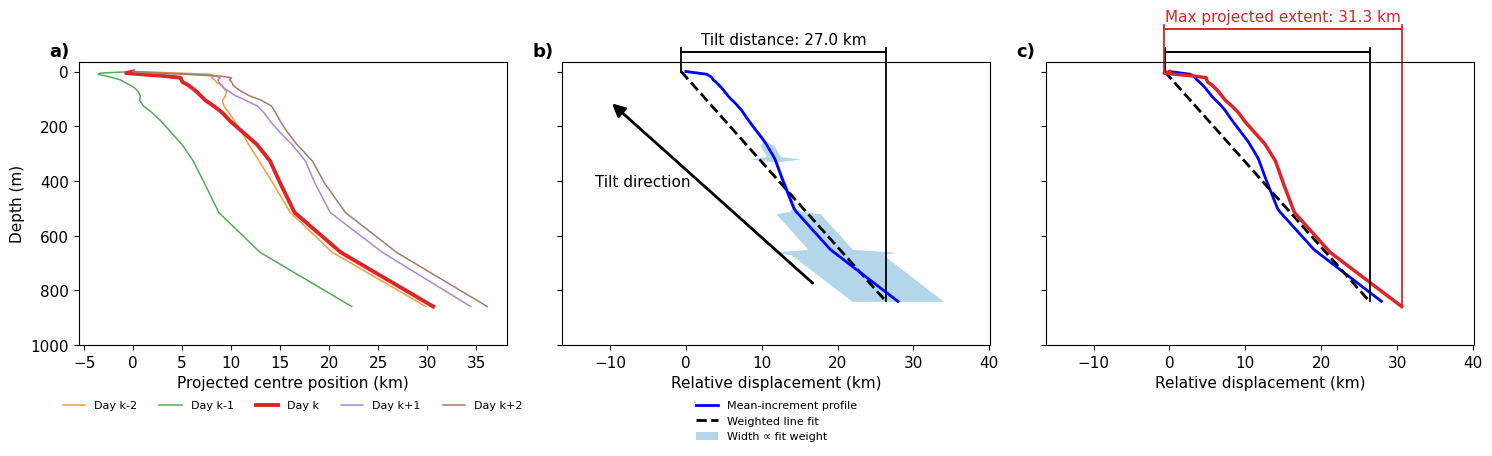

Observed eddy 1292, reference Day 5511
Reference depth: 0.0–858.9 m; fit labels: 0.0–840.0 m; TiltDis = 32.55 km


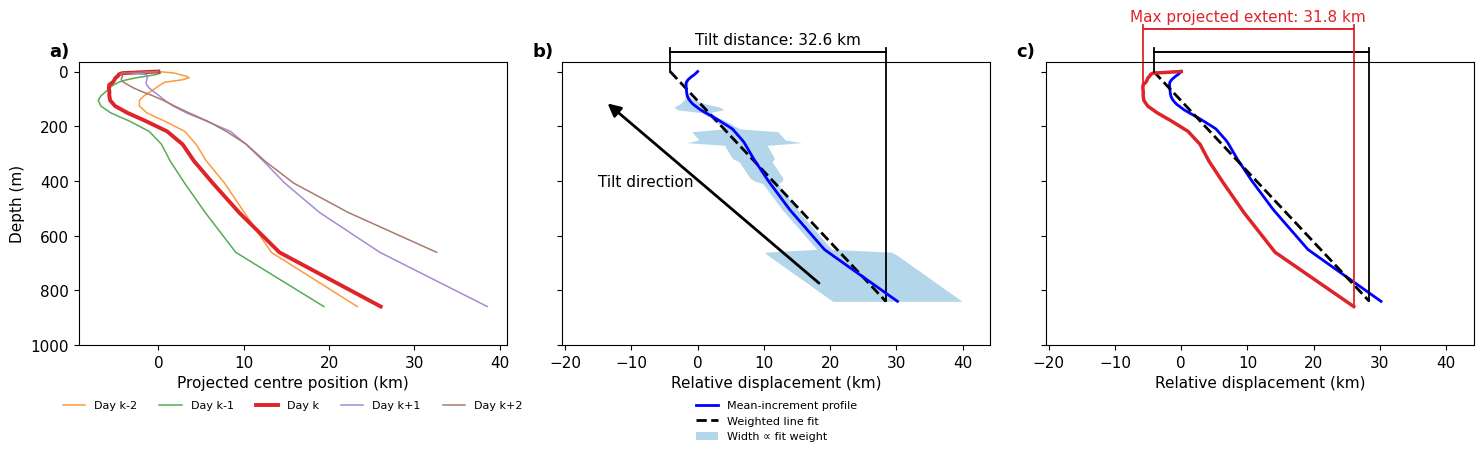

Observed eddy 1245, reference Day 5358
Reference depth: 0.0–858.9 m; fit labels: 0.0–840.0 m; TiltDis = 18.27 km


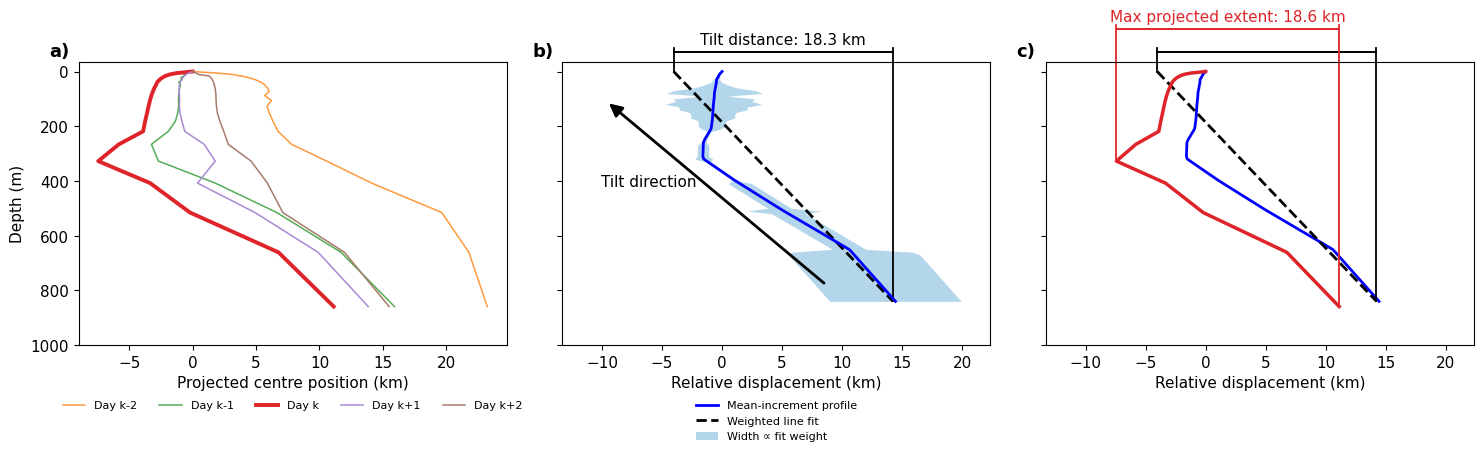

Observed eddy 1003, reference Day 4591
Reference depth: 0.0–660.8 m; fit labels: 0.0–500.0 m; TiltDis = 13.18 km


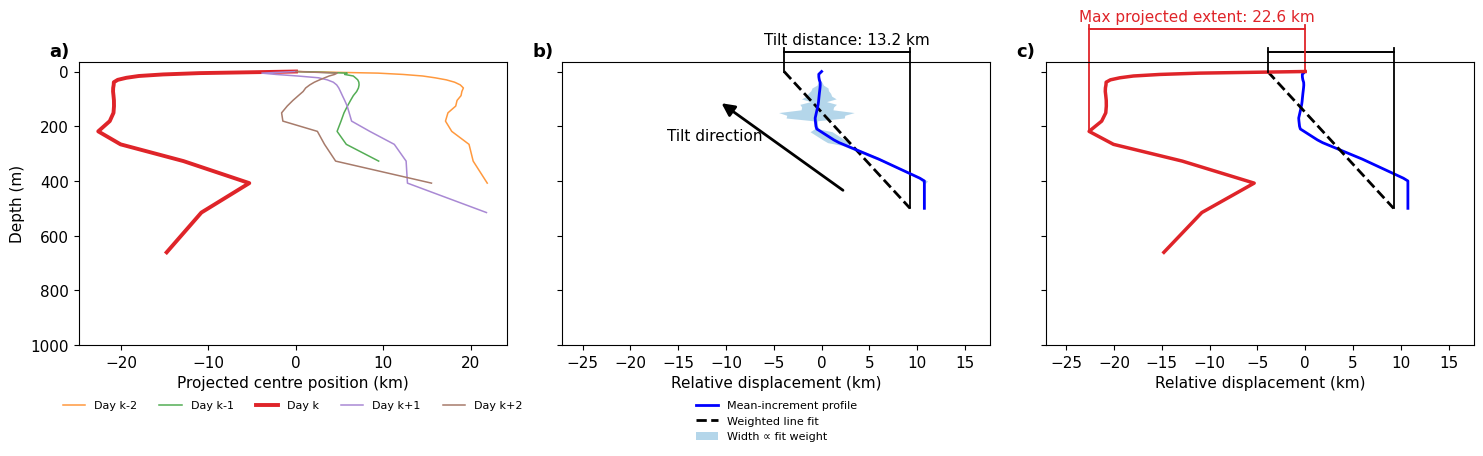

Observed eddy 2685, reference Day 9648
Reference depth: 0.0–858.9 m; fit labels: 0.0–840.0 m; TiltDis = 81.81 km


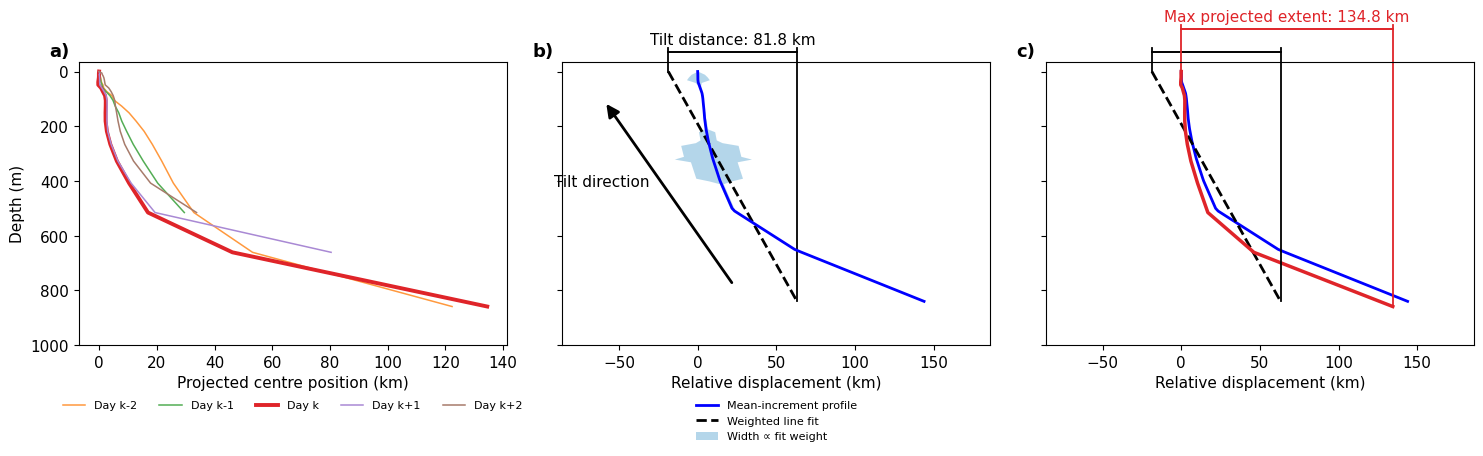

Observed eddy 1619, reference Day 6520
Reference depth: 0.0–858.9 m; fit labels: 0.0–840.0 m; TiltDis = 12.68 km


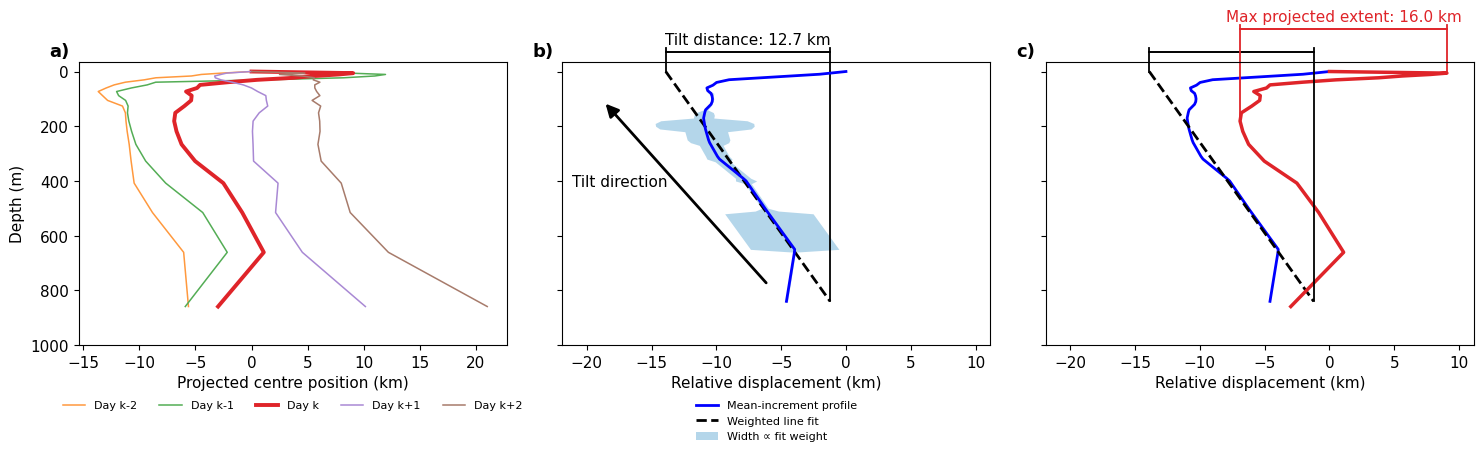

Observed eddy 2430, reference Day 8919
Reference depth: 0.0–218.8 m; fit labels: 0.0–200.0 m; TiltDis = 15.06 km


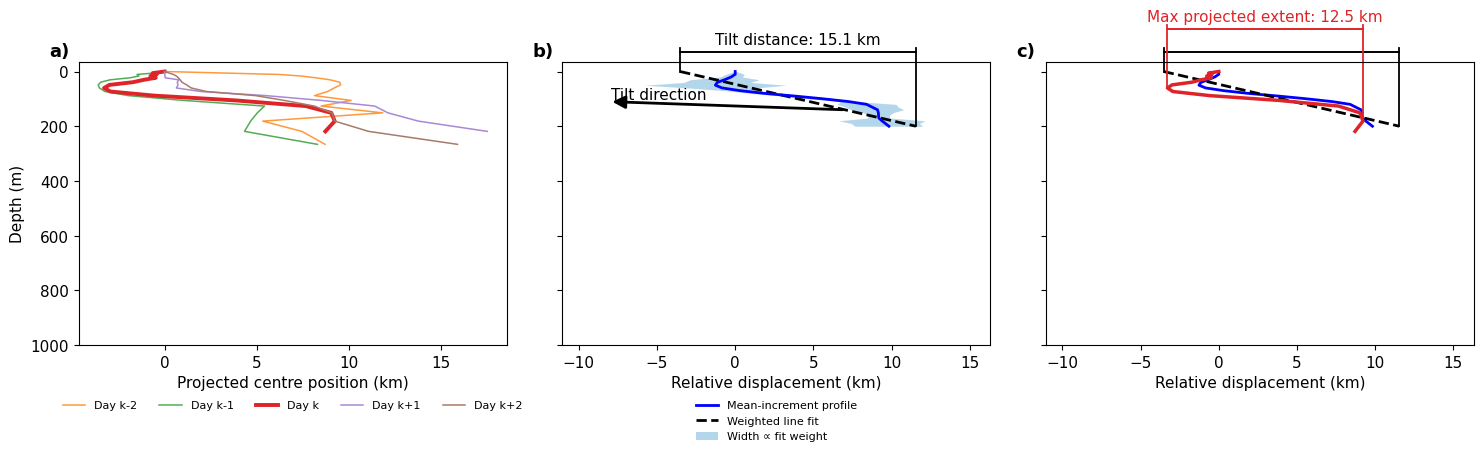

Observed eddy 2129, reference Day 7980
Reference depth: 0.0–858.9 m; fit labels: 0.0–840.0 m; TiltDis = 4.58 km


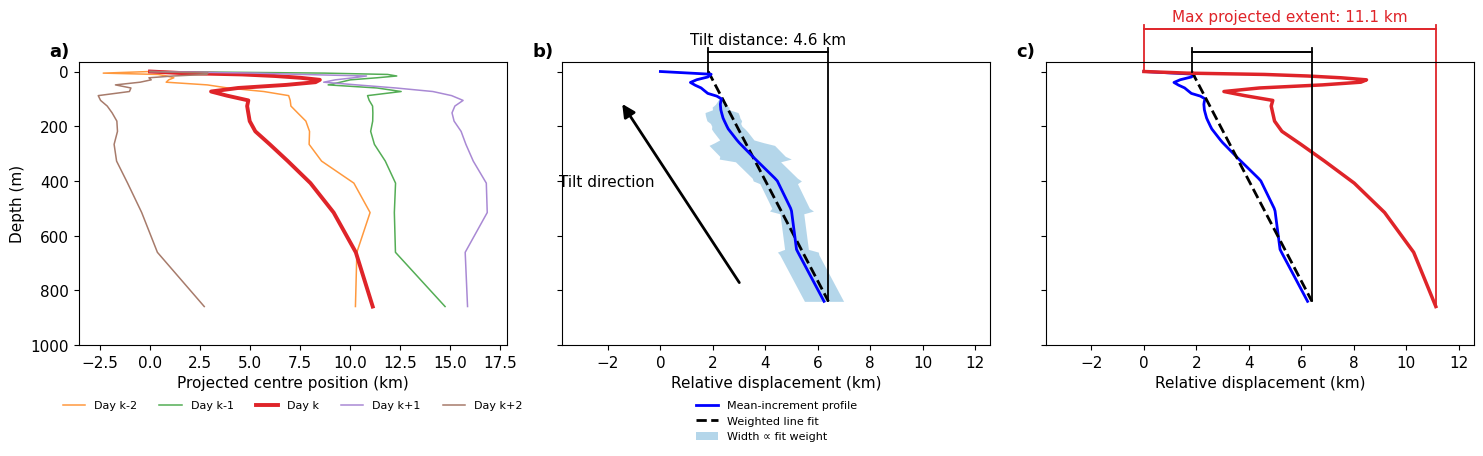

Observed eddy 1288, reference Day 5512
Reference depth: 0.0–858.9 m; fit labels: 0.0–840.0 m; TiltDis = 14.25 km


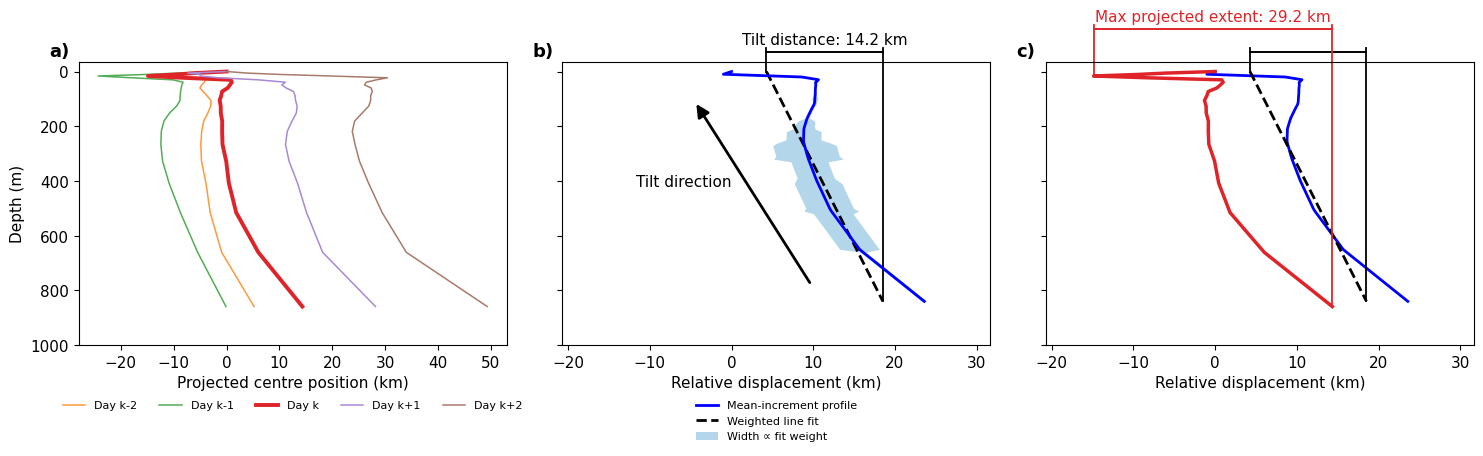

Observed eddy 2243, reference Day 8338
Reference depth: 0.0–858.9 m; fit labels: 0.0–840.0 m; TiltDis = 7.83 km


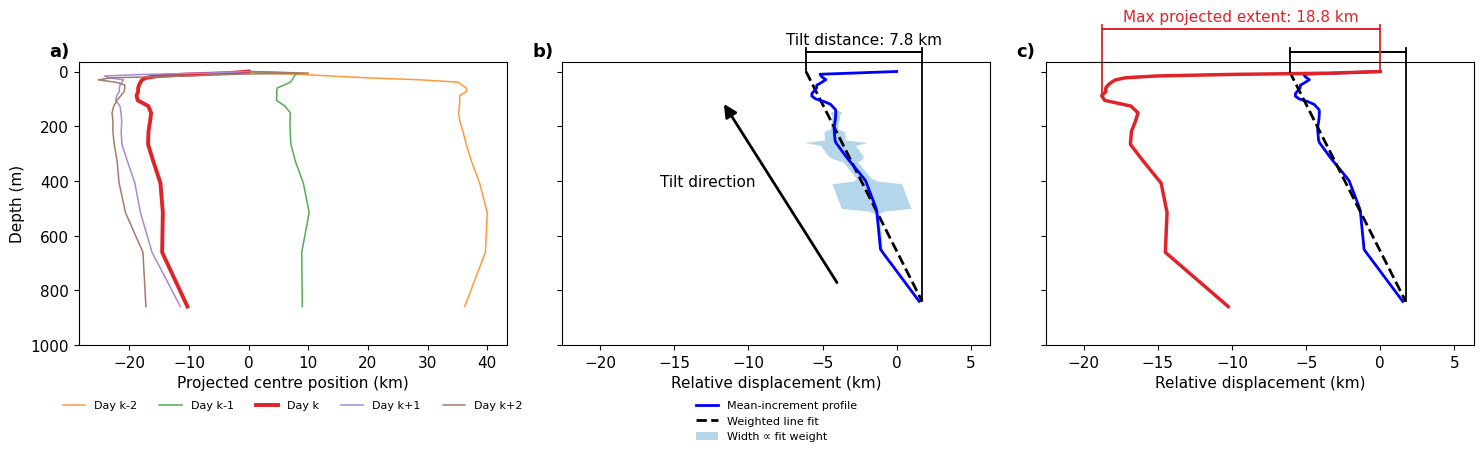

Observed eddy 350, reference Day 2537
Reference depth: 0.0–858.9 m; fit labels: 0.0–840.0 m; TiltDis = 4.16 km


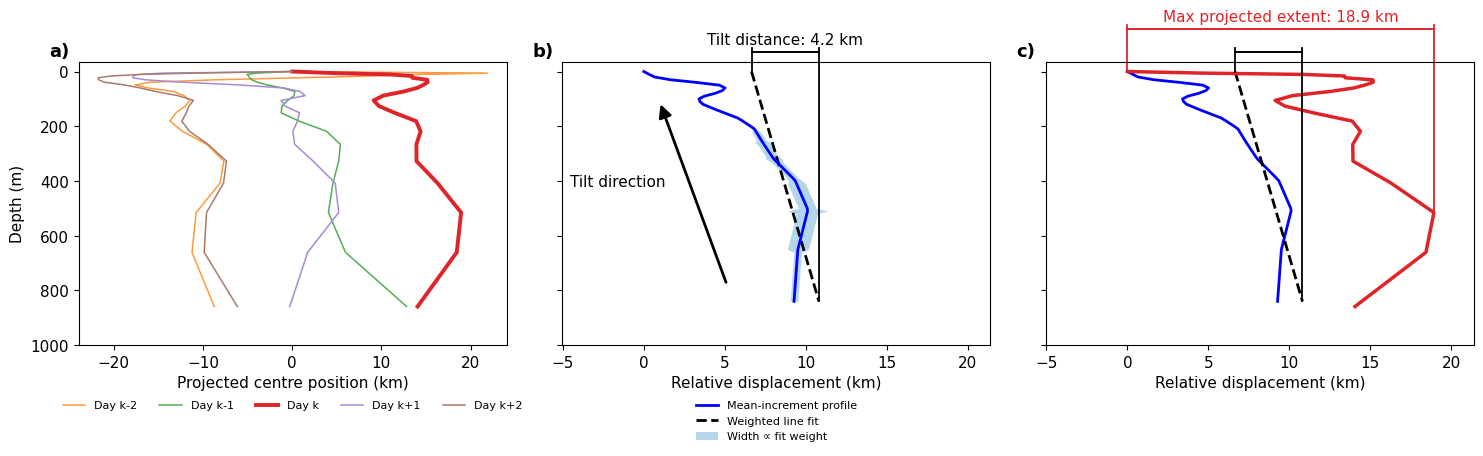

Observed eddy 2823, reference Day 10118
Reference depth: 0.0–858.9 m; fit labels: 0.0–840.0 m; TiltDis = 8.05 km


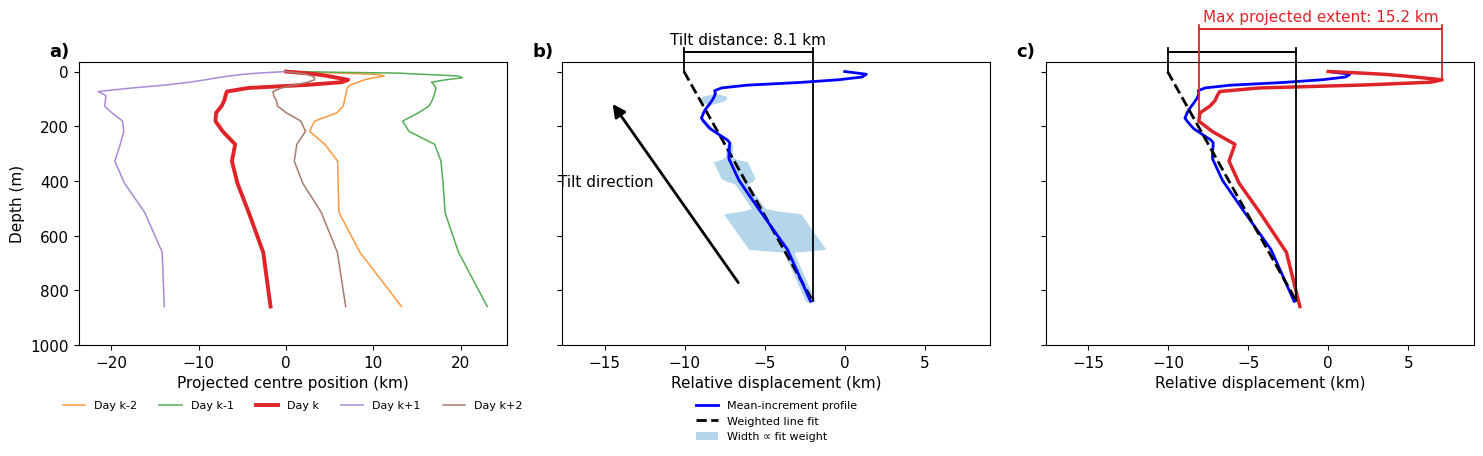

Observed eddy 2053, reference Day 7789
Reference depth: 0.0–858.9 m; fit labels: 0.0–840.0 m; TiltDis = 5.23 km


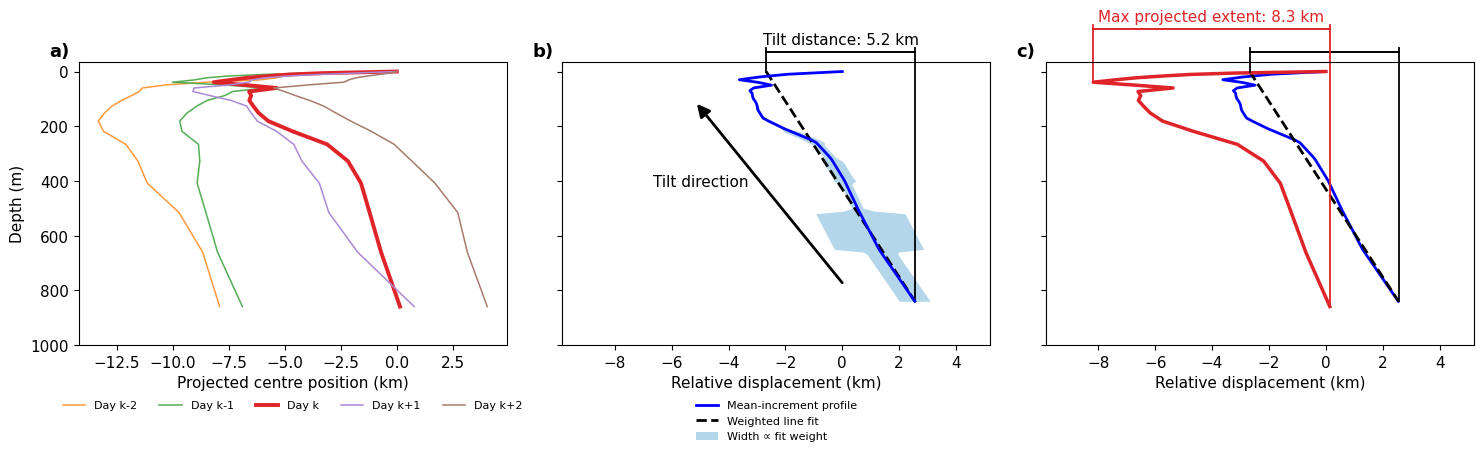

Observed eddy 2592, reference Day 9371
Reference depth: 0.0–407.9 m; fit labels: 0.0–390.0 m; TiltDis = 35.60 km


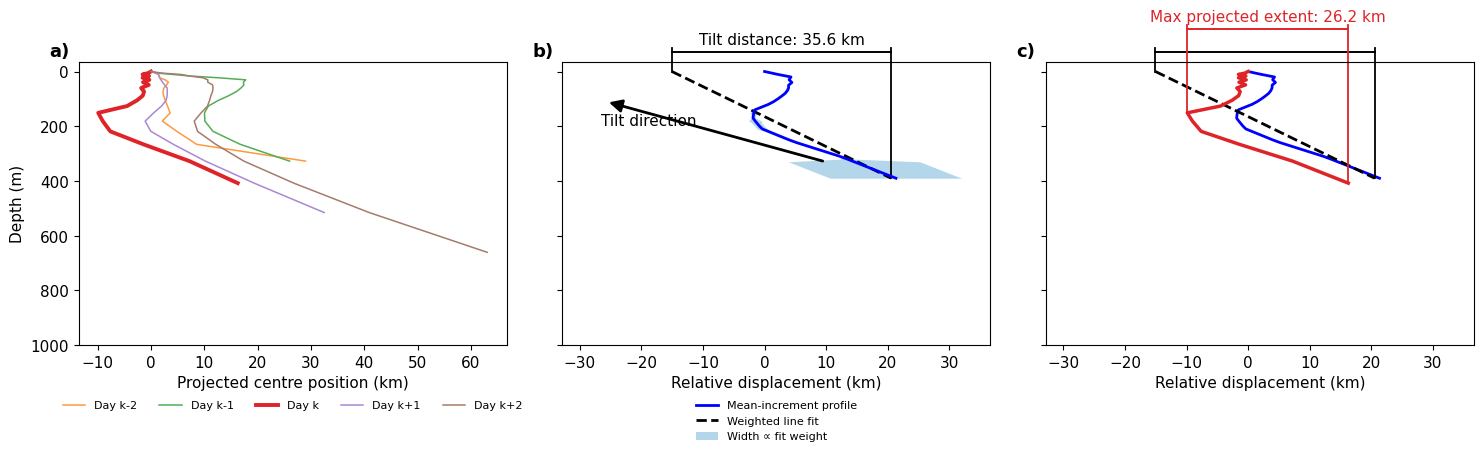

Observed eddy 1428, reference Day 5903
Reference depth: 0.0–858.9 m; fit labels: 0.0–840.0 m; TiltDis = 21.60 km


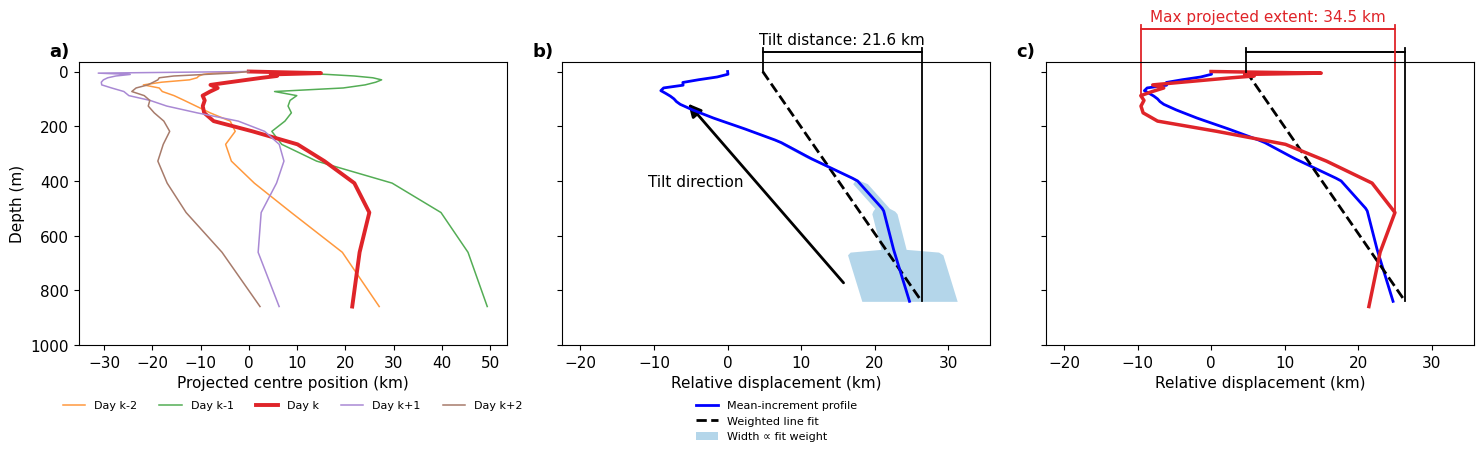

Observed eddy 2153, reference Day 8076
Reference depth: 0.0–858.9 m; fit labels: 0.0–840.0 m; TiltDis = 38.37 km


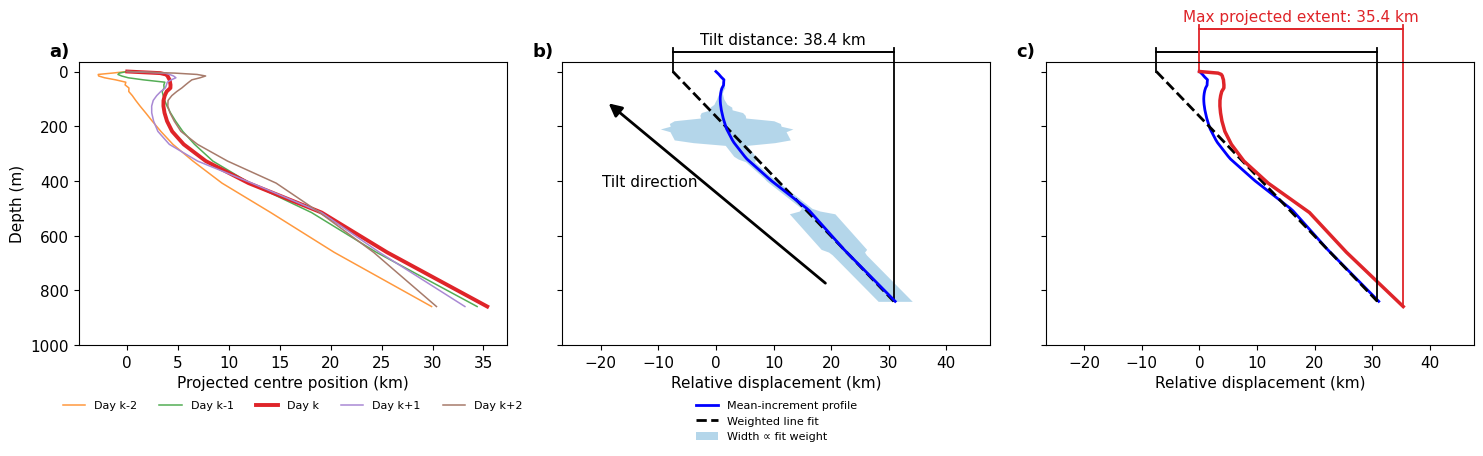

Observed eddy 2318, reference Day 8584
Reference depth: 0.0–858.9 m; fit labels: 0.0–840.0 m; TiltDis = 51.85 km


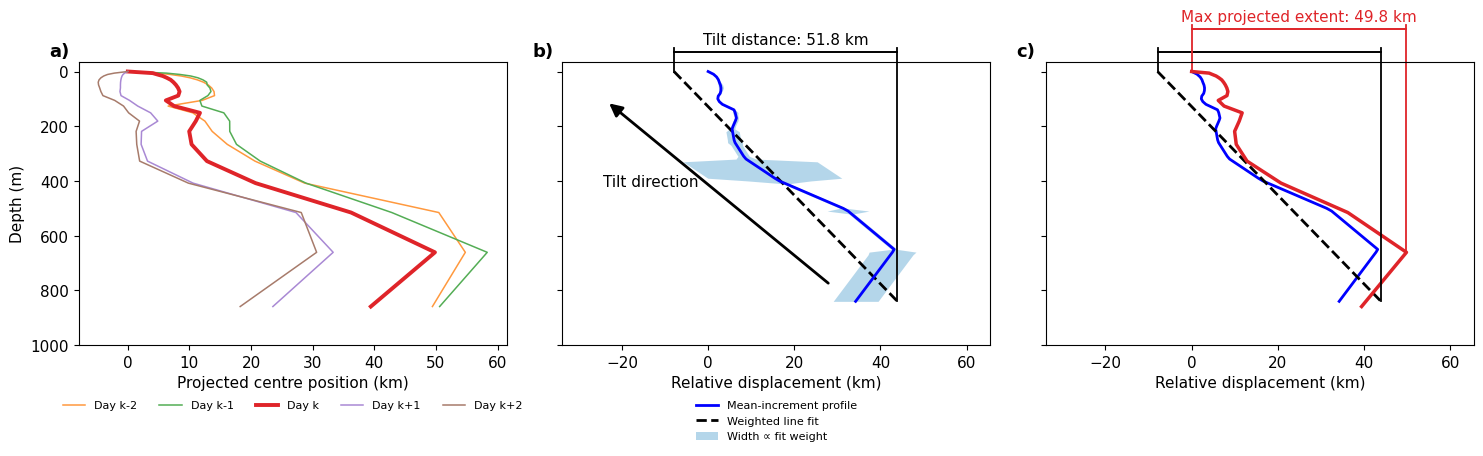

Observed eddy 1359, reference Day 5716
Reference depth: 0.0–858.9 m; fit labels: 0.0–840.0 m; TiltDis = 12.36 km


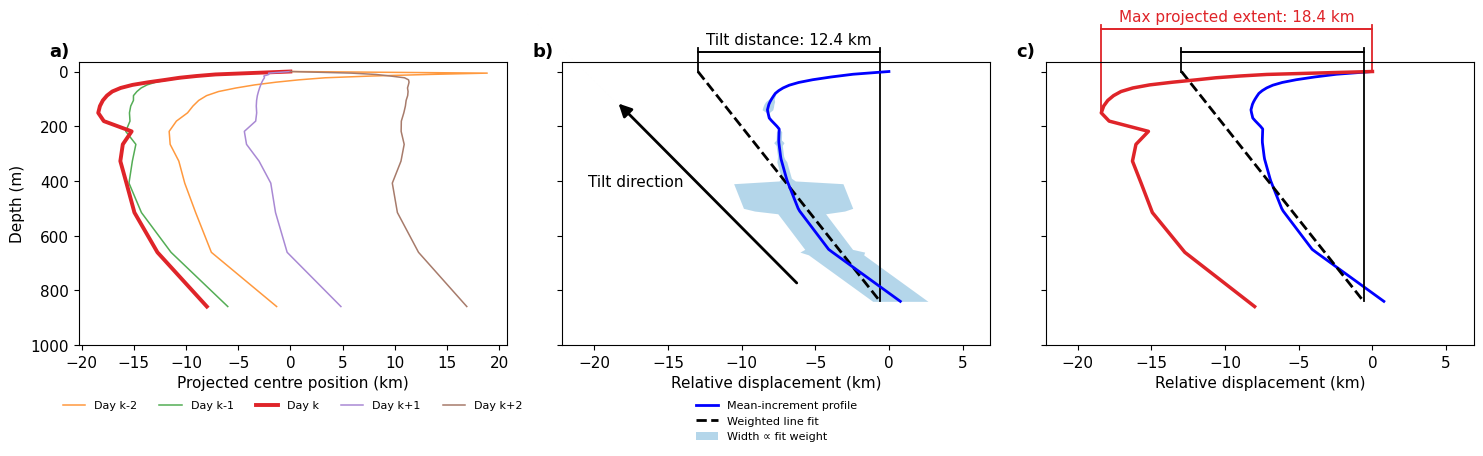

Observed eddy 823, reference Day 4017
Reference depth: 0.0–660.8 m; fit labels: 0.0–650.0 m; TiltDis = 20.80 km


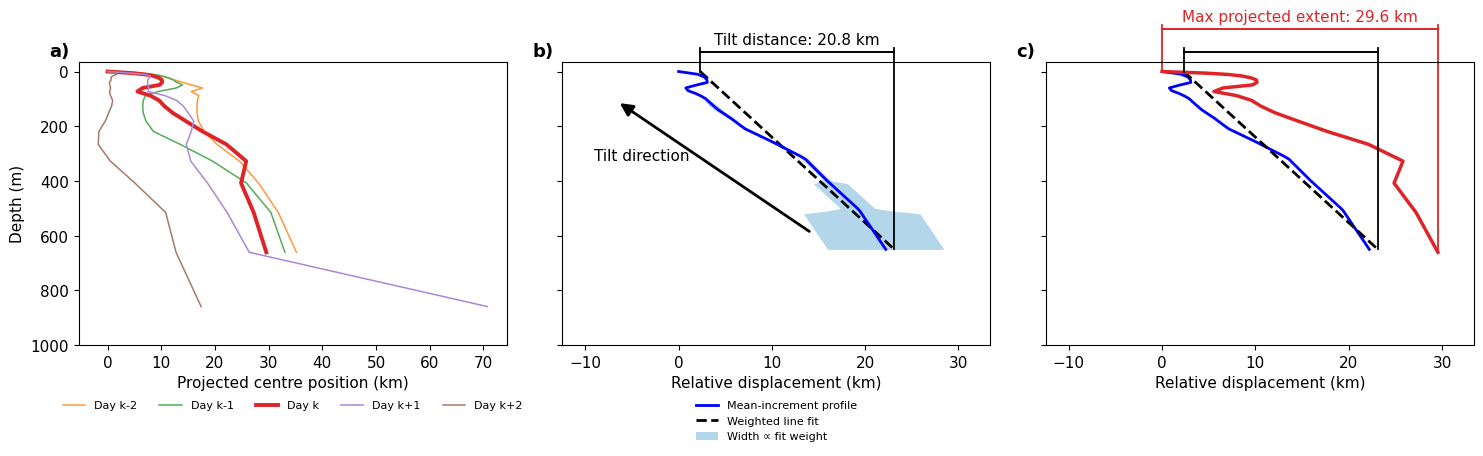

Observed eddy 462, reference Day 2849
Reference depth: 0.0–515.4 m; fit labels: 0.0–500.0 m; TiltDis = 21.06 km


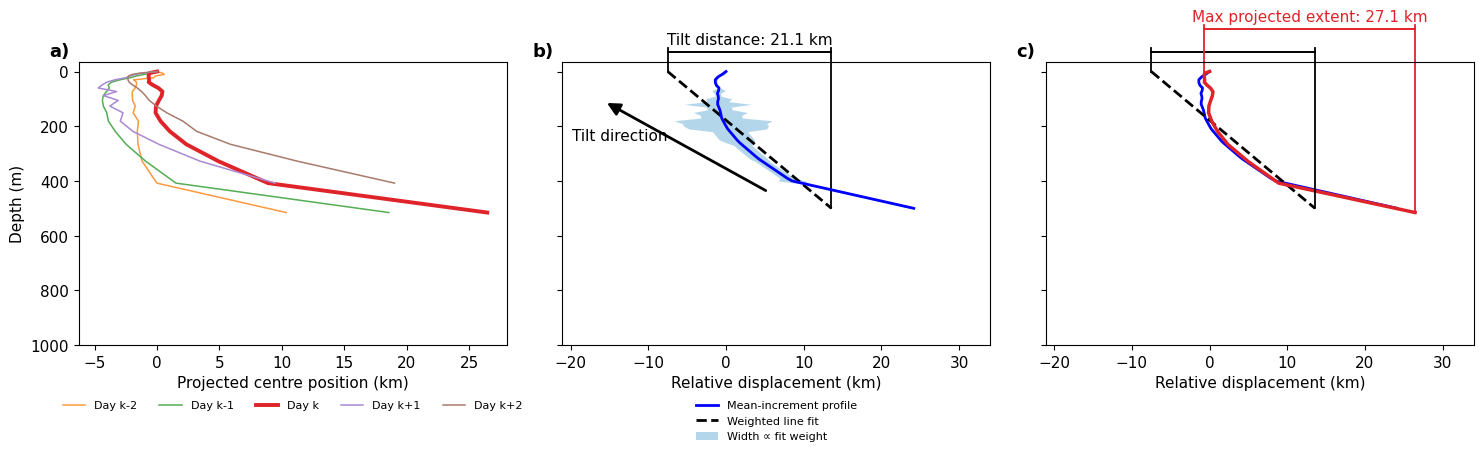

Observed eddy 1689, reference Day 6671
Reference depth: 0.0–858.9 m; fit labels: 0.0–840.0 m; TiltDis = 25.56 km


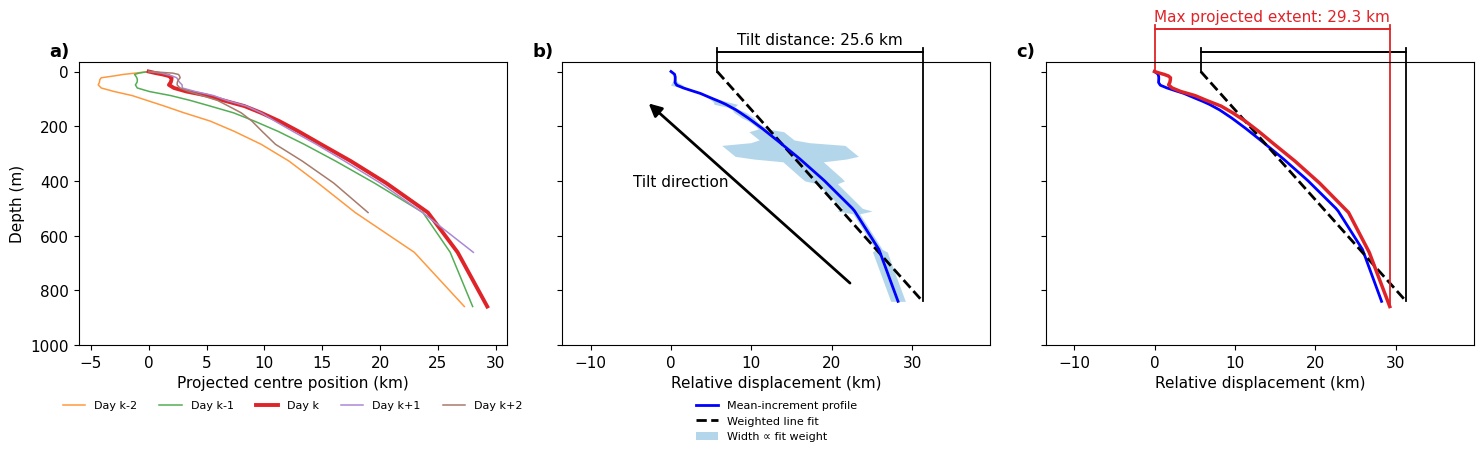

Observed eddy 1590, reference Day 6384
Reference depth: 0.0–858.9 m; fit labels: 0.0–840.0 m; TiltDis = 15.69 km


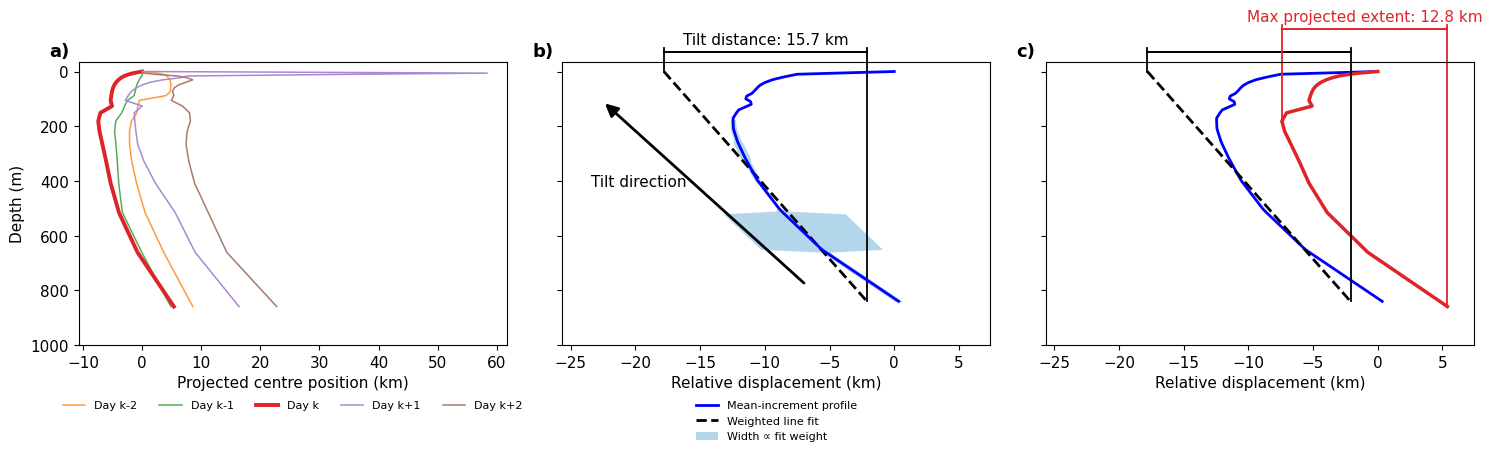

Observed eddy 2051, reference Day 7771
Reference depth: 0.0–858.9 m; fit labels: 0.0–840.0 m; TiltDis = 20.43 km


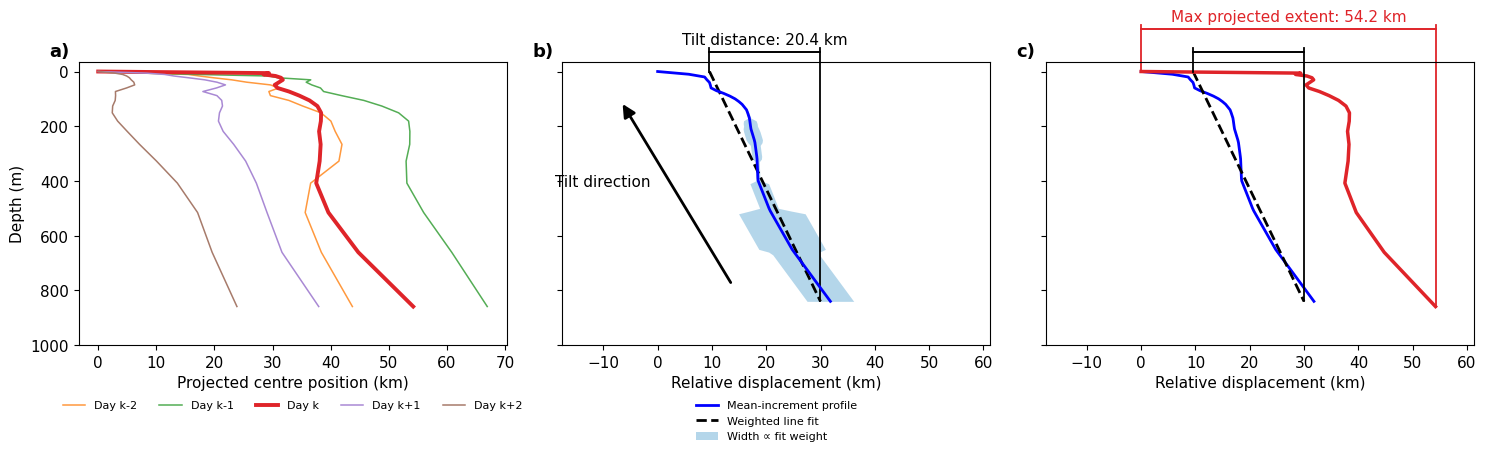

Observed eddy 2098, reference Day 7898
Reference depth: 0.0–858.9 m; fit labels: 0.0–840.0 m; TiltDis = 17.73 km


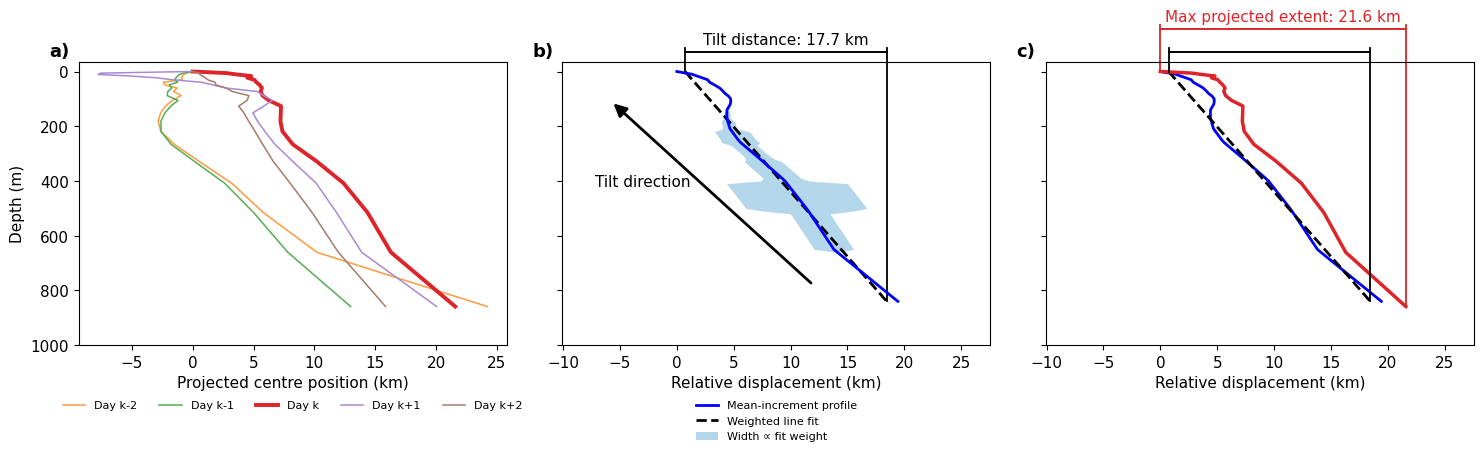

Observed eddy 992, reference Day 4598
Reference depth: 0.0–858.9 m; fit labels: 0.0–840.0 m; TiltDis = 42.72 km


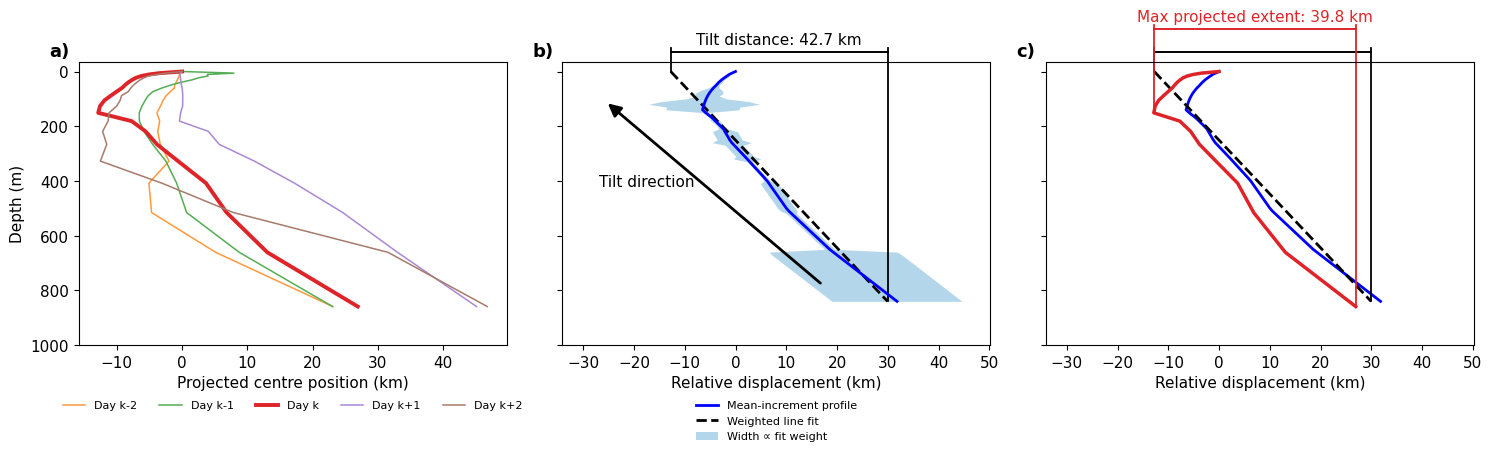

Observed eddy 2302, reference Day 8562
Reference depth: 0.0–858.9 m; fit labels: 0.0–840.0 m; TiltDis = 26.75 km


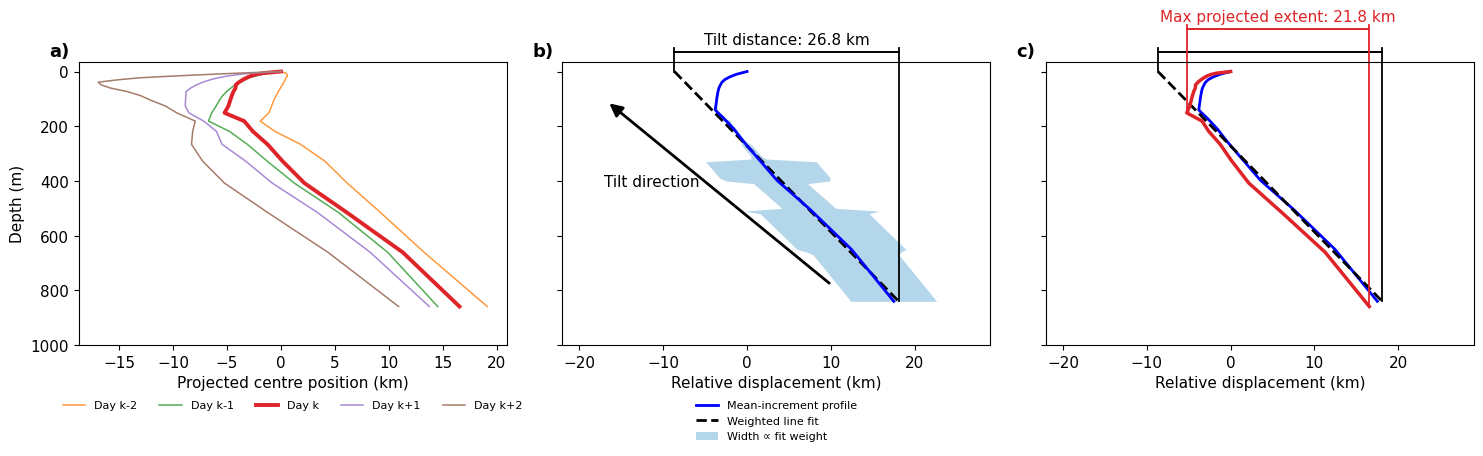

Observed eddy 2281, reference Day 8484
Reference depth: 0.0–858.9 m; fit labels: 0.0–840.0 m; TiltDis = 48.71 km


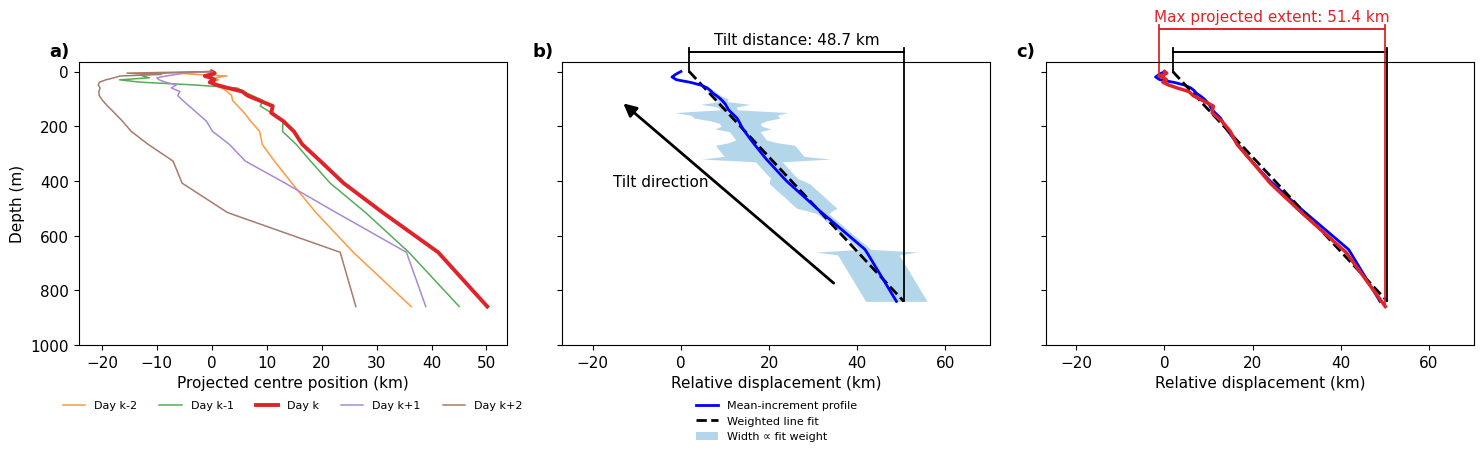

Observed eddy 1876, reference Day 7201
Reference depth: 0.0–858.9 m; fit labels: 0.0–840.0 m; TiltDis = 52.84 km


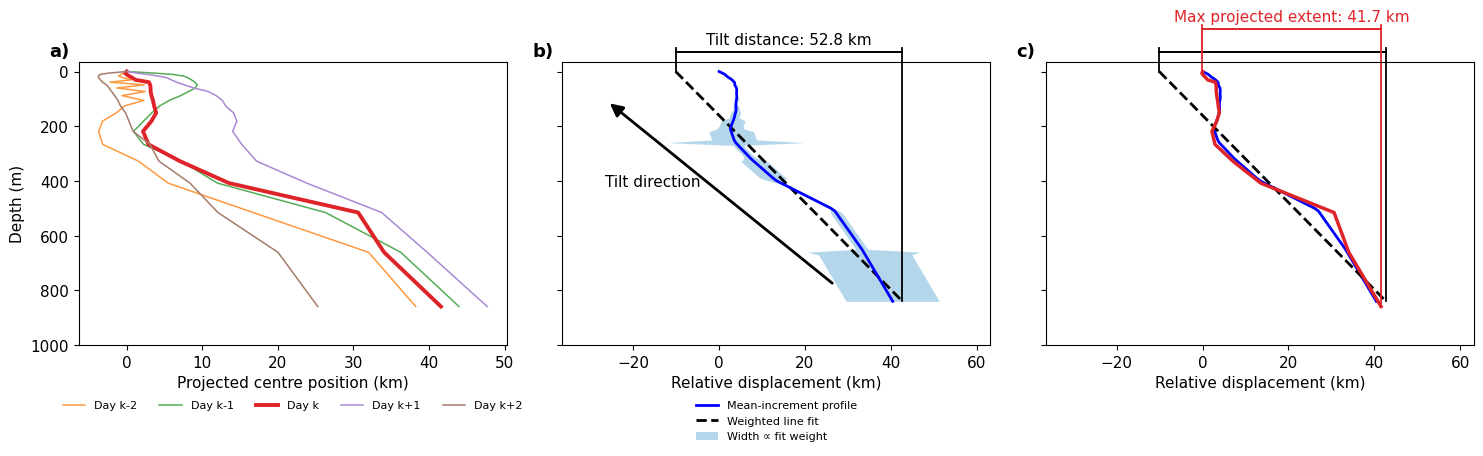

Observed eddy 2333, reference Day 8617
Reference depth: 0.0–327.4 m; fit labels: 0.0–310.0 m; TiltDis = 14.46 km


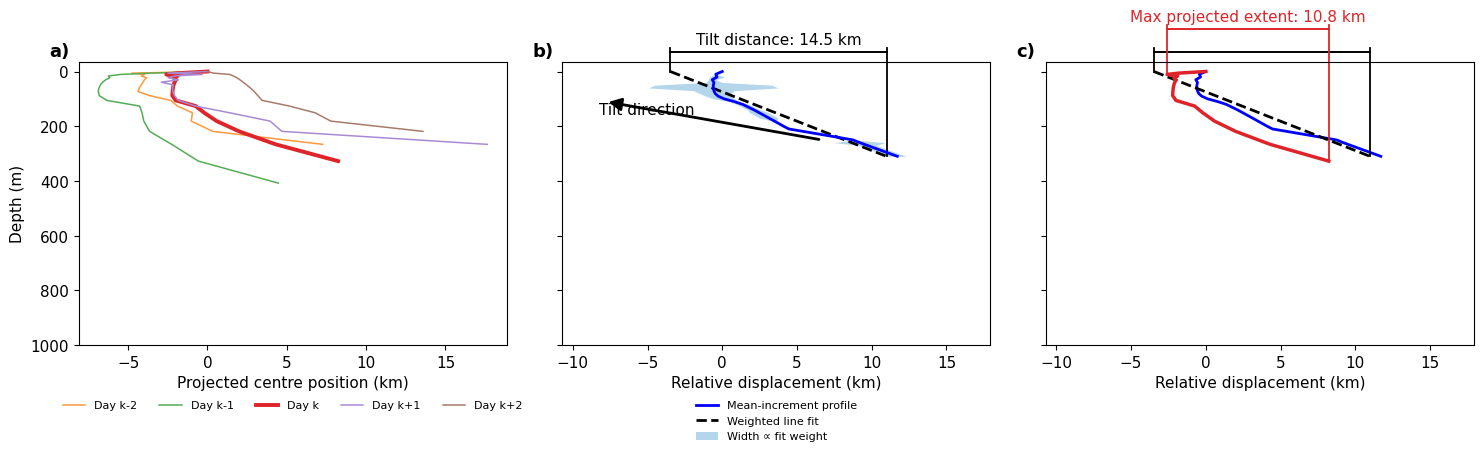

Observed eddy 971, reference Day 4483
Reference depth: 0.0–407.9 m; fit labels: 0.0–390.0 m; TiltDis = 11.73 km


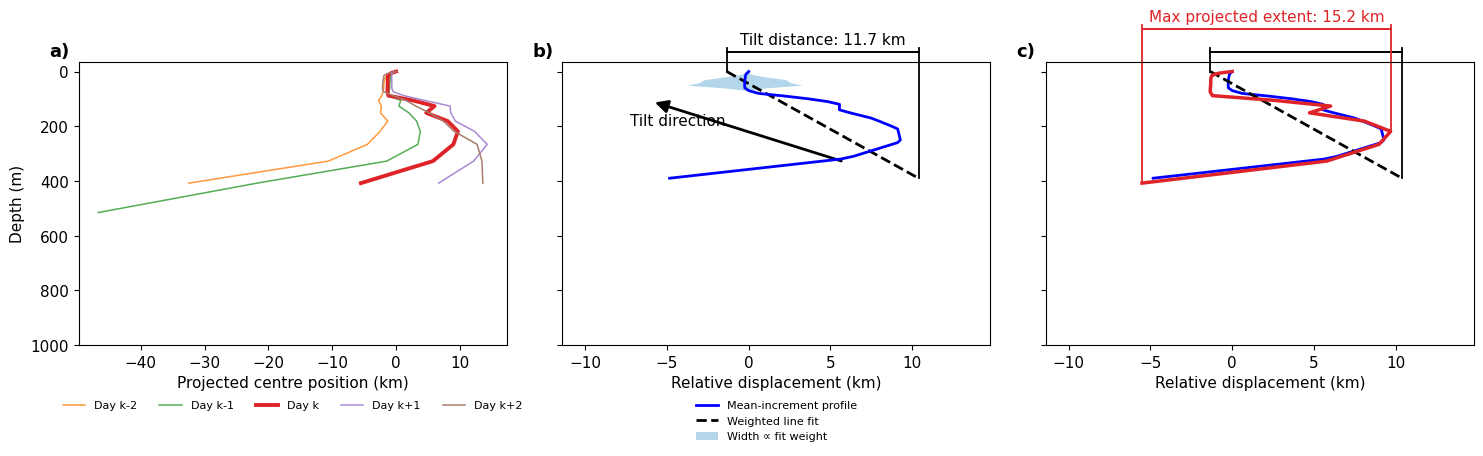

Observed eddy 1064, reference Day 4790
Reference depth: 0.0–858.9 m; fit labels: 0.0–840.0 m; TiltDis = 17.15 km


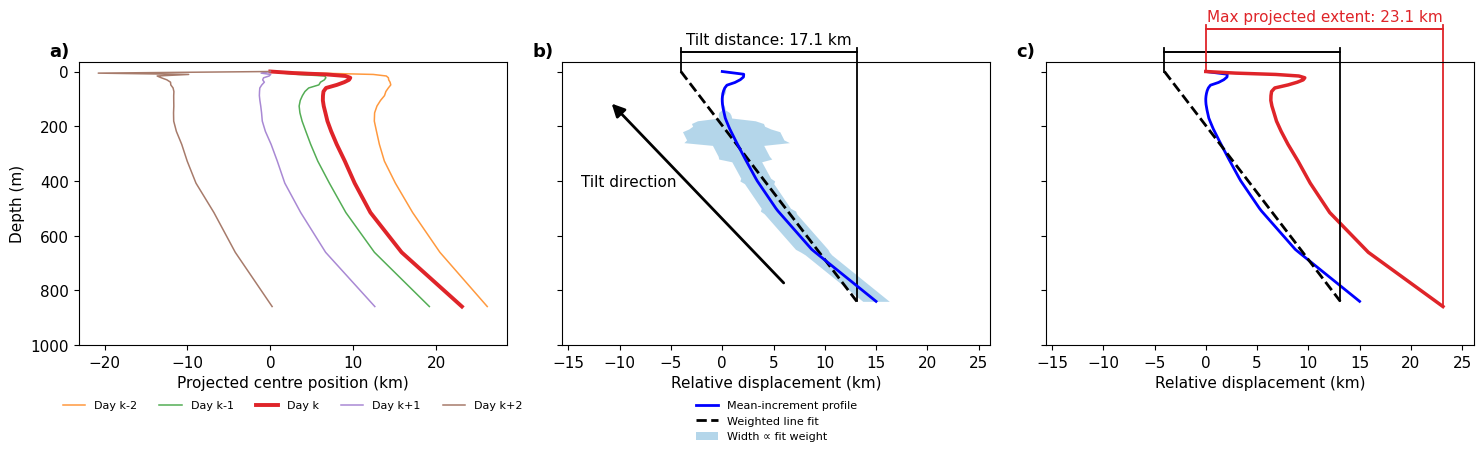

Observed eddy 109, reference Day 1752
Reference depth: 0.0–266.2 m; fit labels: 0.0–250.0 m; TiltDis = 9.75 km


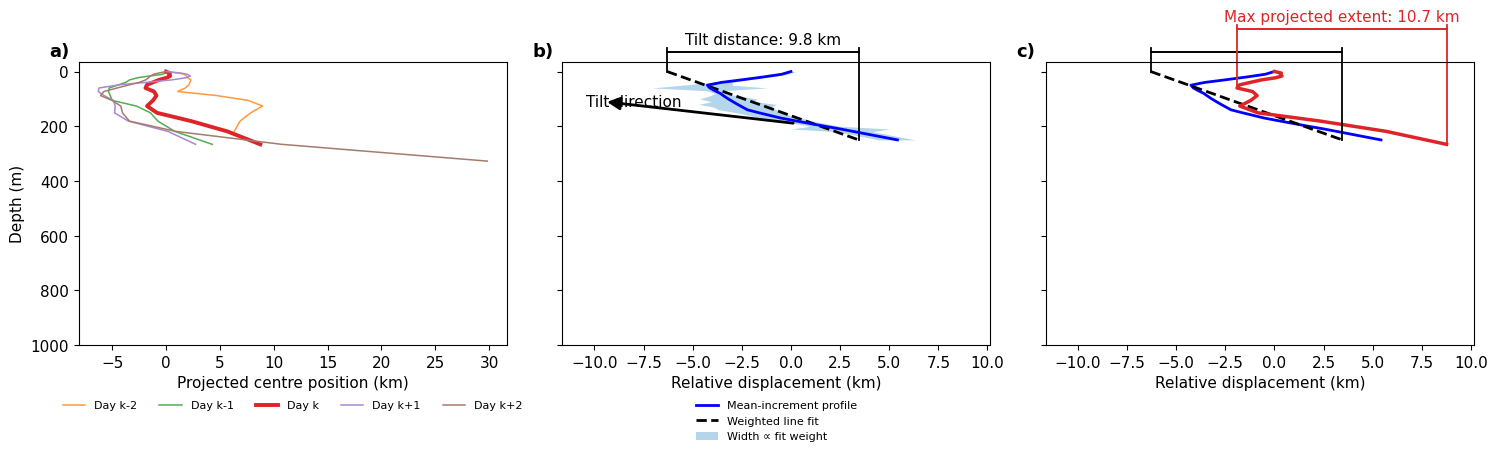

Observed eddy 1756, reference Day 6794
Reference depth: 0.0–858.9 m; fit labels: 0.0–840.0 m; TiltDis = 6.55 km


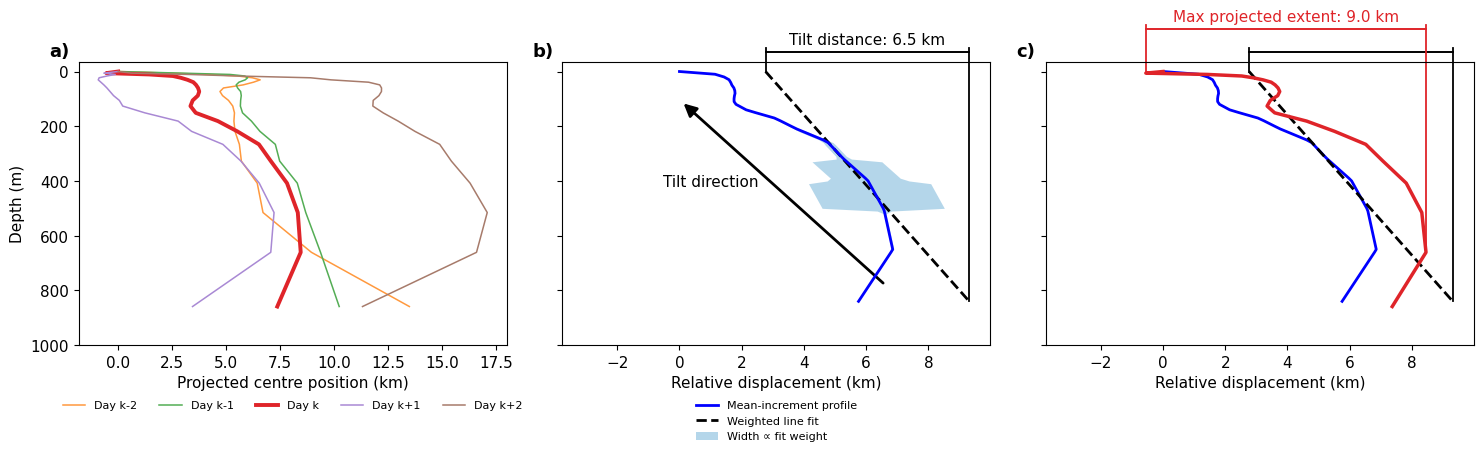

Observed eddy 1907, reference Day 7269
Reference depth: 0.0–858.9 m; fit labels: 0.0–840.0 m; TiltDis = 25.79 km


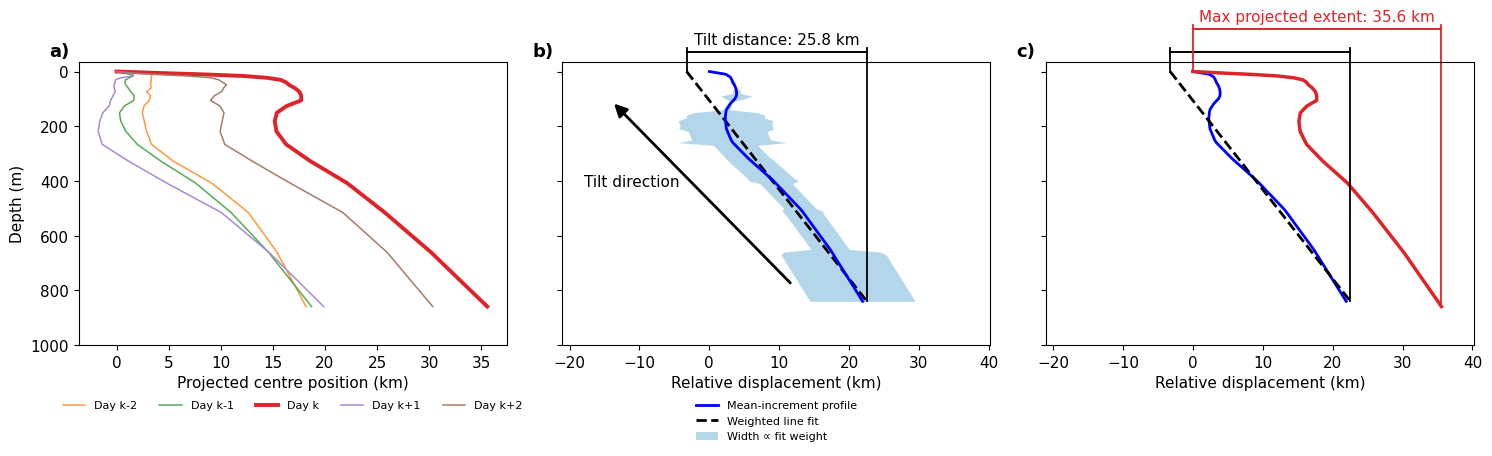

Observed eddy 1411, reference Day 5865
Reference depth: 0.0–858.9 m; fit labels: 0.0–840.0 m; TiltDis = 7.83 km


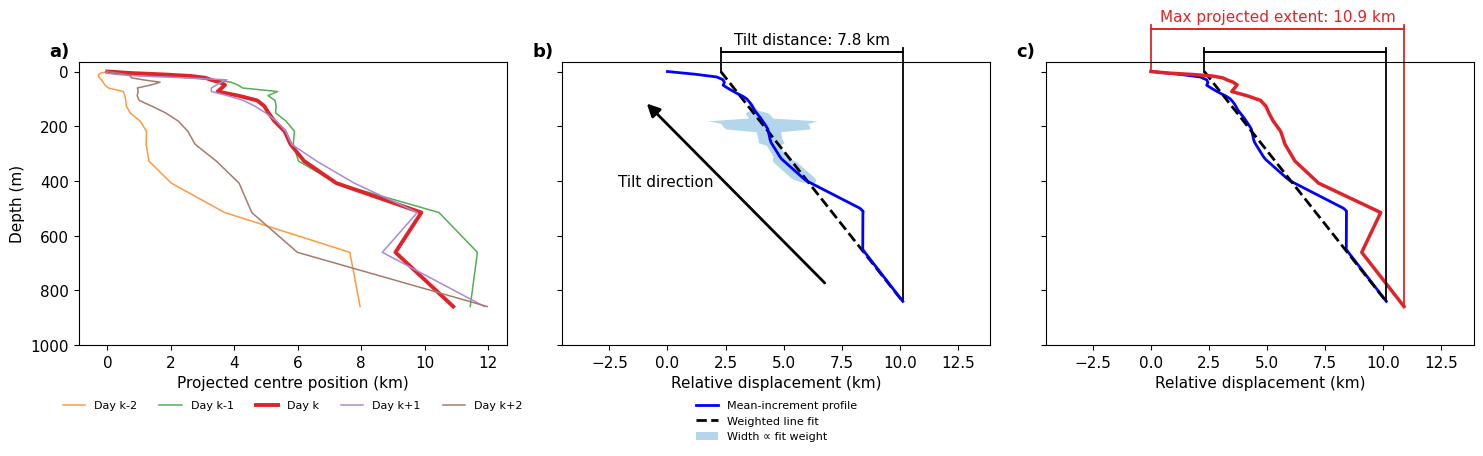

Observed eddy 1848, reference Day 7127
Reference depth: 0.0–858.9 m; fit labels: 0.0–840.0 m; TiltDis = 16.28 km


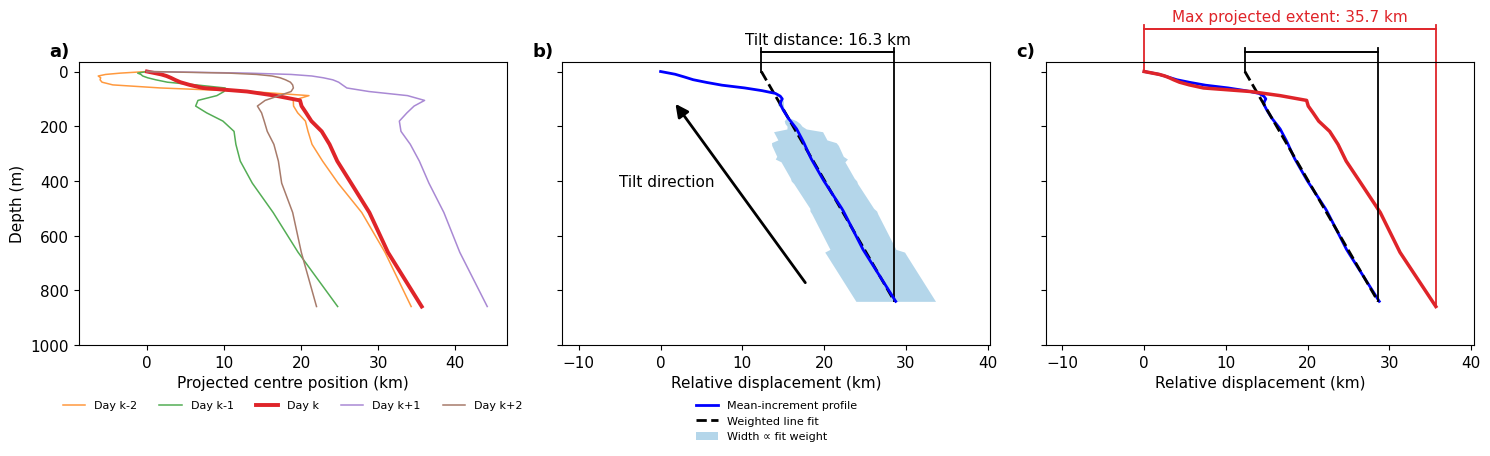

,Eddy,Day,TiltDis,TiltDir,ReferenceDepthMax,FitDepthMax,MaxProjectedExtent,AbsoluteDifference
0,2751,9884,24.87,342.6,858.918478,840.0,31.424254,6.558976
1,2062,7836,70.43,195.4,407.922192,390.0,92.989462,22.555996
2,686,3596,27.77,269.4,858.918478,840.0,33.479752,5.708868
3,1579,6334,19.34,50.4,858.918478,840.0,17.882472,1.456056
4,2137,7985,27.01,51.5,858.918478,840.0,31.330690,4.317516
5,1292,5511,32.55,136.0,858.918478,840.0,31.836514,0.718485
6,1245,5358,18.27,53.6,858.918478,840.0,18.554612,0.288161
7,1003,4591,13.18,297.2,660.806374,500.0,22.608173,9.430604
8,2685,9648,81.81,283.7,858.918478,840.0,134.790231,52.977875
9,1619,6520,12.68,1.0,858.918478,840.0,15.958859,3.278155


In [10]:
# One unchanged three-panel schematic per sampled eddy-day.
results = []
for EDDY, DAY in selected:
    trial = profiles.loc[profiles.Eddy.eq(EDDY) & profiles.Day.between(DAY - NUM // 2, DAY + NUM // 2)]
    results.append(plot_schematic(EDDY, DAY, trial))
results = pd.DataFrame(results)
display(results.round({'TiltDis': 2, 'TiltDir': 1}))
if SAVE:
    results.to_csv(OUT / 'delta_tilt_schematic_selected_examples.csv', index=False)
    print(f'Saved {len(results)} PNG/PDF pairs and selection table to {OUT}')

**Reading panel c.** The red bracket is the reference day's maximum minus minimum position **projected onto the fitted tilt axis**. It illustrates the older schematic's “max displacement” comparison, but is not necessarily the maximum pairwise 2-D displacement or maximum displacement from the surface. The black bracket is the horizontal endpoint separation of the weighted fit to the reconstructed, smoothed profile. They need not agree: the reference profile can curve, and the delta method averages increments across days and downweights inconsistent increments.

The blue ribbon in b encodes relative fit weights; it is **not a confidence interval**. Missing days and differing profile depths can change the number of contributions with depth. Panel a still displays the full neighbouring profiles for context; reconstruction and fitting in b/c use only the reference day’s supported depth intervals. This notebook tests the corrected approach without modifying the production pipeline.

## Optional: largest projected-extent versus delta-tilt differences

Set `RUN_DIFFERENCE_SEARCH=True` in the first controls cell to scan **all eddy-days in `PROFILE_PATH`**, regardless of `EDDY_ID`, `REFERENCE_DAY`, `N_IMAGES` or the random sample. The score is

$$\left|\mathrm{maximum\ projected\ extent}-\mathrm{delta\ tilt\ distance}\right|\quad\text{(km)}.$$

For each day, projected extent uses that day's centres projected onto **its own delta fit's horizontal axis**, exactly as in panel c. It is not maximum pairwise 2-D separation. The scan uses the current depth/window/weight settings and retains the reference-day depth limit. It includes every observed day with a valid nonzero fit; unlike the random illustration sampler, it does not require every neighbouring day to pass the full-depth screening. Missing or invalid fits and track edges without a centred window are excluded.

This can take time. Depth increments are computed once per eddy, and progress prints every 100 eddies. Results remain in `difference_ranking`; no new cache is created. Change `TOP_N_DIFFERENCES` and rerun just the **last plotting cell** to inspect more or fewer results without rescanning. Multiple top-ranked days may belong to the same eddy. Positive `Difference` means projected extent exceeds delta tilt; ranking uses `AbsoluteDifference`.

In [5]:
if RUN_DIFFERENCE_SEARCH:
    def report_search(done, total, valid):
        if done == 1 or done % 100 == 0 or done == total:
            print(f'Scanned {done}/{total} eddies; {valid:,} valid eddy-days', flush=True)

    difference_search_settings = dict(depth_int=DEPTH_INT, max_depth=MAX_DEPTH,
        sigma=TEMPORAL_SIGMA_DAYS, half_window=NUM // 2,
        min_depth_range=MIN_DEPTH_RANGE, min_points=MIN_POINTS,
        bearing_offset=BEARING_OFFSET, eps=EPS)
    difference_ranking = scan_projected_extent_differences(
        all_profiles, **difference_search_settings, progress=report_search)
    print(f'Ranked {len(difference_ranking):,} eddy-days by absolute difference (km).')
    if SAVE:
        difference_ranking.to_csv(OUT / 'delta_tilt_schematic_difference_ranking.csv', index=False)
else:
    print('Full-dataset difference search skipped. Set RUN_DIFFERENCE_SEARCH=True to enable it.')

Scanned 1/2982 eddies; 20 valid eddy-days
Scanned 100/2982 eddies; 4,034 valid eddy-days
Scanned 200/2982 eddies; 7,388 valid eddy-days
Scanned 300/2982 eddies; 10,574 valid eddy-days
Scanned 400/2982 eddies; 14,382 valid eddy-days
Scanned 500/2982 eddies; 17,828 valid eddy-days
Scanned 600/2982 eddies; 20,800 valid eddy-days
Scanned 700/2982 eddies; 24,007 valid eddy-days
Scanned 800/2982 eddies; 27,420 valid eddy-days
Scanned 900/2982 eddies; 31,047 valid eddy-days
Scanned 1000/2982 eddies; 34,624 valid eddy-days
Scanned 1100/2982 eddies; 38,329 valid eddy-days
Scanned 1200/2982 eddies; 41,629 valid eddy-days
Scanned 1300/2982 eddies; 45,335 valid eddy-days
Scanned 1400/2982 eddies; 48,582 valid eddy-days
Scanned 1500/2982 eddies; 51,634 valid eddy-days
Scanned 1600/2982 eddies; 55,091 valid eddy-days
Scanned 1700/2982 eddies; 58,464 valid eddy-days
Scanned 1800/2982 eddies; 61,257 valid eddy-days
Scanned 1900/2982 eddies; 64,540 valid eddy-days
Scanned 2000/2982 eddies; 68,194 valid

,Rank,Eddy,Day,MaxProjectedExtent,TiltDis,TiltDir,Difference,AbsoluteDifference,ReferenceDepthMax,FitDepthMax
0,1,300,2362,280.81,12.39,46.63,268.42,268.42,407.92,200.0
1,2,746,3804,268.02,8.52,259.38,259.50,259.50,858.92,310.0
2,3,60,1646,197.07,15.75,351.01,181.32,181.32,858.92,390.0
3,4,60,1650,186.51,10.09,330.35,176.42,176.42,858.92,390.0
4,5,2040,7790,191.03,18.18,340.98,172.85,172.85,858.92,390.0
5,6,458,2854,175.81,6.27,352.70,169.54,169.54,407.92,250.0
6,7,638,3441,171.35,6.37,274.34,164.99,164.99,660.81,310.0
7,8,2733,9749,166.92,2.89,39.74,164.02,164.02,515.42,310.0
8,9,1489,6081,202.61,39.86,360.00,162.75,162.75,858.92,390.0
9,10,2577,9356,181.13,21.14,120.27,159.99,159.99,660.81,390.0


Rank 1: Eddy 300, Day 2362; absolute difference = 268.42 km (extent 280.81, delta 12.39)
Observed eddy 300, reference Day 2362
Reference depth: 0.0–407.9 m; fit labels: 0.0–200.0 m; TiltDis = 12.39 km


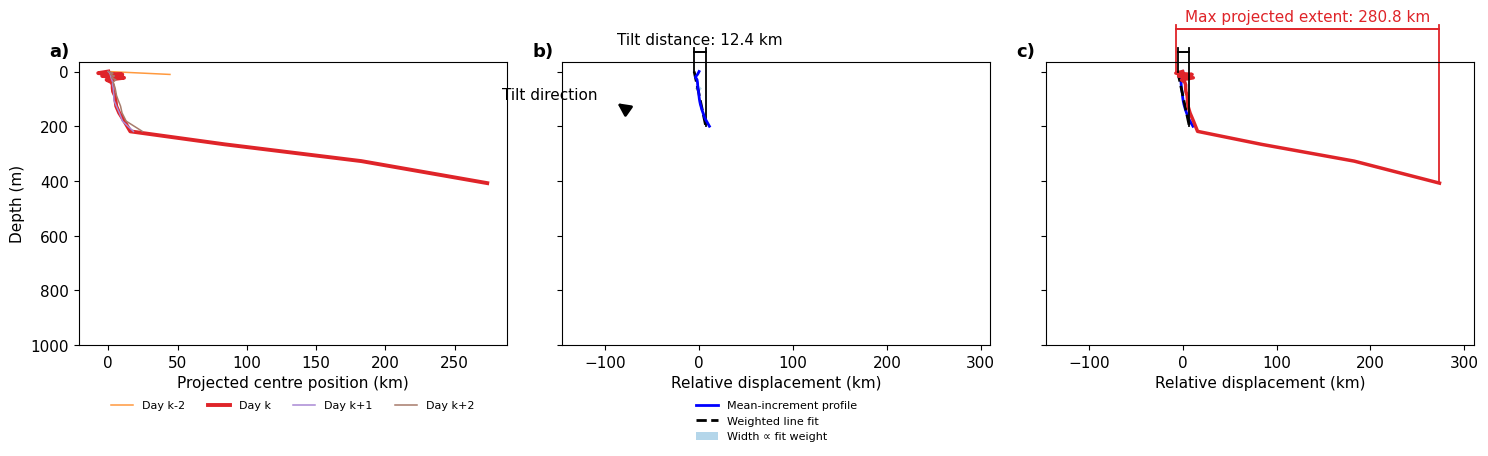

Rank 2: Eddy 746, Day 3804; absolute difference = 259.50 km (extent 268.02, delta 8.52)
Observed eddy 746, reference Day 3804
Reference depth: 0.0–858.9 m; fit labels: 0.0–310.0 m; TiltDis = 8.52 km


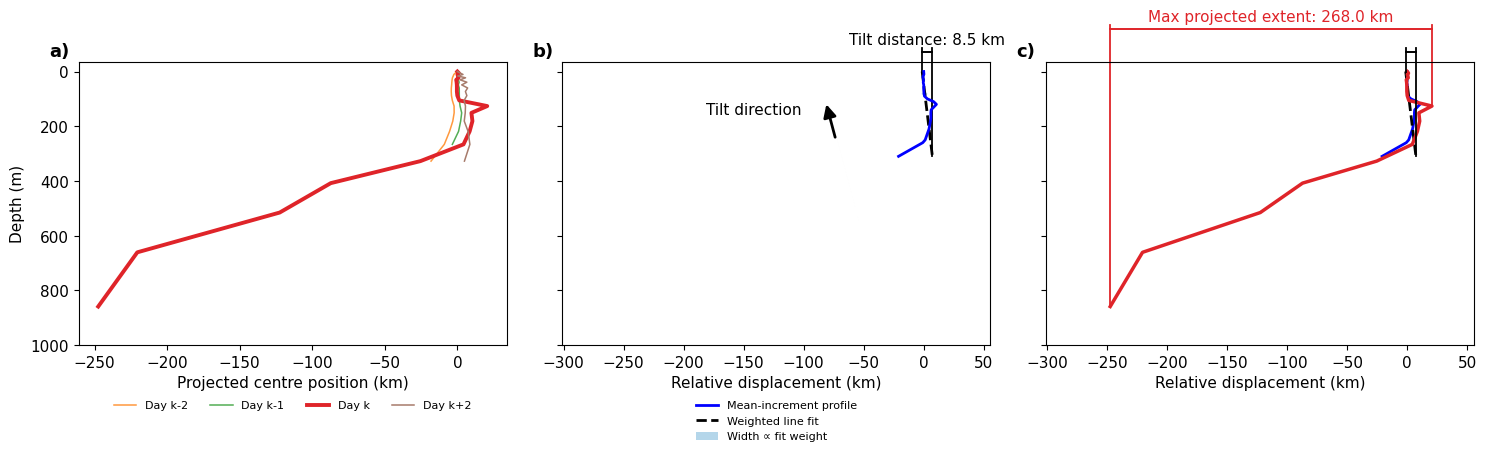

Rank 3: Eddy 60, Day 1646; absolute difference = 181.32 km (extent 197.07, delta 15.75)
Observed eddy 60, reference Day 1646
Reference depth: 0.0–858.9 m; fit labels: 0.0–390.0 m; TiltDis = 15.75 km


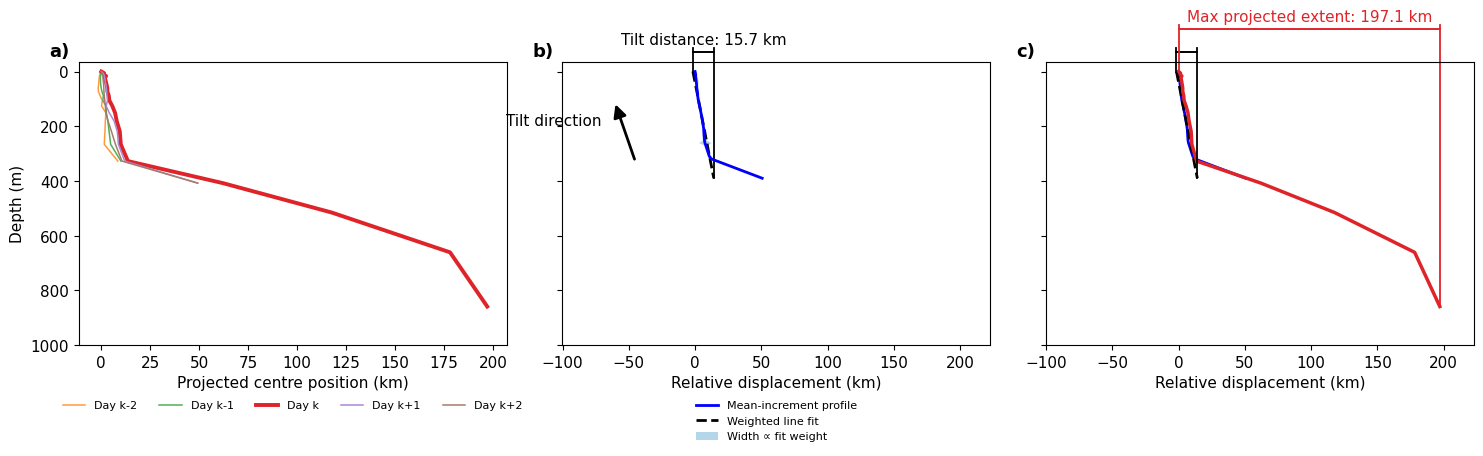

Rank 4: Eddy 60, Day 1650; absolute difference = 176.42 km (extent 186.51, delta 10.09)
Observed eddy 60, reference Day 1650
Reference depth: 0.0–858.9 m; fit labels: 0.0–390.0 m; TiltDis = 10.09 km


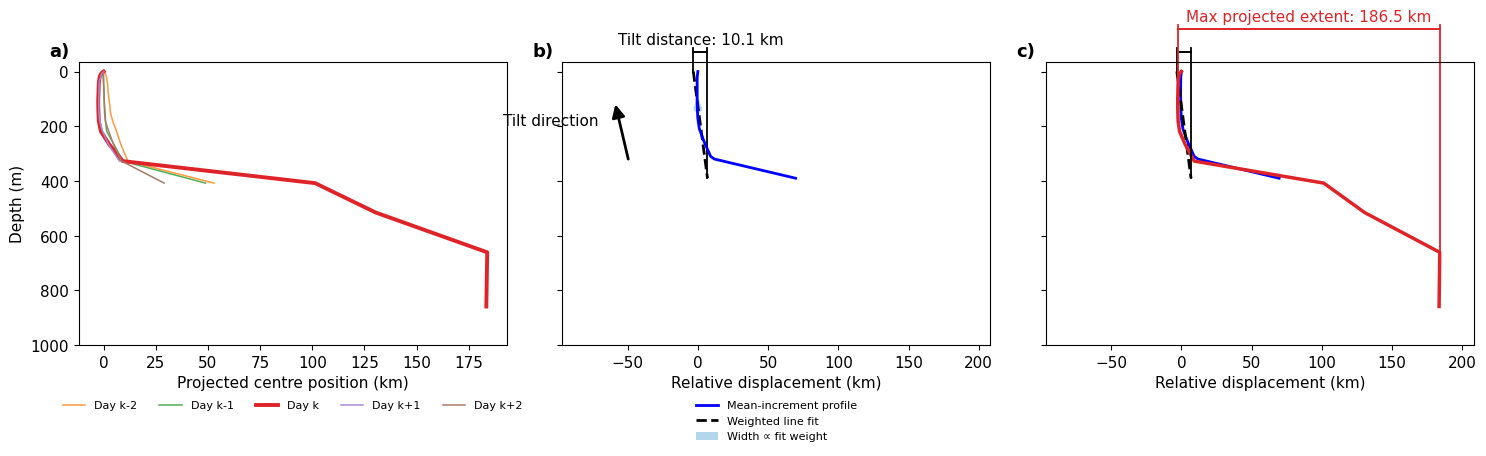

Rank 5: Eddy 2040, Day 7790; absolute difference = 172.85 km (extent 191.03, delta 18.18)
Observed eddy 2040, reference Day 7790
Reference depth: 0.0–858.9 m; fit labels: 0.0–390.0 m; TiltDis = 18.18 km


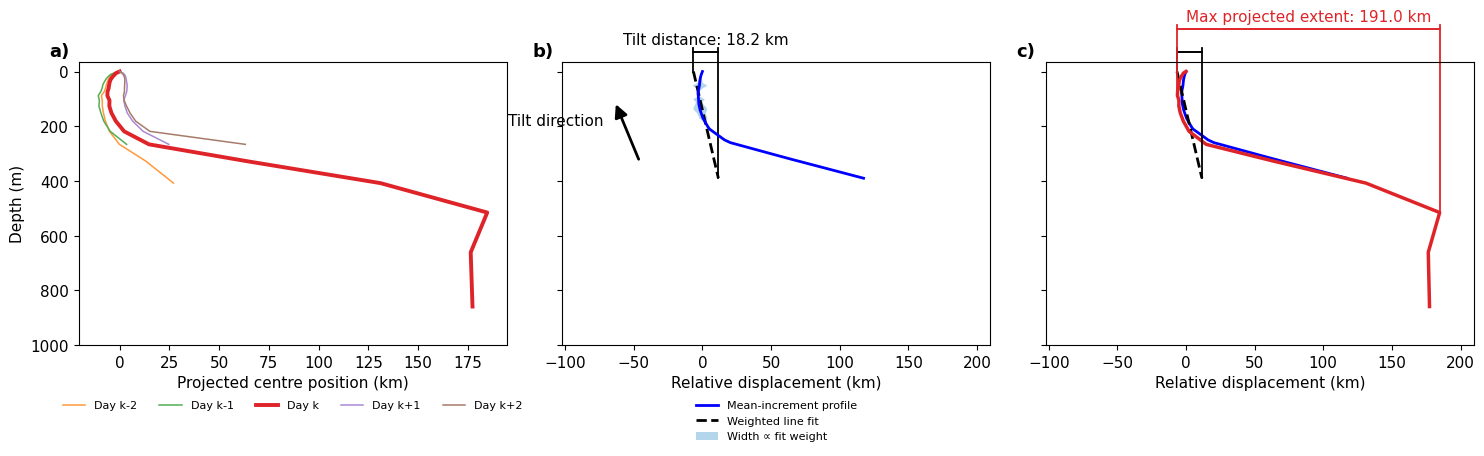

Rank 6: Eddy 458, Day 2854; absolute difference = 169.54 km (extent 175.81, delta 6.27)
Observed eddy 458, reference Day 2854
Reference depth: 0.0–407.9 m; fit labels: 0.0–250.0 m; TiltDis = 6.27 km


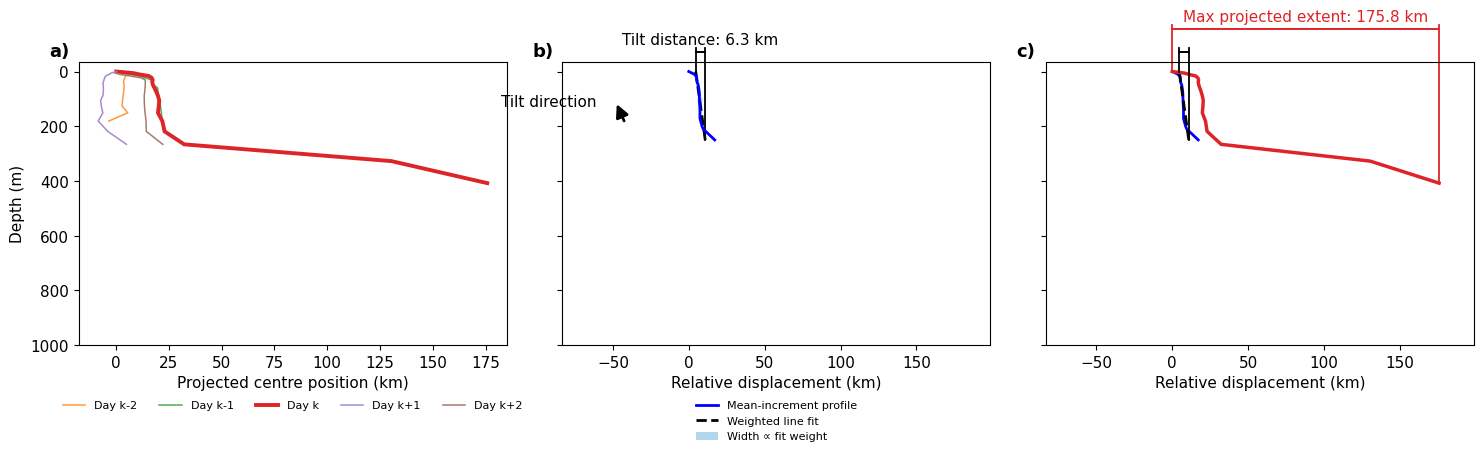

Rank 7: Eddy 638, Day 3441; absolute difference = 164.99 km (extent 171.35, delta 6.37)
Observed eddy 638, reference Day 3441
Reference depth: 0.0–660.8 m; fit labels: 0.0–310.0 m; TiltDis = 6.37 km


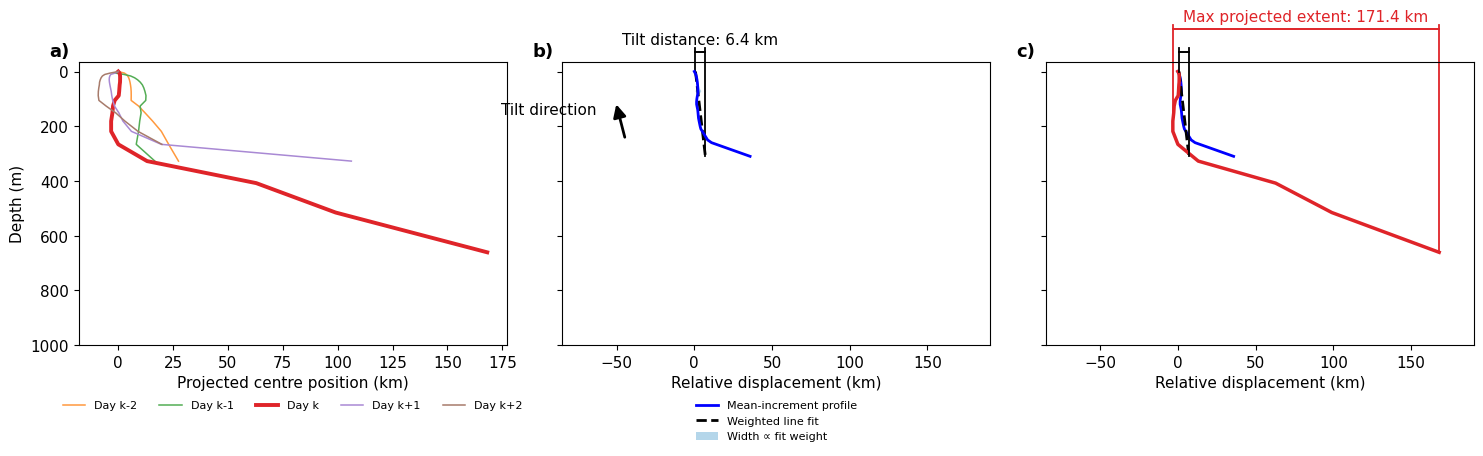

Rank 8: Eddy 2733, Day 9749; absolute difference = 164.02 km (extent 166.92, delta 2.89)
Observed eddy 2733, reference Day 9749
Reference depth: 0.0–515.4 m; fit labels: 0.0–310.0 m; TiltDis = 2.89 km


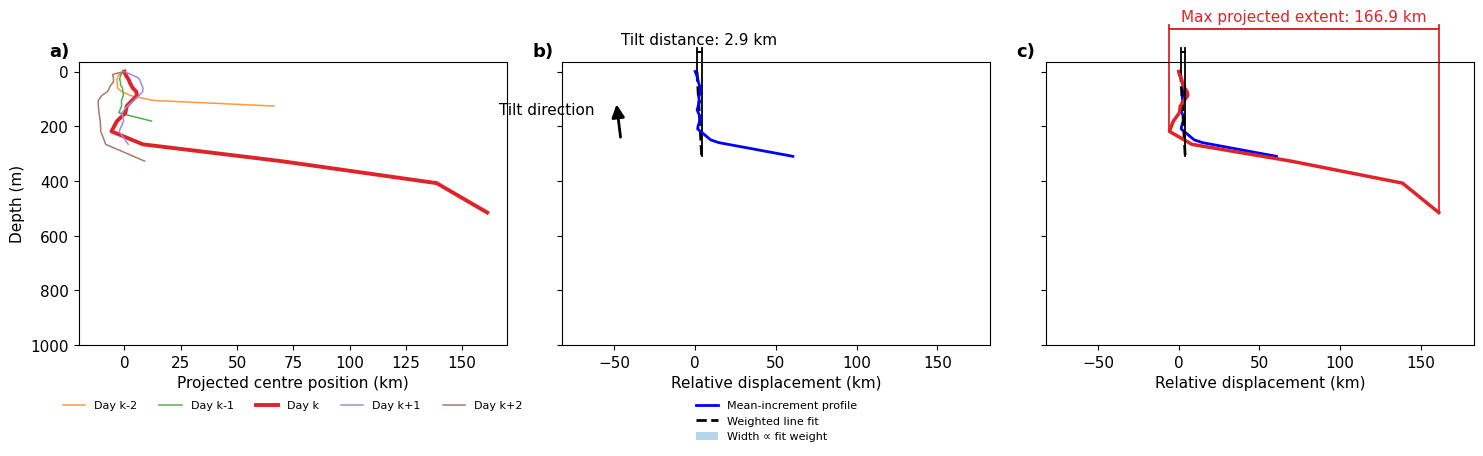

Rank 9: Eddy 1489, Day 6081; absolute difference = 162.75 km (extent 202.61, delta 39.86)
Observed eddy 1489, reference Day 6081
Reference depth: 0.0–858.9 m; fit labels: 0.0–390.0 m; TiltDis = 39.86 km


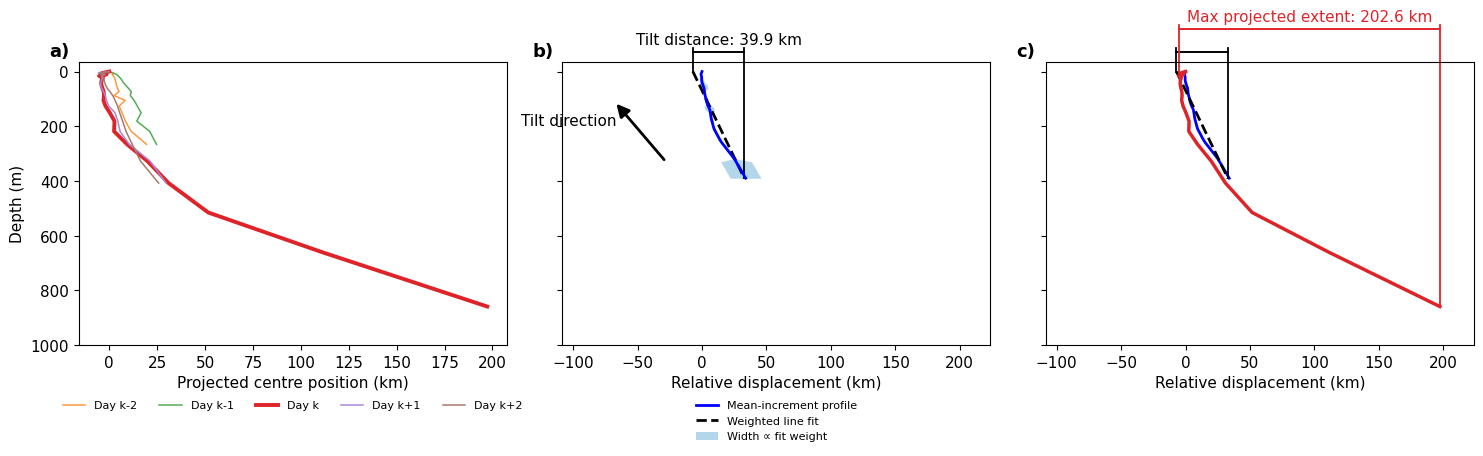

Rank 10: Eddy 2577, Day 9356; absolute difference = 159.99 km (extent 181.13, delta 21.14)
Observed eddy 2577, reference Day 9356
Reference depth: 0.0–660.8 m; fit labels: 0.0–390.0 m; TiltDis = 21.14 km


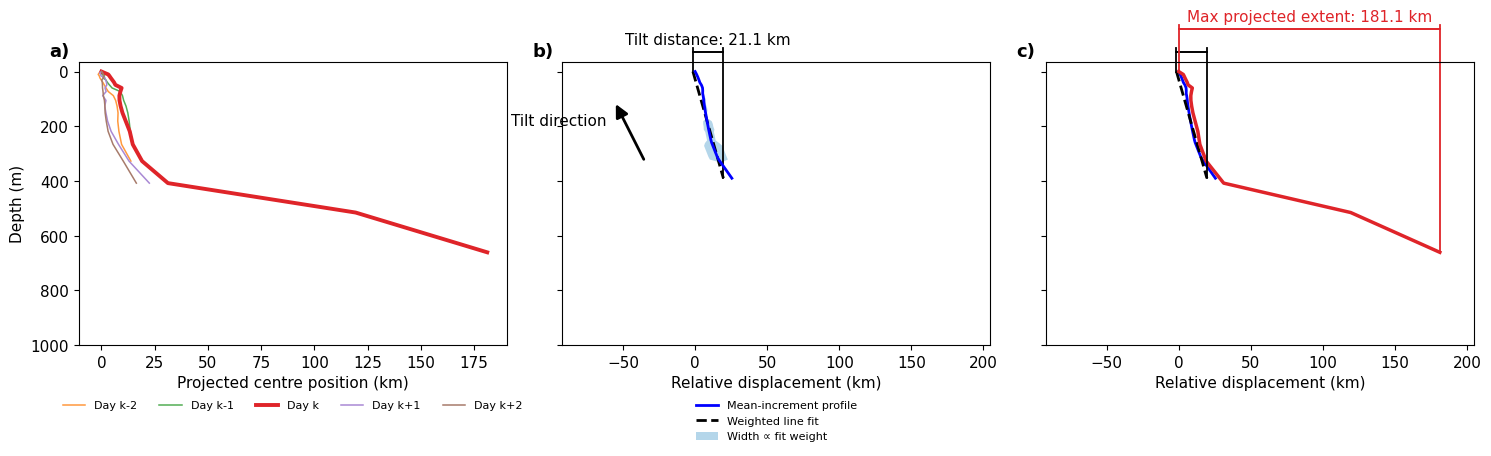

Rank 11: Eddy 458, Day 2865; absolute difference = 159.76 km (extent 166.02, delta 6.26)
Observed eddy 458, reference Day 2865
Rank 12: Eddy 1380, Day 5767; absolute difference = 158.60 km (extent 183.97, delta 25.37)
Observed eddy 1380, reference Day 5767
Reference depth: 0.0–858.9 m; fit labels: 0.0–650.0 m; TiltDis = 25.37 km


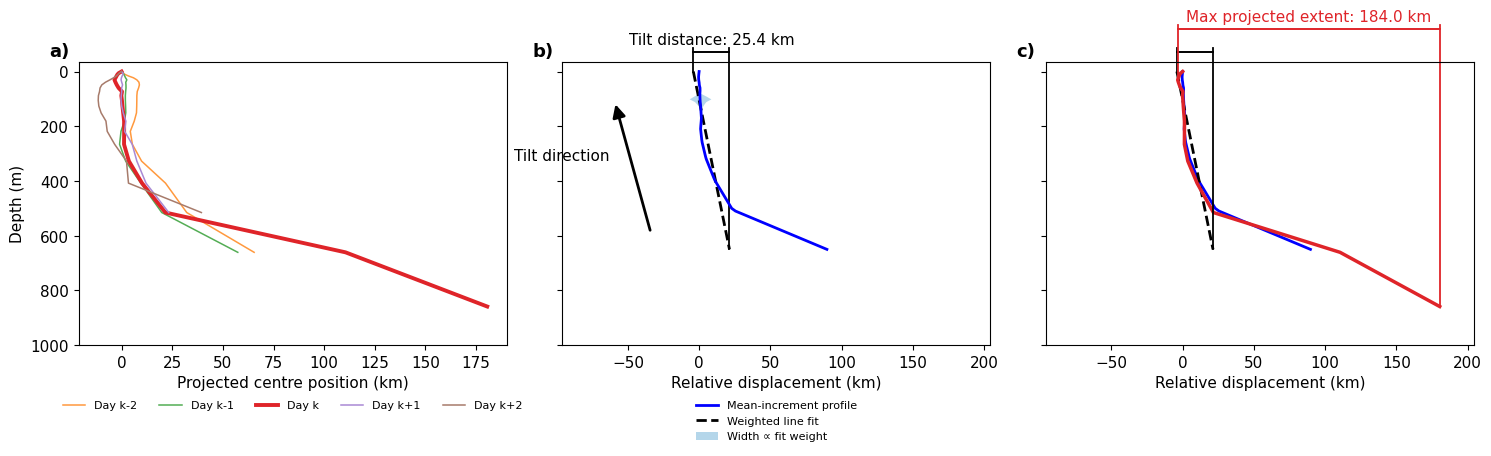

Rank 13: Eddy 532, Day 3152; absolute difference = 156.19 km (extent 188.20, delta 32.01)
Observed eddy 532, reference Day 3152
Reference depth: 0.0–660.8 m; fit labels: 0.0–500.0 m; TiltDis = 32.01 km


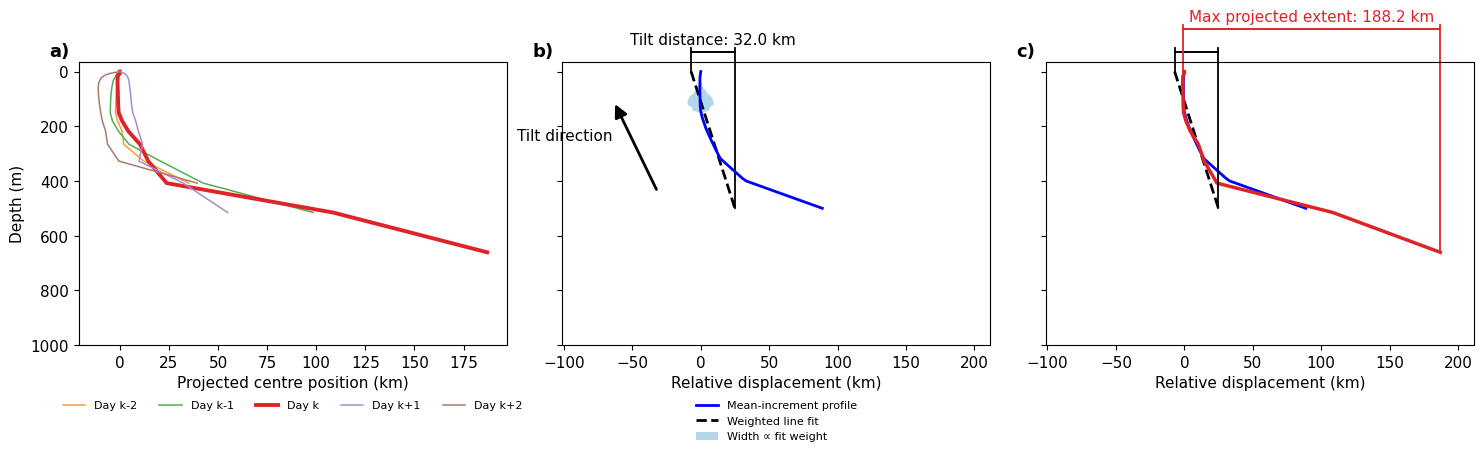

Rank 14: Eddy 884, Day 4197; absolute difference = 154.88 km (extent 184.00, delta 29.13)
Observed eddy 884, reference Day 4197
Reference depth: 0.0–858.9 m; fit labels: 0.0–500.0 m; TiltDis = 29.13 km


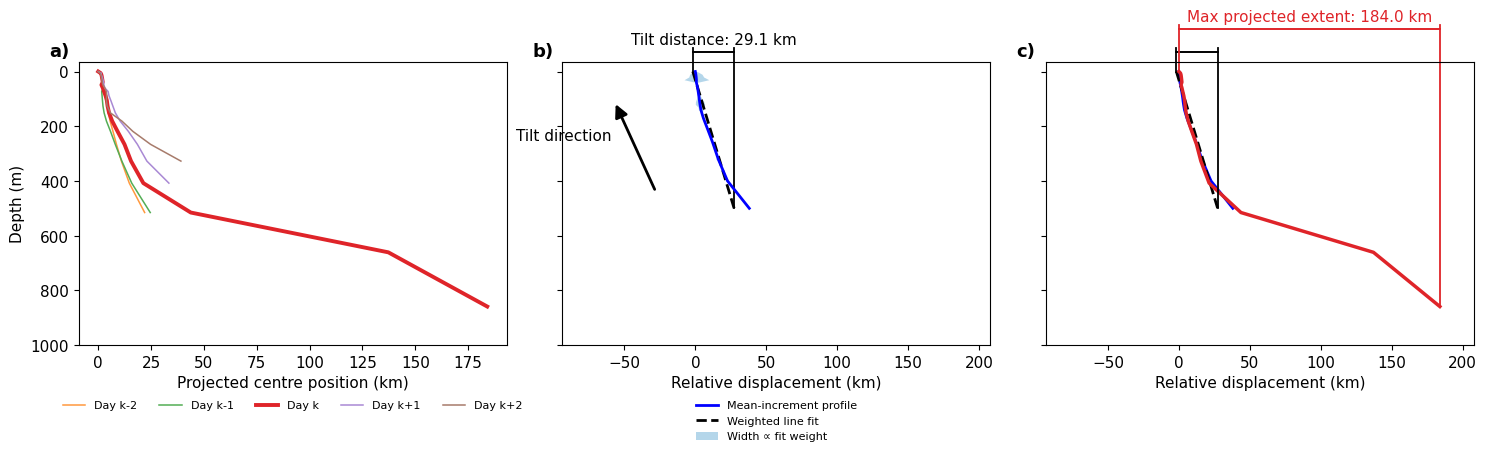

Rank 15: Eddy 974, Day 4503; absolute difference = 154.25 km (extent 192.39, delta 38.14)
Observed eddy 974, reference Day 4503
Reference depth: 0.0–858.9 m; fit labels: 0.0–650.0 m; TiltDis = 38.14 km


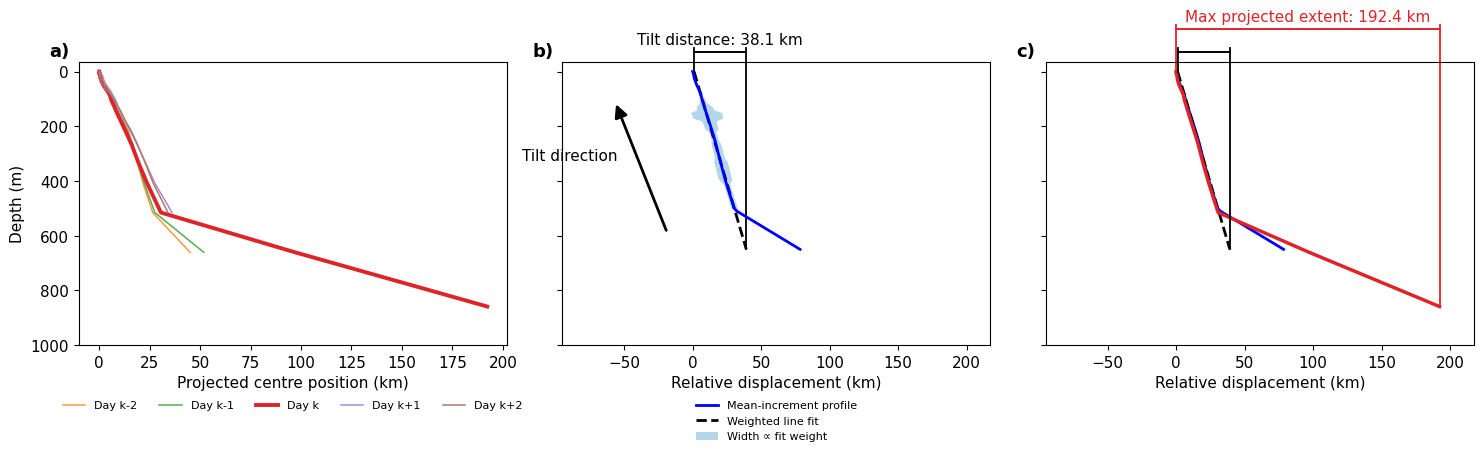

Rank 16: Eddy 2307, Day 8565; absolute difference = 152.91 km (extent 158.86, delta 5.95)
Observed eddy 2307, reference Day 8565
Reference depth: 0.0–515.4 m; fit labels: 0.0–390.0 m; TiltDis = 5.95 km


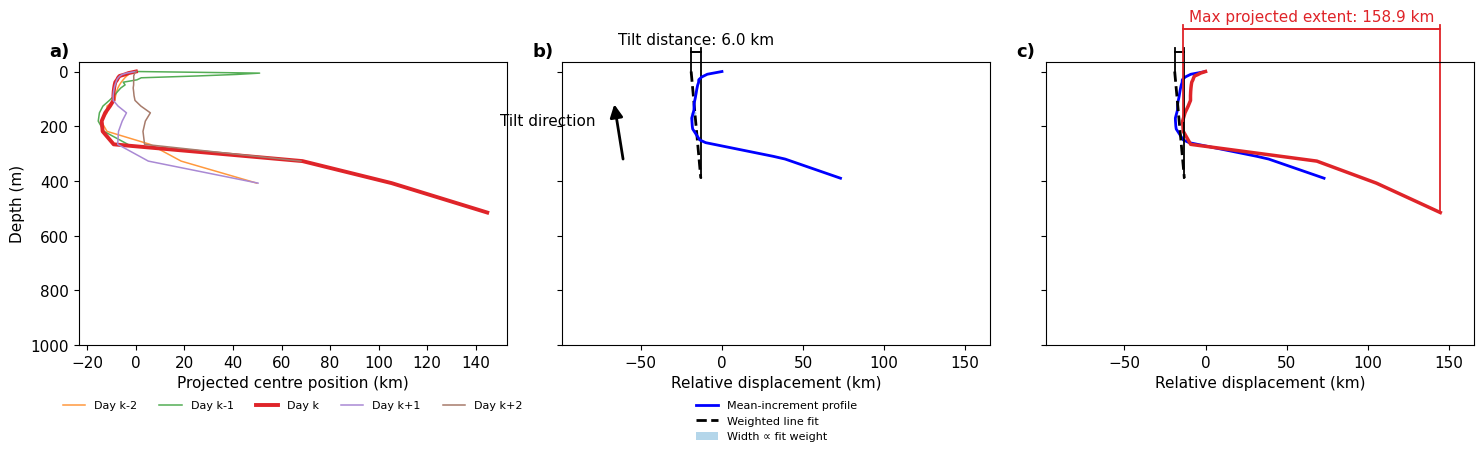

Rank 17: Eddy 140, Day 1853; absolute difference = 149.71 km (extent 171.18, delta 21.47)
Observed eddy 140, reference Day 1853
Rank 18: Eddy 589, Day 3319; absolute difference = 148.01 km (extent 191.13, delta 43.12)
Observed eddy 589, reference Day 3319
Reference depth: 0.0–660.8 m; fit labels: 0.0–650.0 m; TiltDis = 43.12 km


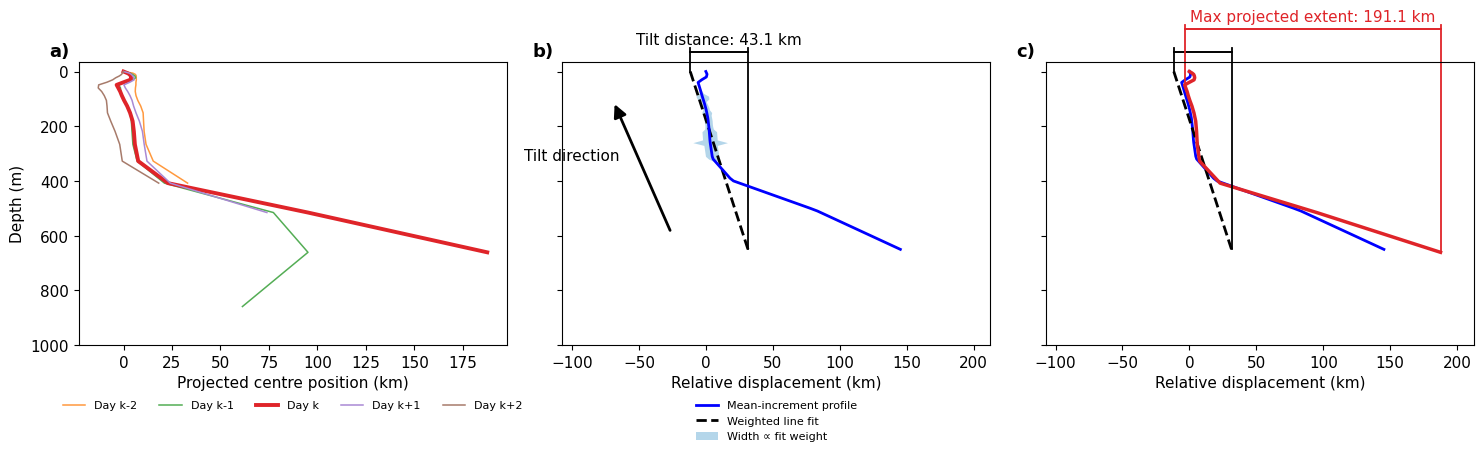

Rank 19: Eddy 1477, Day 6040; absolute difference = 144.40 km (extent 171.47, delta 27.07)
Observed eddy 1477, reference Day 6040
Reference depth: 0.0–858.9 m; fit labels: 0.0–650.0 m; TiltDis = 27.07 km


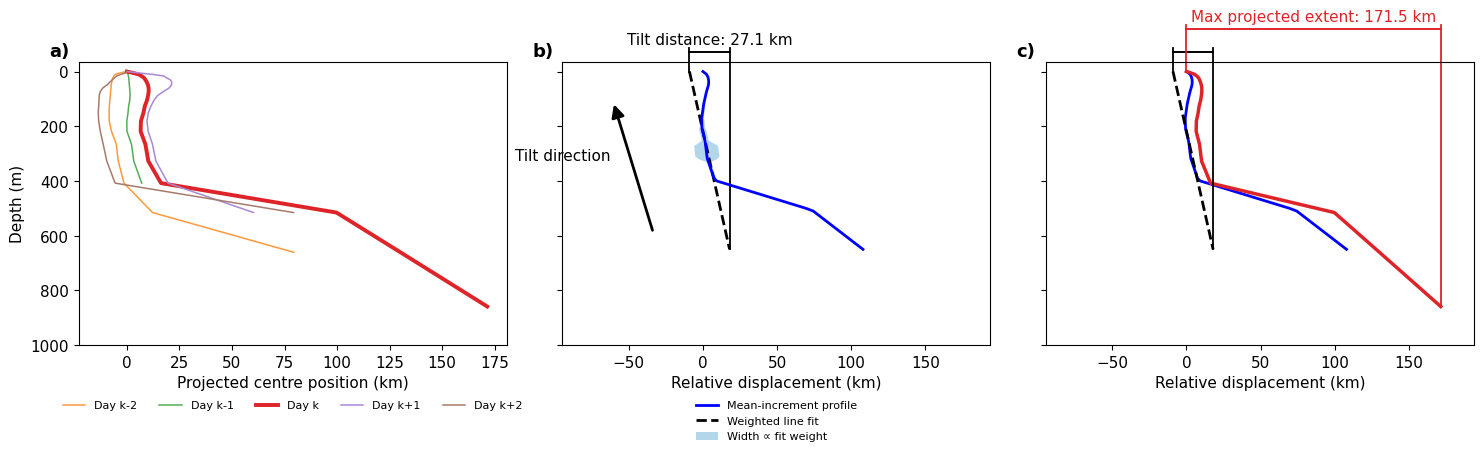

Rank 20: Eddy 2873, Day 10290; absolute difference = 143.94 km (extent 190.18, delta 46.24)
Observed eddy 2873, reference Day 10290
Reference depth: 0.0–858.9 m; fit labels: 0.0–390.0 m; TiltDis = 46.24 km


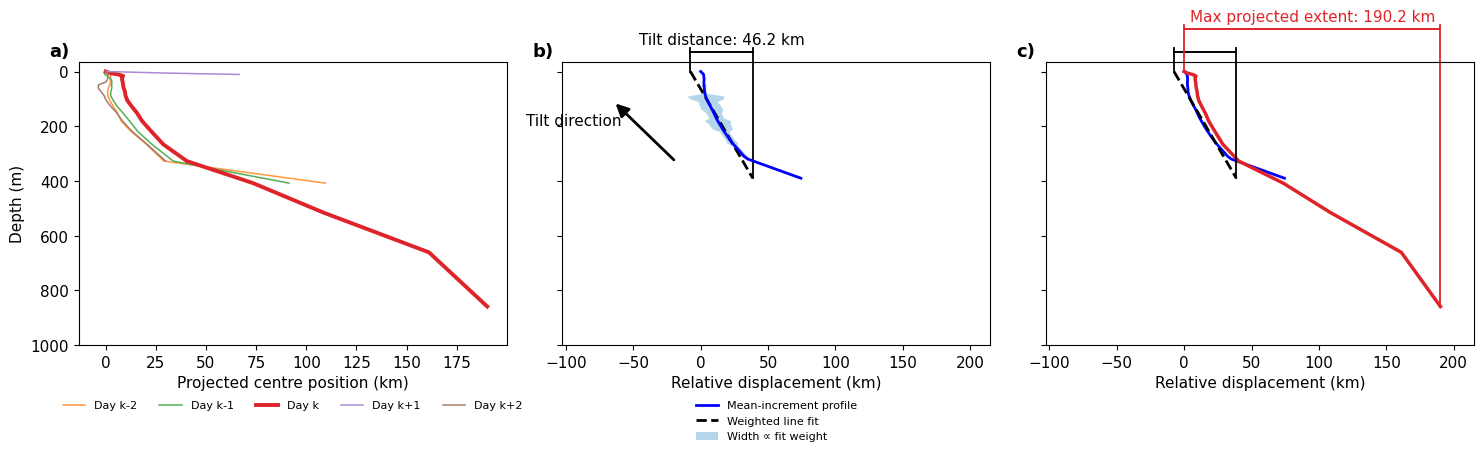

Rank 21: Eddy 2076, Day 7891; absolute difference = 143.09 km (extent 159.92, delta 16.83)
Observed eddy 2076, reference Day 7891
Reference depth: 0.0–858.9 m; fit labels: 0.0–310.0 m; TiltDis = 16.83 km


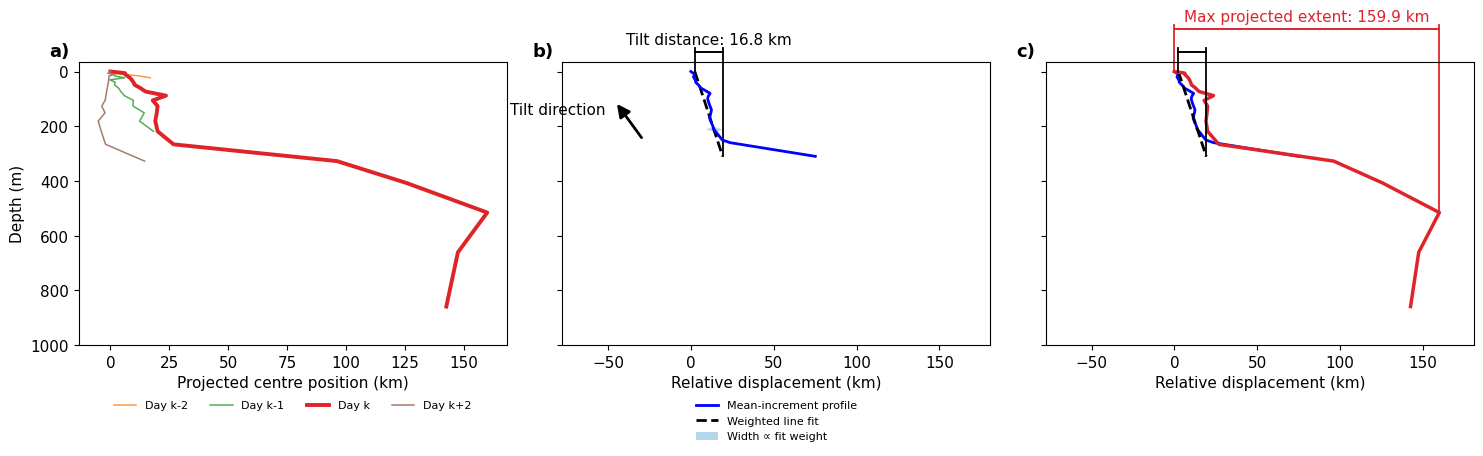

Rank 22: Eddy 2044, Day 7756; absolute difference = 142.97 km (extent 189.19, delta 46.22)
Observed eddy 2044, reference Day 7756
Reference depth: 0.0–660.8 m; fit labels: 0.0–650.0 m; TiltDis = 46.22 km


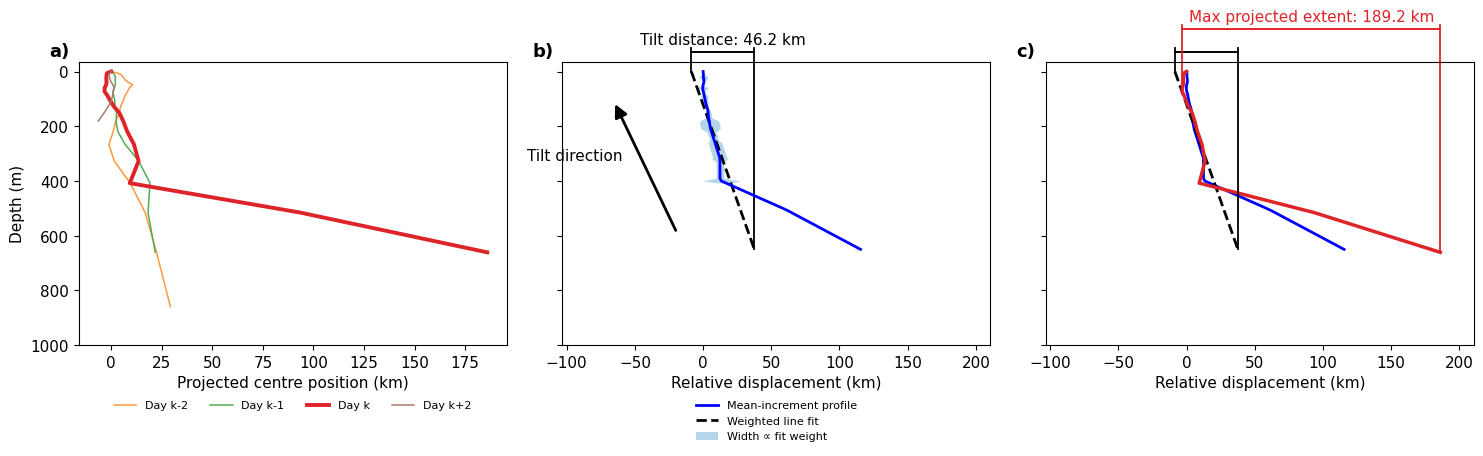

Rank 23: Eddy 352, Day 2562; absolute difference = 142.63 km (extent 148.54, delta 5.91)
Observed eddy 352, reference Day 2562
Reference depth: 0.0–660.8 m; fit labels: 0.0–390.0 m; TiltDis = 5.91 km


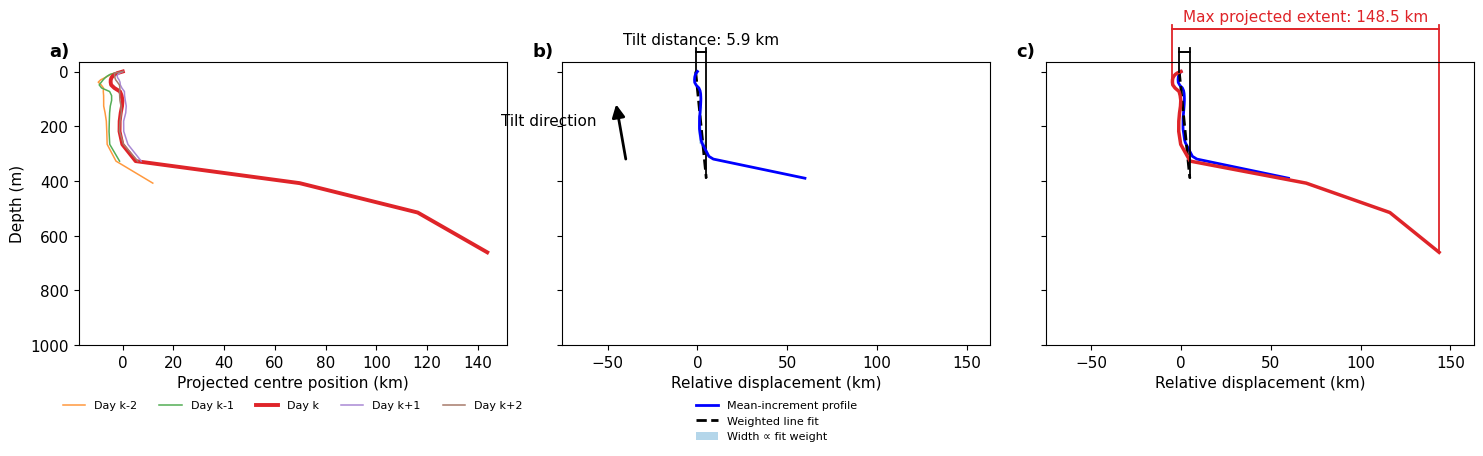

Rank 24: Eddy 72, Day 1671; absolute difference = 142.58 km (extent 164.90, delta 22.32)
Observed eddy 72, reference Day 1671
Reference depth: 0.0–407.9 m; fit labels: 0.0–250.0 m; TiltDis = 22.32 km


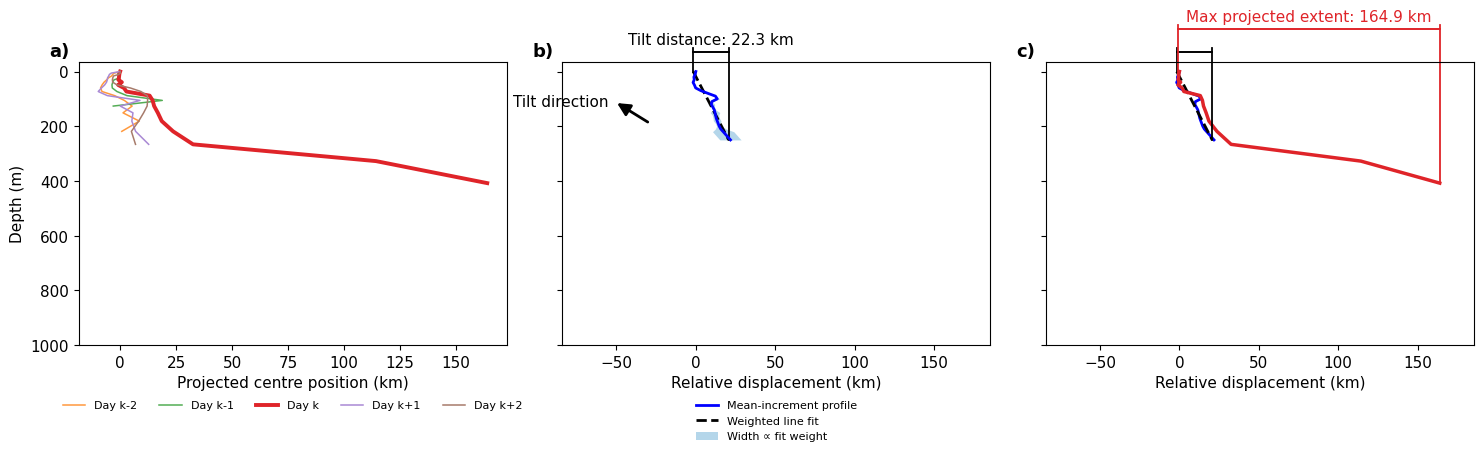

Rank 25: Eddy 1730, Day 6771; absolute difference = 142.30 km (extent 150.82, delta 8.53)
Observed eddy 1730, reference Day 6771
Reference depth: 0.0–858.9 m; fit labels: 0.0–250.0 m; TiltDis = 8.53 km


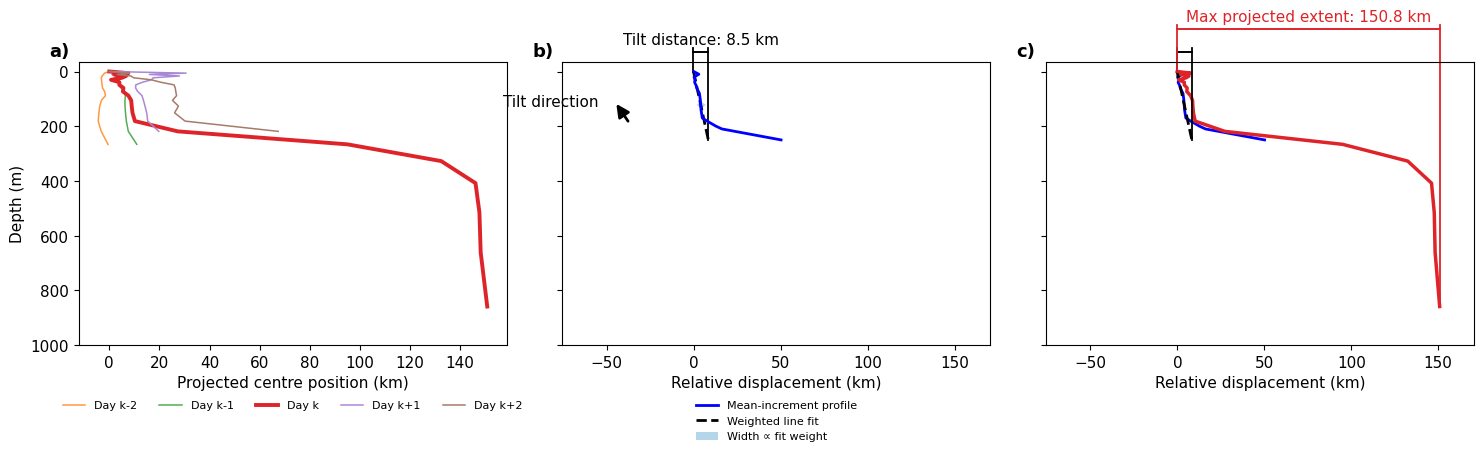

Rank 26: Eddy 2026, Day 7705; absolute difference = 141.55 km (extent 189.09, delta 47.53)
Observed eddy 2026, reference Day 7705
Reference depth: 0.0–858.9 m; fit labels: 0.0–390.0 m; TiltDis = 47.53 km


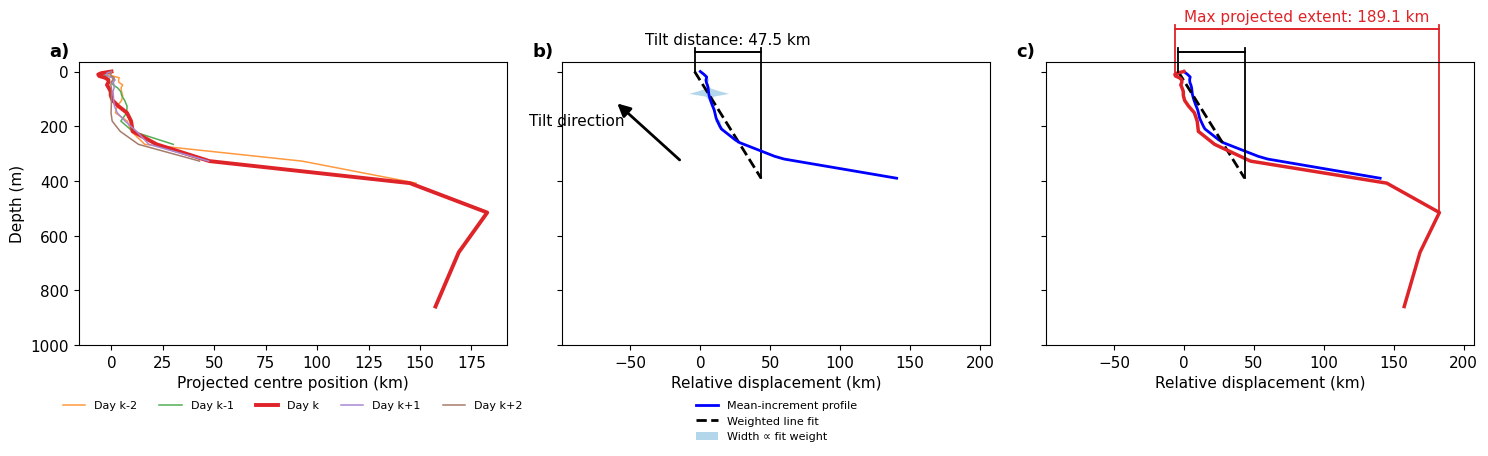

Rank 27: Eddy 1254, Day 5375; absolute difference = 141.38 km (extent 150.82, delta 9.45)
Observed eddy 1254, reference Day 5375
Reference depth: 0.0–858.9 m; fit labels: 0.0–390.0 m; TiltDis = 9.45 km


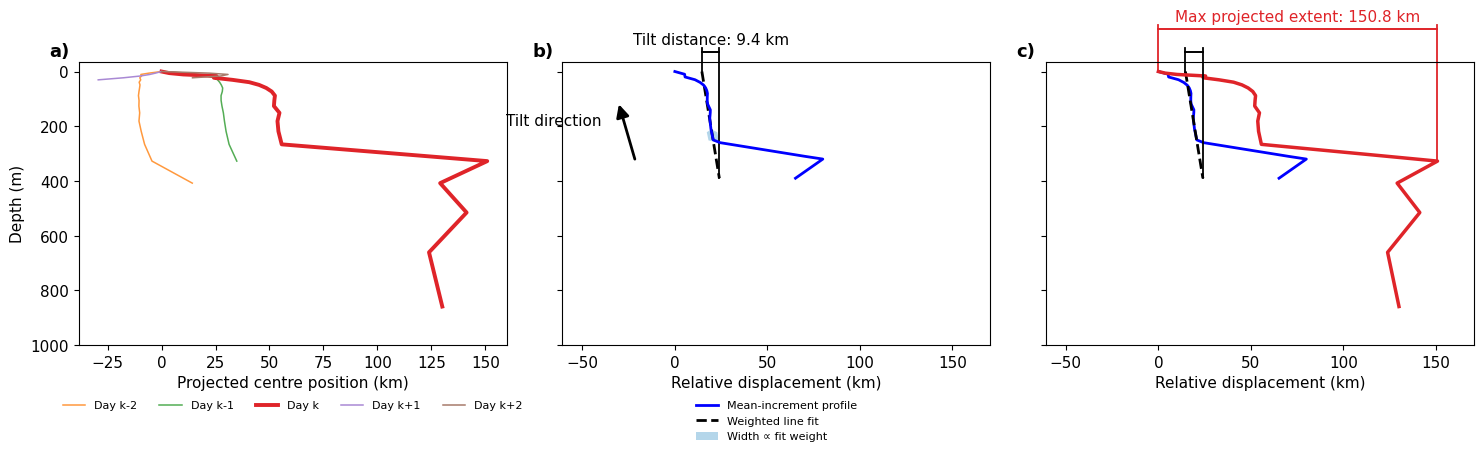

Rank 28: Eddy 1548, Day 6236; absolute difference = 138.77 km (extent 155.61, delta 16.84)
Observed eddy 1548, reference Day 6236
Rank 29: Eddy 746, Day 3782; absolute difference = 138.37 km (extent 202.79, delta 64.42)
Observed eddy 746, reference Day 3782
Reference depth: 0.0–660.8 m; fit labels: 0.0–650.0 m; TiltDis = 64.42 km


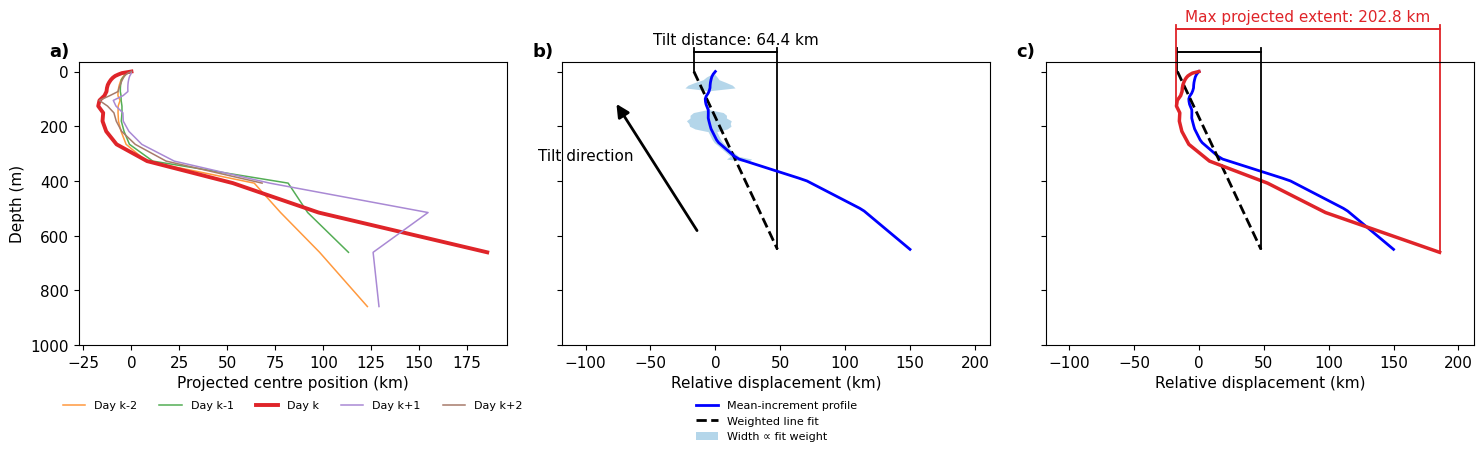

Rank 30: Eddy 734, Day 3831; absolute difference = 138.21 km (extent 172.09, delta 33.88)
Observed eddy 734, reference Day 3831
Reference depth: 0.0–858.9 m; fit labels: 0.0–500.0 m; TiltDis = 33.88 km


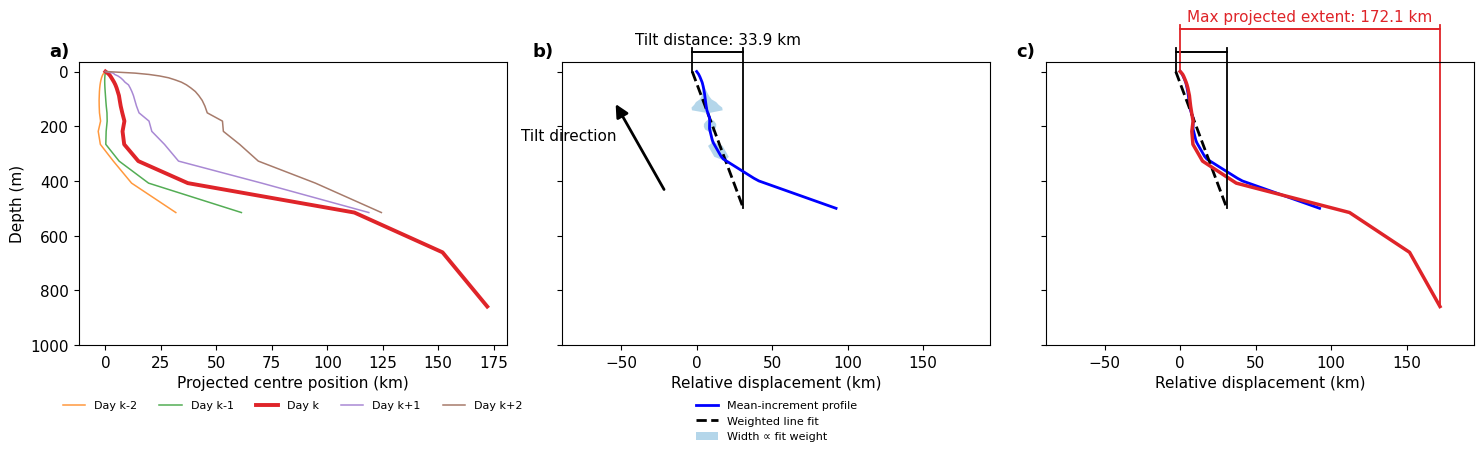

Rank 31: Eddy 1031, Day 4683; absolute difference = 138.12 km (extent 169.05, delta 30.93)
Observed eddy 1031, reference Day 4683
Reference depth: 0.0–660.8 m; fit labels: 0.0–500.0 m; TiltDis = 30.93 km


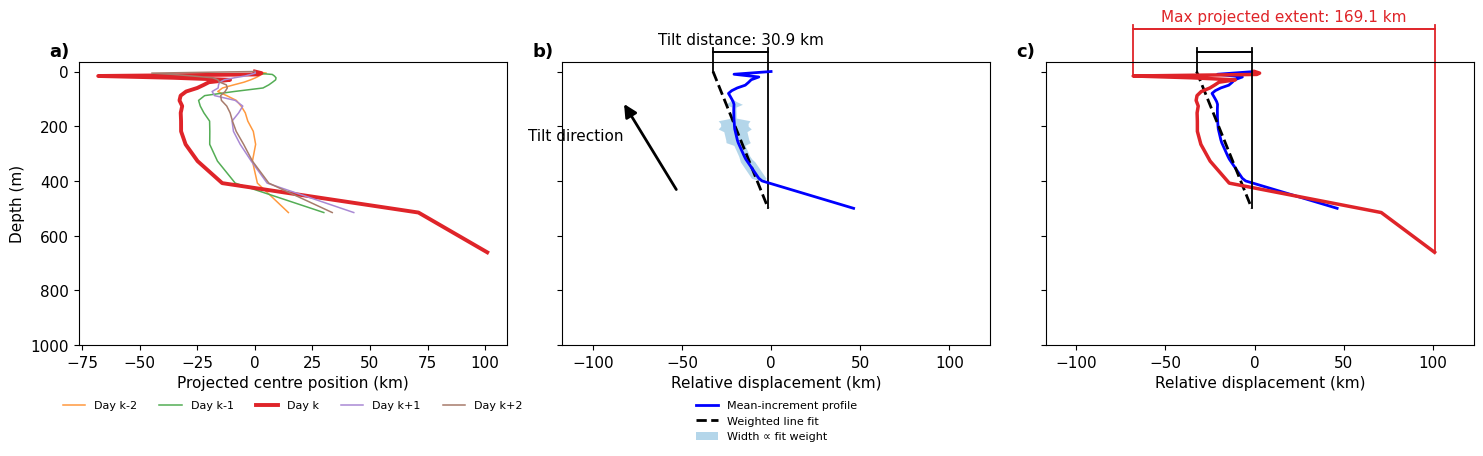

Rank 32: Eddy 192, Day 2020; absolute difference = 136.22 km (extent 155.75, delta 19.53)
Observed eddy 192, reference Day 2020
Reference depth: 0.0–858.9 m; fit labels: 0.0–200.0 m; TiltDis = 19.53 km


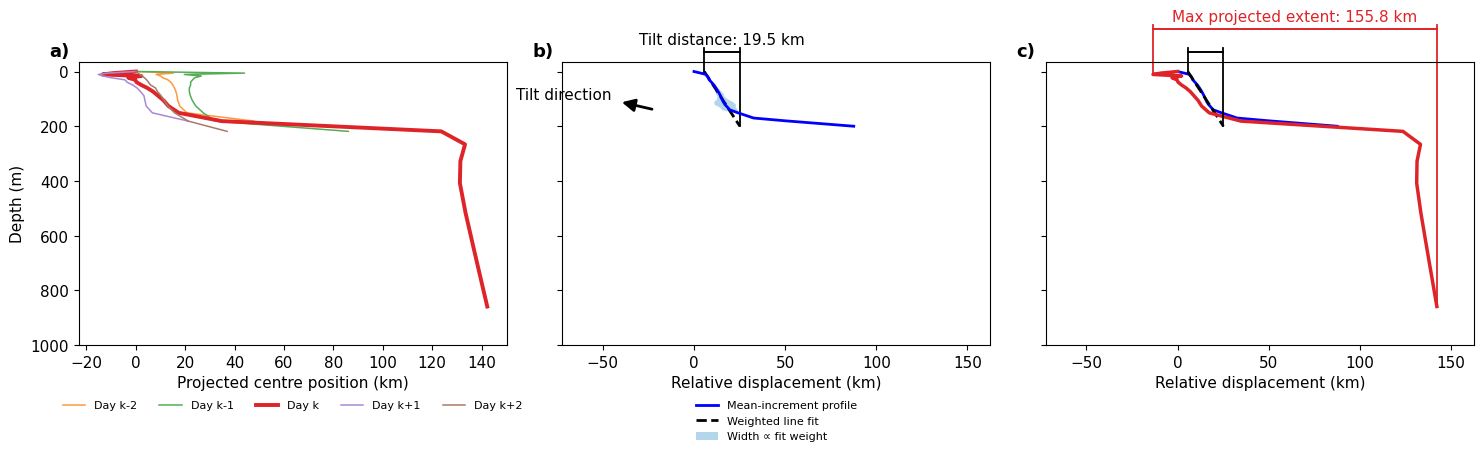

Rank 33: Eddy 1442, Day 5954; absolute difference = 134.97 km (extent 144.84, delta 9.87)
Observed eddy 1442, reference Day 5954
Reference depth: 0.0–858.9 m; fit labels: 0.0–200.0 m; TiltDis = 9.87 km


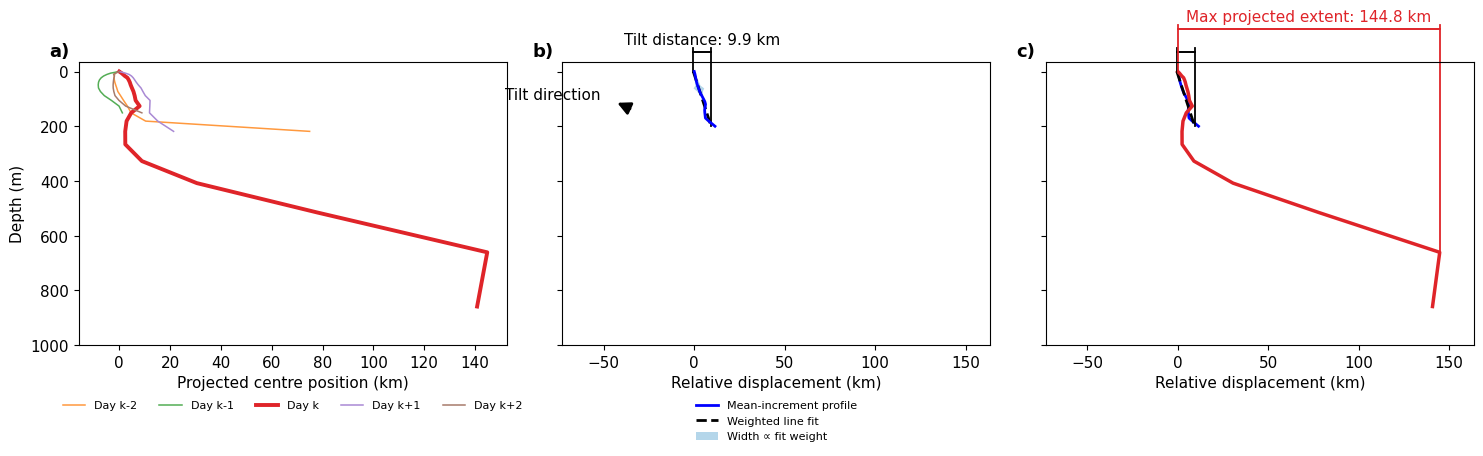

Rank 34: Eddy 2916, Day 10391; absolute difference = 134.14 km (extent 166.11, delta 31.97)
Observed eddy 2916, reference Day 10391
Reference depth: 0.0–858.9 m; fit labels: 0.0–310.0 m; TiltDis = 31.97 km


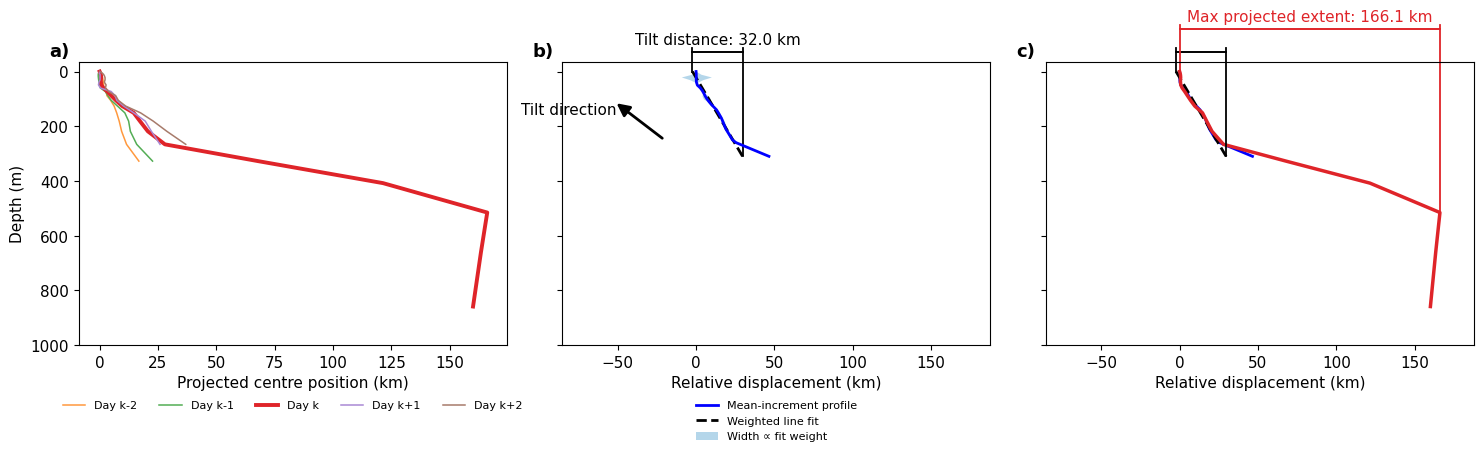

Rank 35: Eddy 1079, Day 4832; absolute difference = 133.75 km (extent 159.41, delta 25.66)
Observed eddy 1079, reference Day 4832
Reference depth: 0.0–858.9 m; fit labels: 0.0–840.0 m; TiltDis = 25.66 km


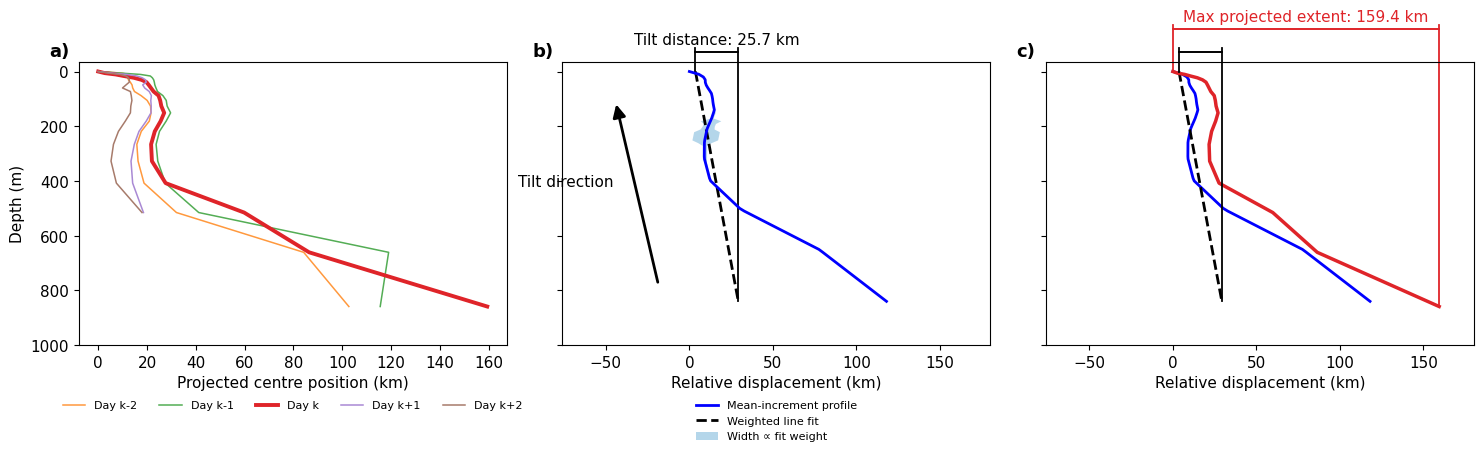

Rank 36: Eddy 955, Day 4446; absolute difference = 132.38 km (extent 136.29, delta 3.92)
Observed eddy 955, reference Day 4446
Reference depth: 0.0–858.9 m; fit labels: 0.0–840.0 m; TiltDis = 3.92 km


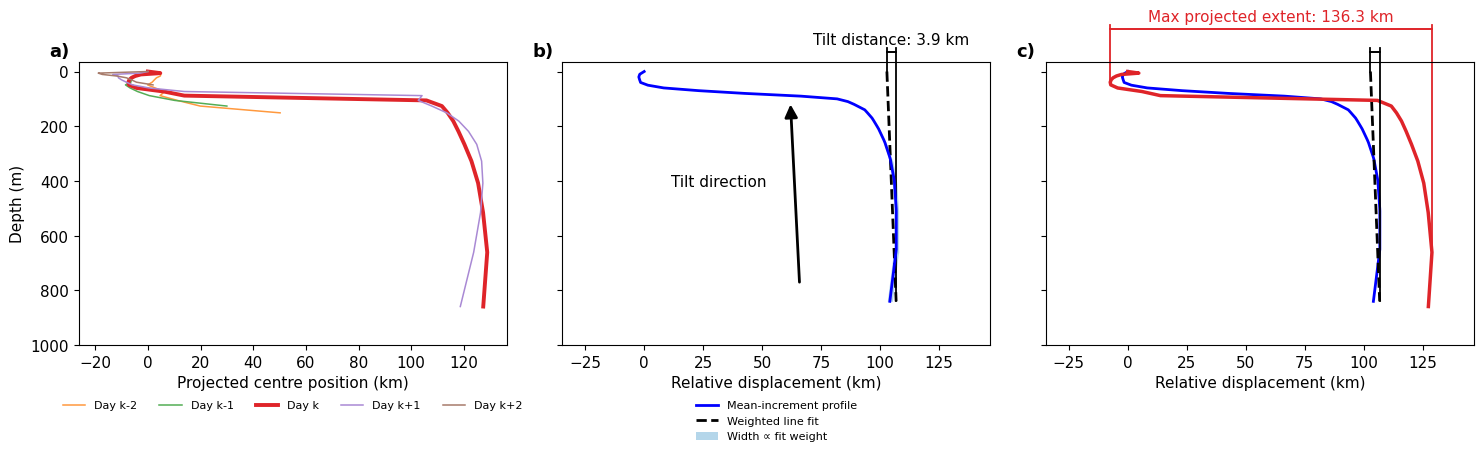

Rank 37: Eddy 2946, Day 10498; absolute difference = 132.05 km (extent 150.59, delta 18.53)
Observed eddy 2946, reference Day 10498
Reference depth: 0.0–858.9 m; fit labels: 0.0–200.0 m; TiltDis = 18.53 km


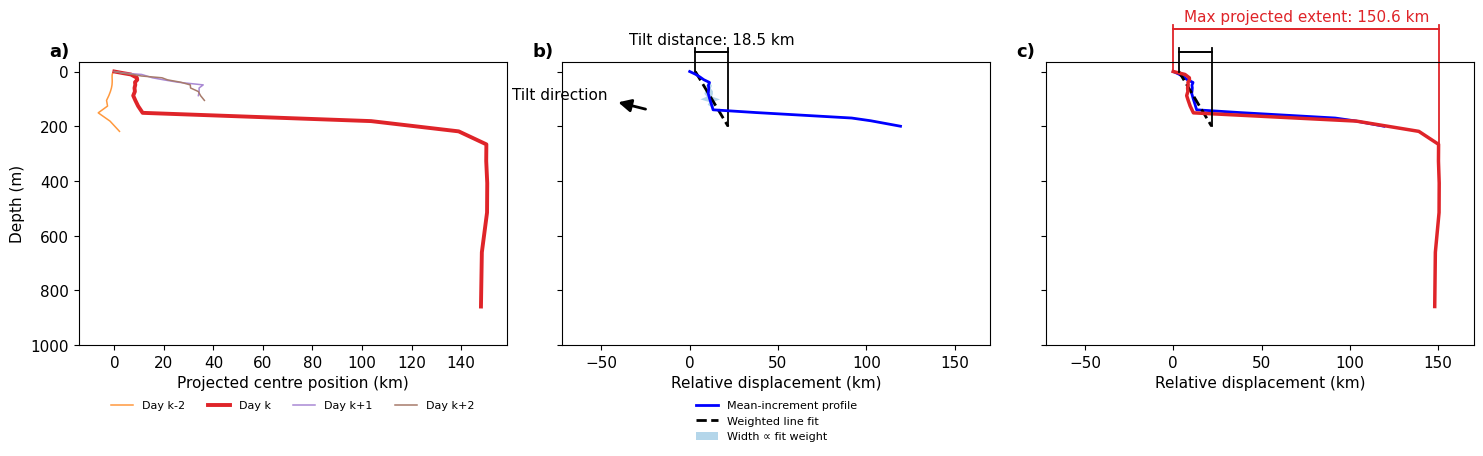

Rank 38: Eddy 863, Day 4137; absolute difference = 131.96 km (extent 139.98, delta 8.02)
Observed eddy 863, reference Day 4137
Reference depth: 0.0–218.8 m; fit labels: 0.0–200.0 m; TiltDis = 8.02 km


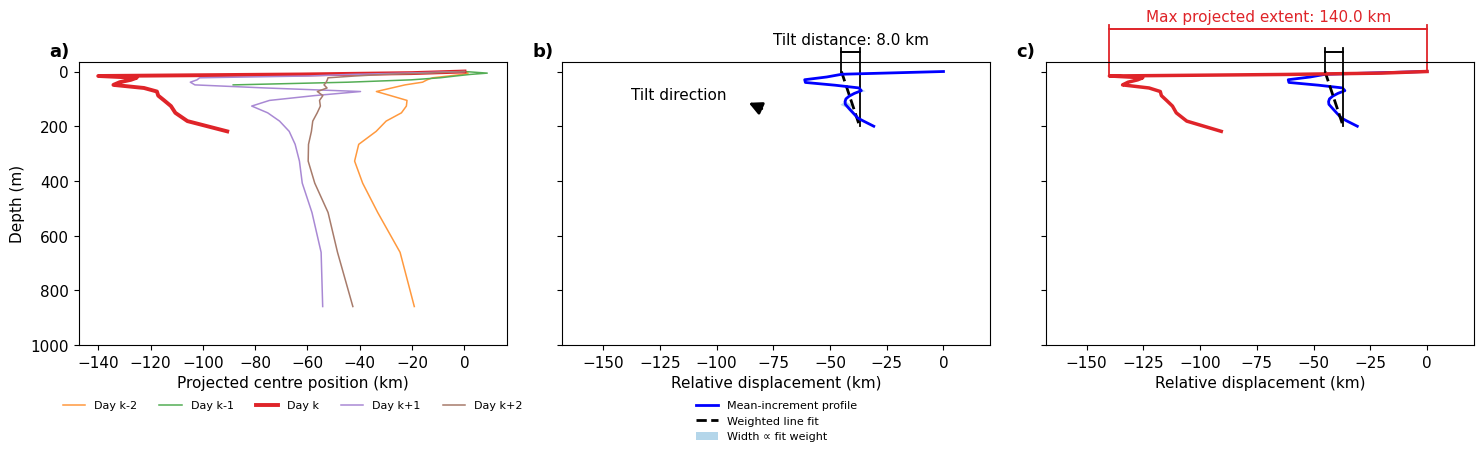

Rank 39: Eddy 2568, Day 9324; absolute difference = 131.35 km (extent 159.84, delta 28.49)
Observed eddy 2568, reference Day 9324
Rank 40: Eddy 1900, Day 7249; absolute difference = 130.70 km (extent 175.06, delta 44.36)
Observed eddy 1900, reference Day 7249
Reference depth: 0.0–327.4 m; fit labels: 0.0–310.0 m; TiltDis = 44.36 km


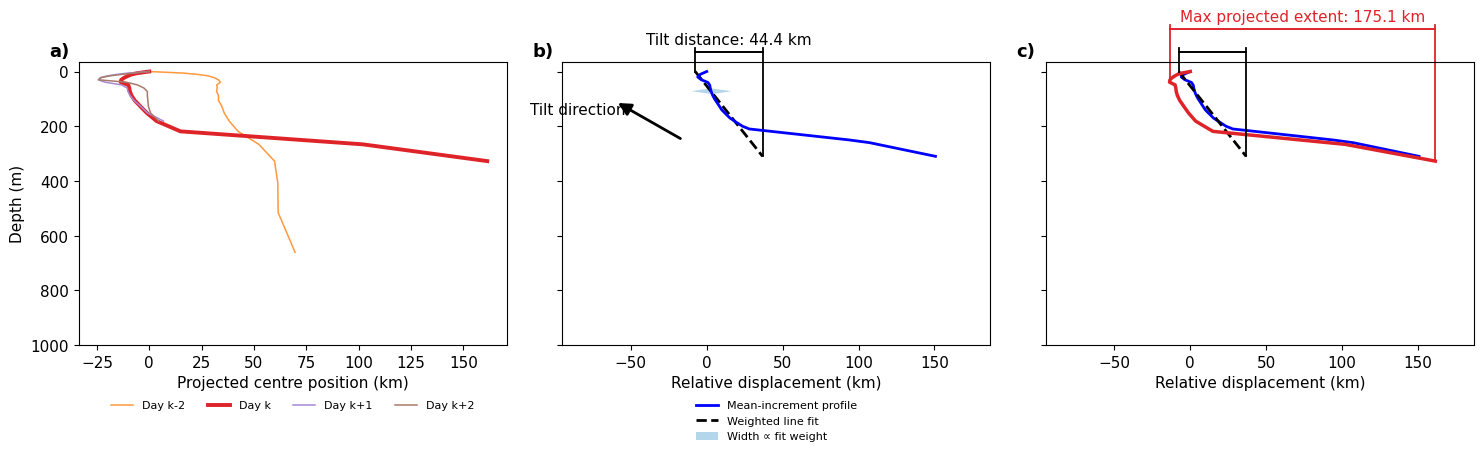

Rank 41: Eddy 1144, Day 5030; absolute difference = 130.31 km (extent 152.56, delta 22.26)
Observed eddy 1144, reference Day 5030
Rank 42: Eddy 997, Day 4590; absolute difference = 130.27 km (extent 155.33, delta 25.06)
Observed eddy 997, reference Day 4590
Reference depth: 0.0–858.9 m; fit labels: 0.0–500.0 m; TiltDis = 25.06 km


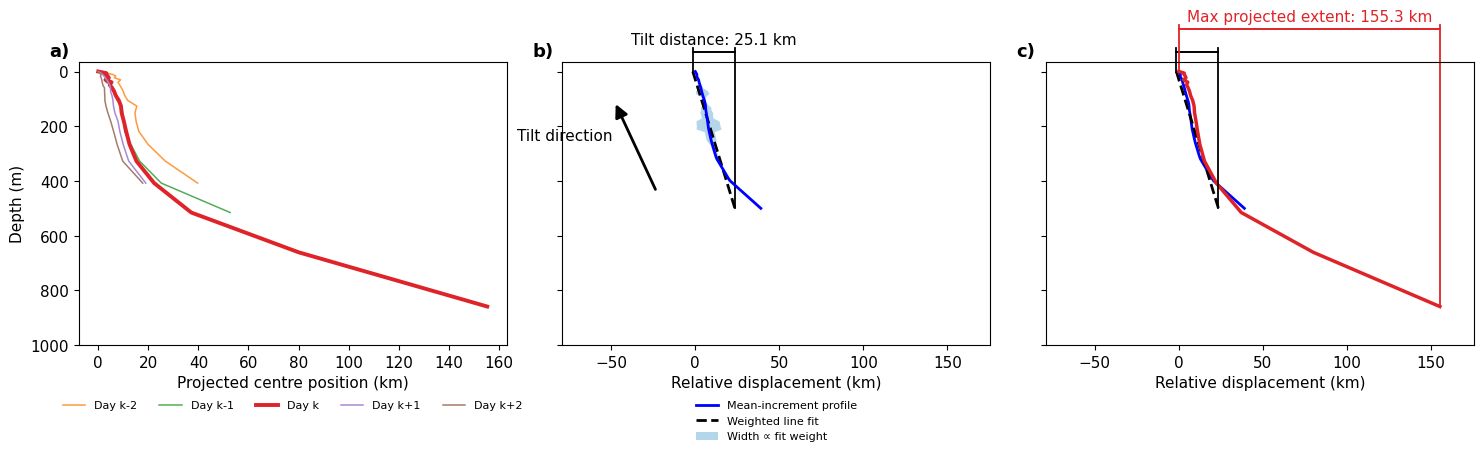

Rank 43: Eddy 1642, Day 6514; absolute difference = 129.36 km (extent 186.23, delta 56.87)
Observed eddy 1642, reference Day 6514
Reference depth: 0.0–515.4 m; fit labels: 0.0–500.0 m; TiltDis = 56.87 km


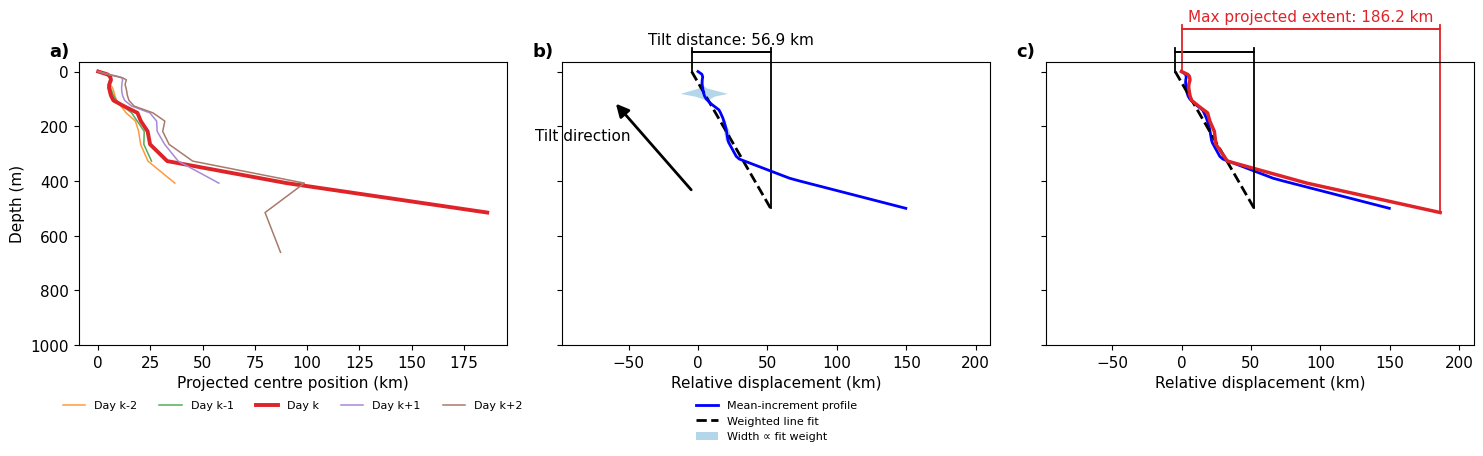

Rank 44: Eddy 1396, Day 5793; absolute difference = 128.58 km (extent 136.17, delta 7.59)
Observed eddy 1396, reference Day 5793
Reference depth: 0.0–858.9 m; fit labels: 0.0–840.0 m; TiltDis = 7.59 km


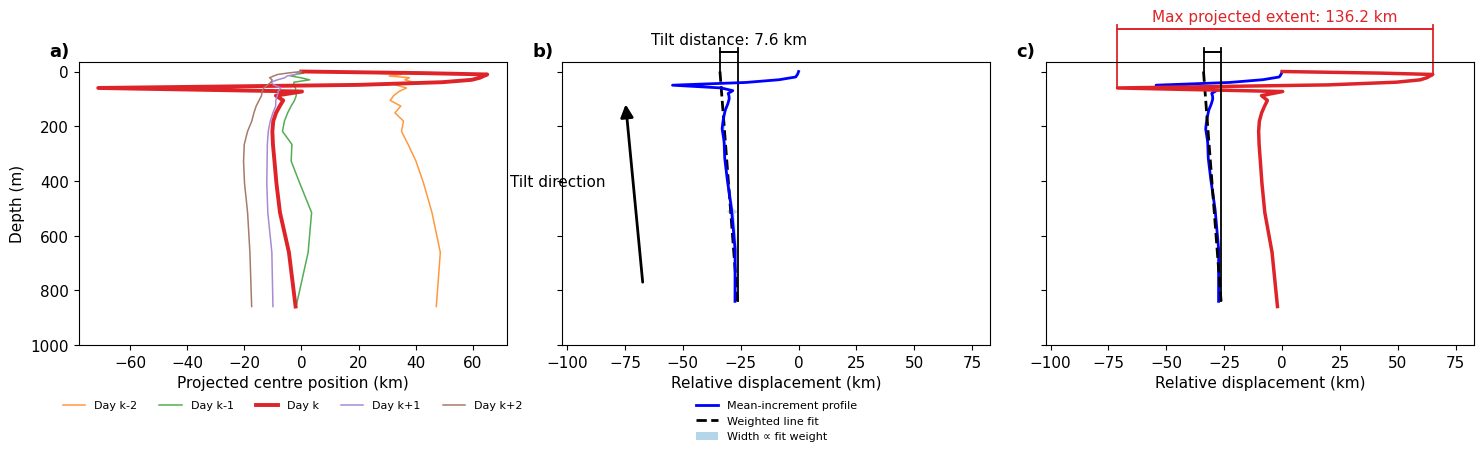

Rank 45: Eddy 163, Day 1917; absolute difference = 128.31 km (extent 142.31, delta 14.00)
Observed eddy 163, reference Day 1917
Reference depth: 0.0–660.8 m; fit labels: 0.0–500.0 m; TiltDis = 14.00 km


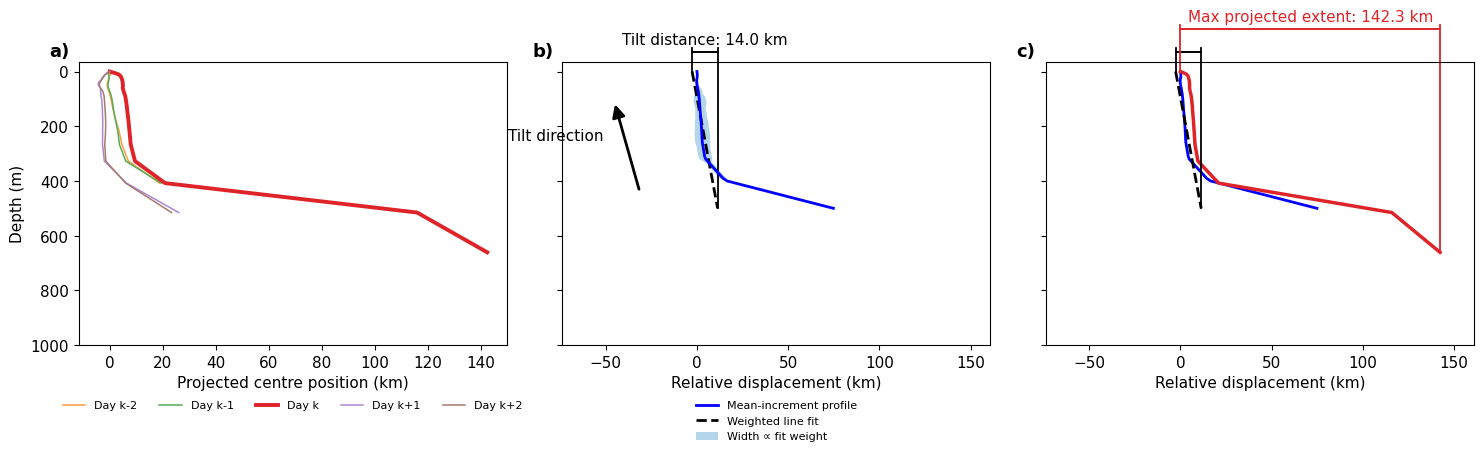

Rank 46: Eddy 2770, Day 9920; absolute difference = 127.54 km (extent 146.94, delta 19.40)
Observed eddy 2770, reference Day 9920
Reference depth: 0.0–858.9 m; fit labels: 0.0–500.0 m; TiltDis = 19.40 km


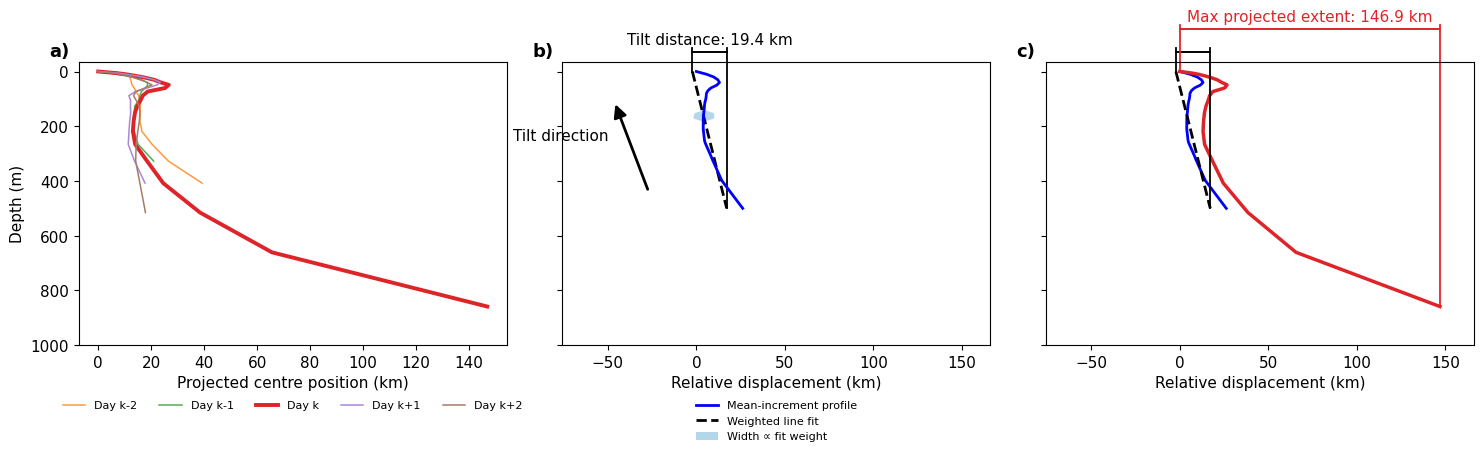

Rank 47: Eddy 903, Day 4269; absolute difference = 127.00 km (extent 171.98, delta 44.98)
Observed eddy 903, reference Day 4269
Reference depth: 0.0–858.9 m; fit labels: 0.0–390.0 m; TiltDis = 44.98 km


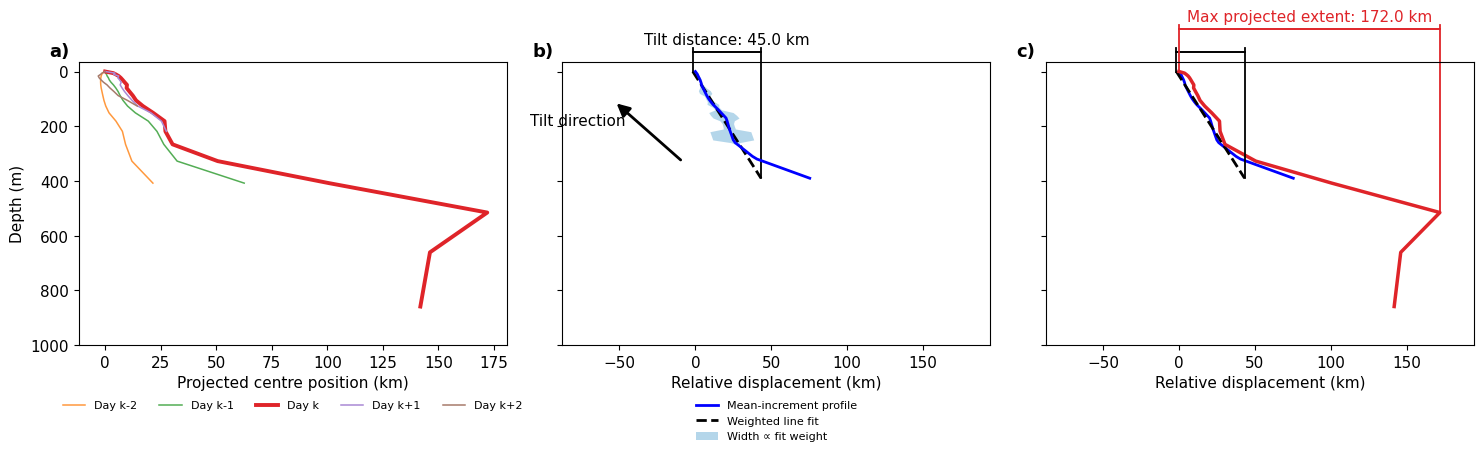

Rank 48: Eddy 696, Day 3623; absolute difference = 126.98 km (extent 143.94, delta 16.96)
Observed eddy 696, reference Day 3623
Reference depth: 0.0–515.4 m; fit labels: 0.0–500.0 m; TiltDis = 16.96 km


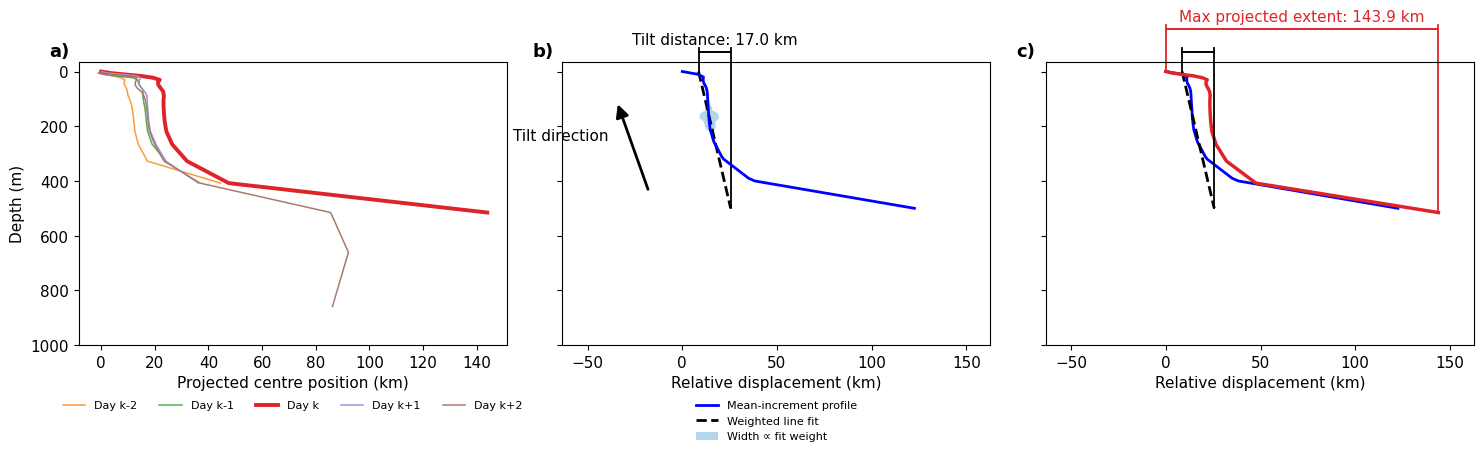

Rank 49: Eddy 1648, Day 6506; absolute difference = 126.81 km (extent 144.02, delta 17.21)
Observed eddy 1648, reference Day 6506
Reference depth: 0.0–515.4 m; fit labels: 0.0–310.0 m; TiltDis = 17.21 km


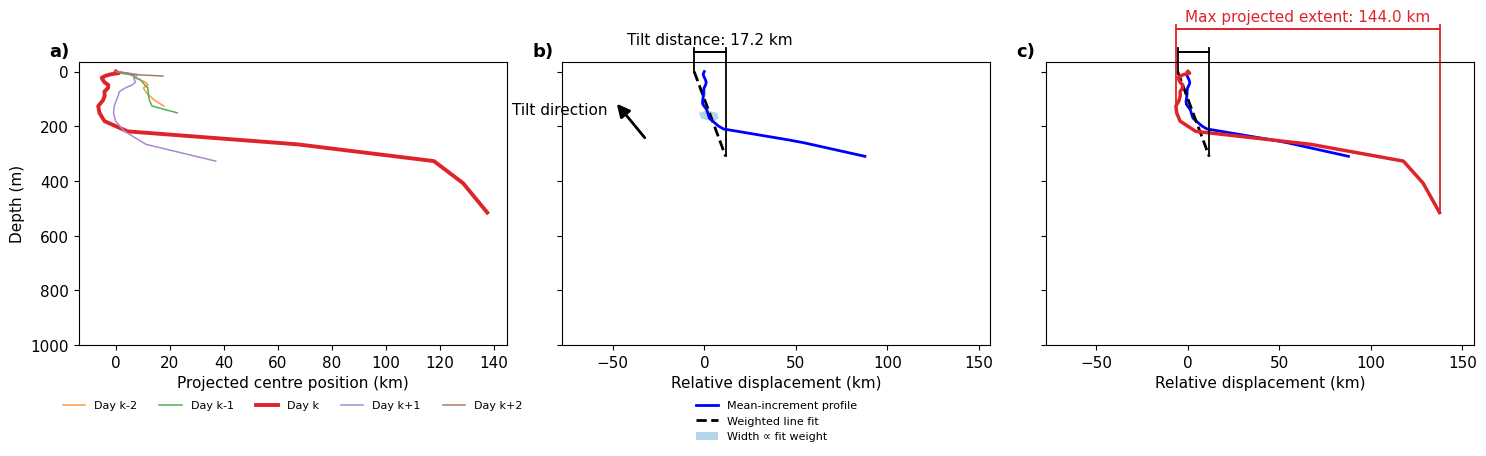

Rank 50: Eddy 958, Day 4452; absolute difference = 126.72 km (extent 137.84, delta 11.12)
Observed eddy 958, reference Day 4452
Reference depth: 0.0–858.9 m; fit labels: 0.0–200.0 m; TiltDis = 11.12 km


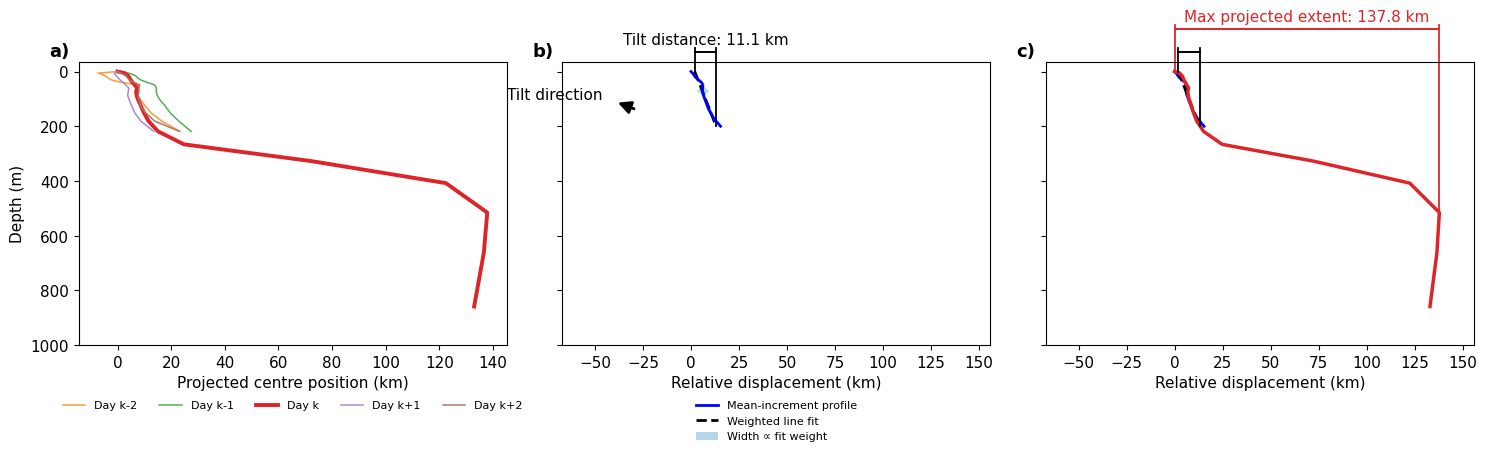

Rank 51: Eddy 951, Day 4444; absolute difference = 126.71 km (extent 141.93, delta 15.23)
Observed eddy 951, reference Day 4444
Reference depth: 0.0–858.9 m; fit labels: 0.0–250.0 m; TiltDis = 15.23 km


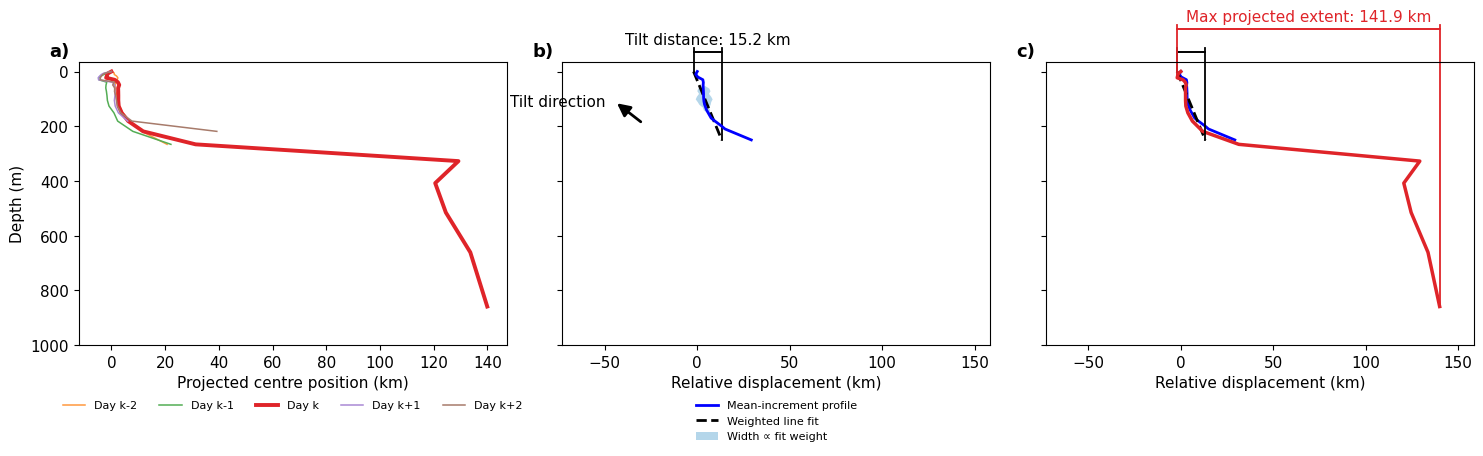

Rank 52: Eddy 774, Day 3843; absolute difference = 126.53 km (extent 147.87, delta 21.34)
Observed eddy 774, reference Day 3843
Reference depth: 0.0–407.9 m; fit labels: 0.0–250.0 m; TiltDis = 21.34 km


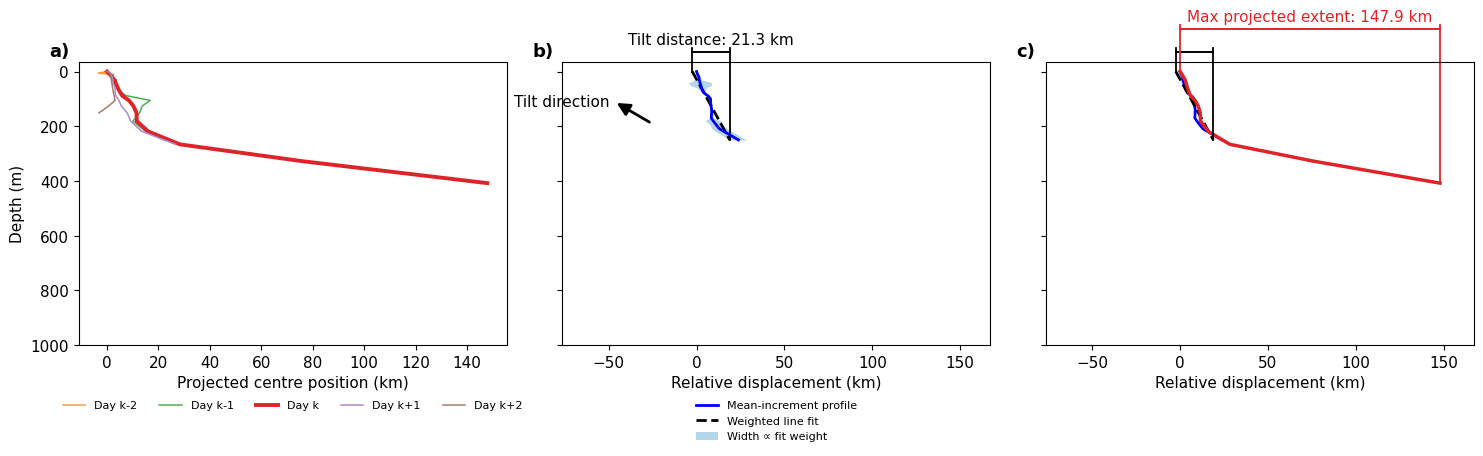

Rank 53: Eddy 2408, Day 8835; absolute difference = 125.67 km (extent 137.64, delta 11.97)
Observed eddy 2408, reference Day 8835
Reference depth: 0.0–858.9 m; fit labels: 0.0–310.0 m; TiltDis = 11.97 km


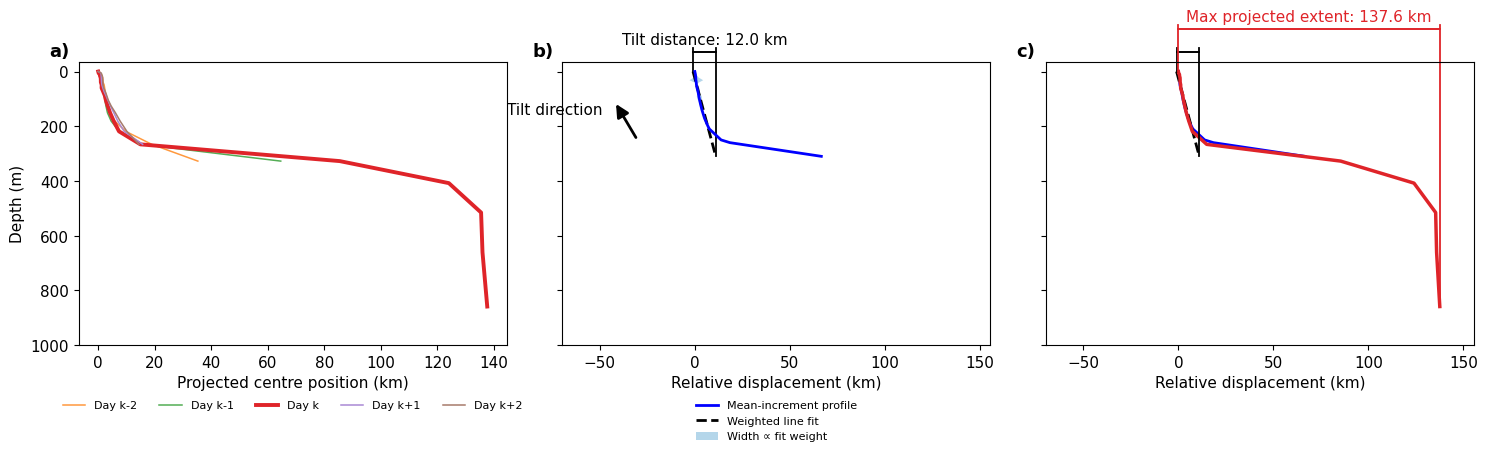

Rank 54: Eddy 2189, Day 8196; absolute difference = 125.59 km (extent 147.68, delta 22.09)
Observed eddy 2189, reference Day 8196
Rank 55: Eddy 764, Day 3842; absolute difference = 125.19 km (extent 162.25, delta 37.06)
Observed eddy 764, reference Day 3842
Reference depth: 0.0–858.9 m; fit labels: 0.0–500.0 m; TiltDis = 37.06 km


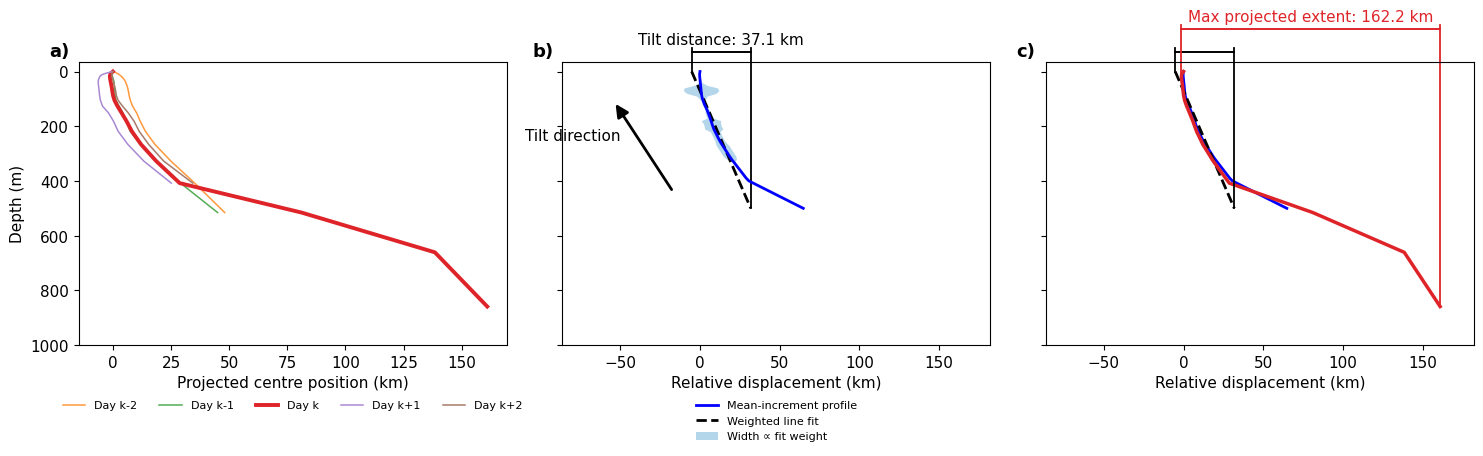

Rank 56: Eddy 2016, Day 7709; absolute difference = 124.82 km (extent 137.12, delta 12.30)
Observed eddy 2016, reference Day 7709
Reference depth: 0.0–858.9 m; fit labels: 0.0–840.0 m; TiltDis = 12.30 km


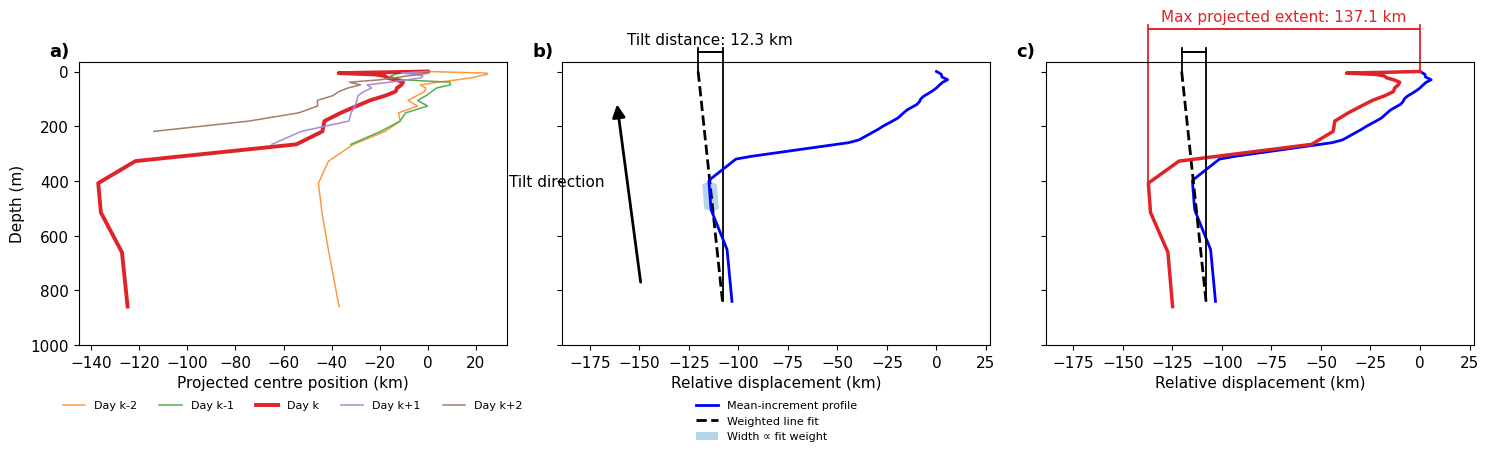

Rank 57: Eddy 88, Day 1709; absolute difference = 124.06 km (extent 135.65, delta 11.60)
Observed eddy 88, reference Day 1709
Reference depth: 0.0–407.9 m; fit labels: 0.0–390.0 m; TiltDis = 11.60 km


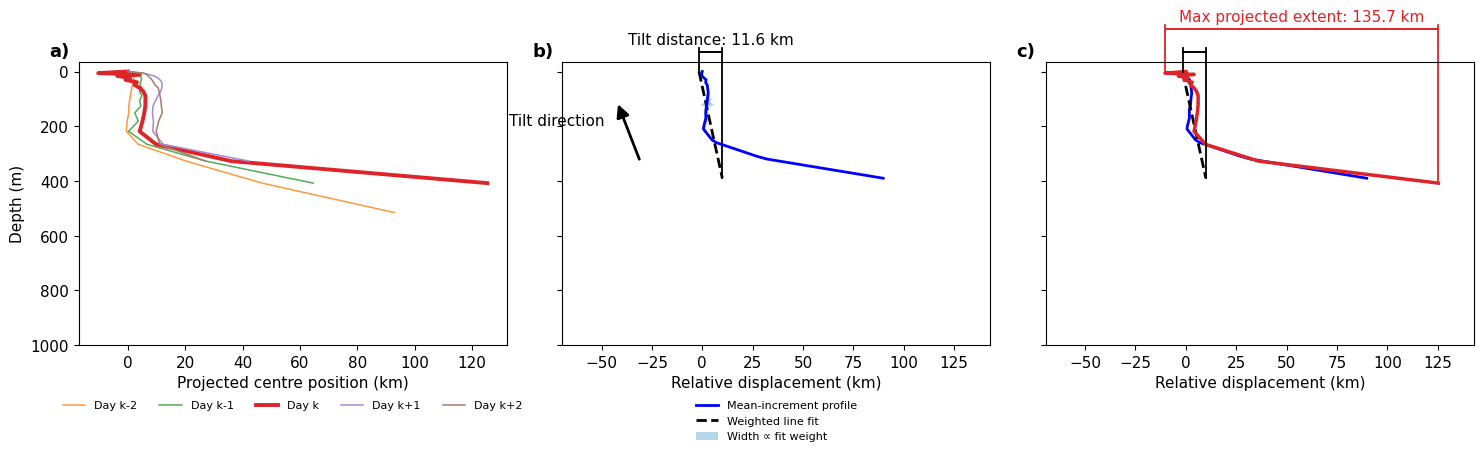

Rank 58: Eddy 931, Day 4341; absolute difference = 123.41 km (extent 141.63, delta 18.23)
Observed eddy 931, reference Day 4341
Reference depth: 0.0–858.9 m; fit labels: 0.0–840.0 m; TiltDis = 18.23 km


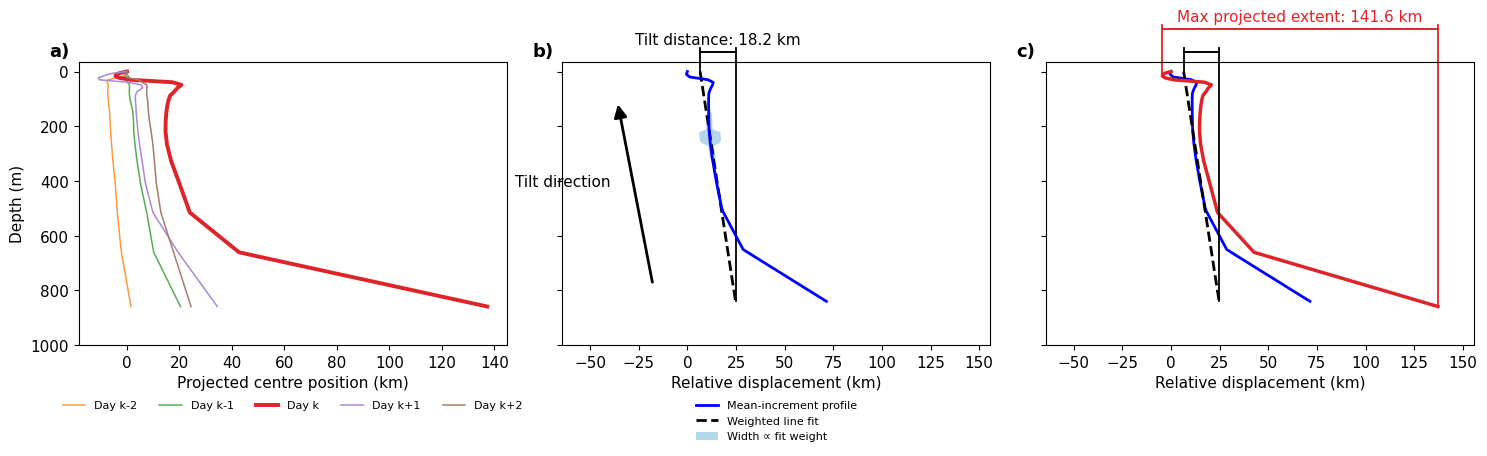

Rank 59: Eddy 1120, Day 4959; absolute difference = 123.30 km (extent 168.93, delta 45.63)
Observed eddy 1120, reference Day 4959
Rank 60: Eddy 2026, Day 7703; absolute difference = 122.75 km (extent 152.41, delta 29.67)
Observed eddy 2026, reference Day 7703
Reference depth: 0.0–407.9 m; fit labels: 0.0–390.0 m; TiltDis = 29.67 km


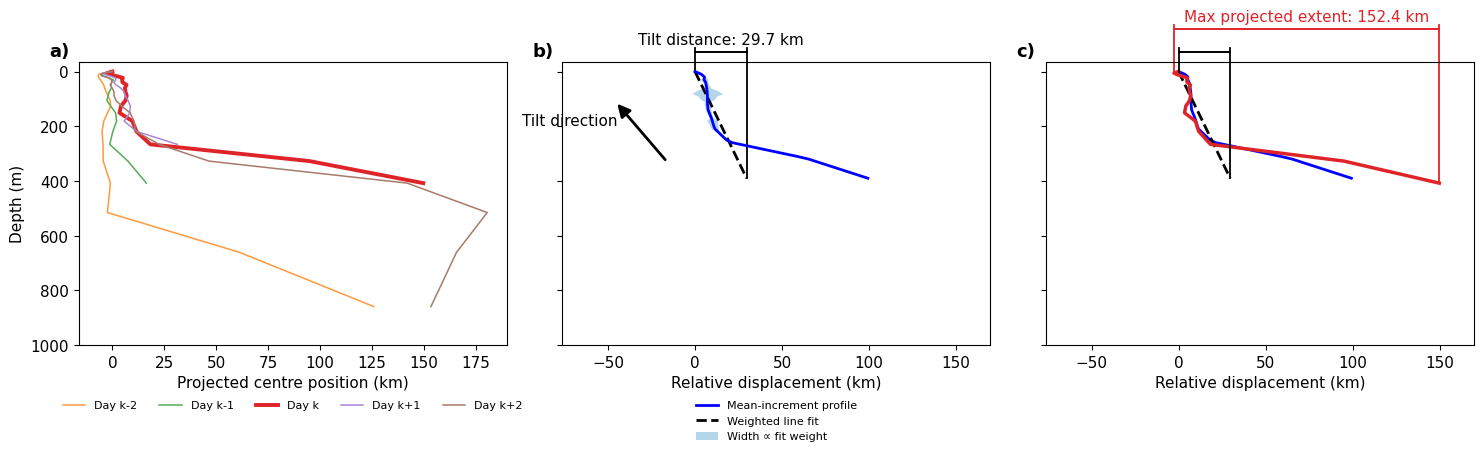

In [6]:
if RUN_DIFFERENCE_SEARCH:
    if not isinstance(TOP_N_DIFFERENCES, int) or isinstance(TOP_N_DIFFERENCES, bool) or TOP_N_DIFFERENCES < 1:
        raise ValueError('TOP_N_DIFFERENCES must be a positive integer.')
    current_settings = dict(depth_int=DEPTH_INT, max_depth=MAX_DEPTH,
        sigma=TEMPORAL_SIGMA_DAYS, half_window=NUM // 2,
        min_depth_range=MIN_DEPTH_RANGE, min_points=MIN_POINTS,
        bearing_offset=BEARING_OFFSET, eps=EPS)
    if current_settings != difference_search_settings:
        raise ValueError('Fit settings changed; rerun the search cell before plotting ranked results.')
    largest_differences = difference_ranking.head(TOP_N_DIFFERENCES)
    display(largest_differences.round(2))
    if len(largest_differences) < TOP_N_DIFFERENCES:
        print(f'Only {len(largest_differences)} valid ranked examples are available.')
    for row in largest_differences.itertuples(index=False):
        print(f'Rank {row.Rank}: Eddy {row.Eddy}, Day {row.Day}; '
              f'absolute difference = {row.AbsoluteDifference:.2f} km '
              f'(extent {row.MaxProjectedExtent:.2f}, delta {row.TiltDis:.2f})')
        trial = all_profiles.loc[all_profiles.Eddy.eq(row.Eddy)
            & all_profiles.Day.between(row.Day - NUM // 2, row.Day + NUM // 2)]
        # plotted = plot_schematic(row.Eddy, row.Day, trial)
        # np.testing.assert_allclose(
        #     [plotted['MaxProjectedExtent'], plotted['TiltDis'], plotted['AbsoluteDifference']],
        #     [row.MaxProjectedExtent, row.TiltDis, row.AbsoluteDifference], rtol=1e-8, atol=1e-8)
        try:
            plotted = plot_schematic(row.Eddy, row.Day, trial)
            np.testing.assert_allclose(
                [plotted['MaxProjectedExtent'], plotted['TiltDis'], plotted['AbsoluteDifference']],
                [row.MaxProjectedExtent, row.TiltDis, row.AbsoluteDifference],
                rtol=1e-8, atol=1e-8
            )
        except Exception:
            continue